In [111]:
import sys
!python3 -m pip install FlowCytometryTools
!python3 -m pip install scipy
!pip install seaborn -U

13091.10s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


13098.19s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


13105.60s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


In [112]:
!python3 -m pip install seaborn


13114.22s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [1]:
from FlowCytometryTools import FCMeasurement
import pandas as pd
import os
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
import matplotlib.colors as mcolors
from IPython.display import HTML

## Calibration of Metavariables

In [114]:
All_Files

['F05 Well - F05.fcs',
 'B05 Well - B05.fcs',
 'F03 Well - F03.fcs',
 'B03 Well - B03.fcs',
 'B10 Well - B10.fcs',
 'F10 Well - F10.fcs',
 'E08 Well - E08.fcs',
 'C03 Well - C03.fcs',
 'G03 Well - G03.fcs',
 'G10 Well - G10.fcs',
 'C10 Well - C10.fcs',
 'D08 Well - D08.fcs',
 'C05 Well - C05.fcs',
 'G05 Well - G05.fcs',
 'C11 Well - C11.fcs',
 'G11 Well - G11.fcs',
 'D09 Well - D09.fcs',
 'G02 Well - G02.fcs',
 'C02 Well - C02.fcs',
 'G04 Well - G04.fcs',
 'C04 Well - C04.fcs',
 'B04 Well - B04.fcs',
 'F04 Well - F04.fcs',
 'F11 Well - F11.fcs',
 'B11 Well - B11.fcs',
 'E09 Well - E09.fcs',
 'B02 Well - B02.fcs',
 'F02 Well - F02.fcs',
 'G06 Well - G06.fcs',
 'C06 Well - C06.fcs',
 'B06 Well - B06.fcs',
 'F06 Well - F06.fcs',
 'F07 Well - F07.fcs',
 'B07 Well - B07.fcs',
 'C07 Well - C07.fcs',
 'G07 Well - G07.fcs',
 'D05 Well - D05.fcs',
 'D03 Well - D03.fcs',
 'D10 Well - D10.fcs',
 'C08 Well - C08.fcs',
 'G08 Well - G08.fcs',
 'E03 Well - E03.fcs',
 'E10 Well - E10.fcs',
 'F08 Well 

In [61]:
Dirpath = '/Users/Kevin Chang/Downloads/Sample Group - 1/Sample Group - 1'
All_Files = os.listdir(Dirpath)
for ThisFile in All_Files[0:10]:
    if '.fcs' in ThisFile:
        ThisID = ThisFile[-8:-1].strip('.fcs')
        sample = FCMeasurement(ID=ThisID,datafile=Dirpath + '/' + ThisFile)

list(sample.get_data().columns)

['FSC - Area',
 'FSC - Height',
 'FSC - Width',
 'SSC - Area',
 'SSC - Height',
 'SSC - Width',
 '405 - Area',
 '405 - Height',
 '405 - Width',
 'GFP - Area',
 'GFP - Height',
 'GFP - Width',
 'RFP-561 - Area',
 'RFP-561 - Height',
 'RFP-561 - Width',
 'Time Stamp']

In [98]:
def pltHex(fcsFile):
    
    FSCLower = 4.0 
    FSCUpper = 4.8
    SSCLower = 2.5
    SSCUpper = 4.5
#M9CA_30C_t1_H2_A7_I1
    wholepath = str(fcsFile);
    ThisWellID = ThisFile[-8:-1].strip('.fcs').strip(' ')
    print(ThisWellID);
   # WellIDtoSampleName={'A01':'Tat-cluster genes (white colony 1, well ID in source plate A1)','A02':'Tat-cluster genes (white colony 2, well ID in src plate A6)'\
#,'A03':'Bfm-cluster genes (white,B11)','A04':'Bfm-cluster genes (white, D1)','A05':'Bfm-cluster genes (red,F9)'  \
#,'A06':'Bfm-cluster genes (red, G12)'};
    WellIDtoSampleName = {
    'B01': 'Arabinose Max Conc', 'B02': 'Arabinose', 'B03': 'Arabinose', 'B04': 'Arabinose', 'B05': 'Arabinose',
    'B06': 'Arabinose', 'B07': 'Arabinose', 'B08': 'Arabinose', 'B09': 'Arabinose', 'B10': 'Arabinose', 
    'B11': 'Arabinose', 'B12': 'Arabinose Conc 0',
    'C01': 'Arabinose Max Conc', 'C02': 'Arabinose', 'C03': 'Arabinose', 'C04': 'Arabinose', 'C05': 'Arabinose',
    'C06': 'Arabinose', 'C07': 'Arabinose', 'C08': 'Arabinose', 'C09': 'Arabinose', 'C10': 'Arabinose',
    'C11': 'Arabinose', 'C12': 'Arabinose Conc 0',
    'D01': 'Sal Max Conc', 'D02': 'Sal', 'D03': 'Sal', 'D04': 'Sal', 'D05': 'Sal',
    'D06': 'Sal', 'D07': 'Sal', 'D08': 'Sal', 'D09': 'Sal', 'D10': 'Sal',
    'D11': 'Sal', 'D12': 'Sal Conc 0',
    'E01': 'Sal Max Conc', 'E02': 'Sal', 'E03': 'Sal', 'E04': 'Sal', 'E05': 'Sal',
    'E06': 'Sal', 'E07': 'Sal', 'E08': 'Sal', 'E09': 'Sal', 'E10': 'Sal',
    'E11': 'Sal', 'E12': 'Sal Conc 0',
    'F01': 'HSL Max Conc', 'F02': 'HSL', 'F03': 'HSL', 'F04': 'HSL', 'F05': 'HSL',
    'F06': 'HSL', 'F07': 'HSL', 'F08': 'HSL', 'F09': 'HSL', 'F10': 'HSL',
    'F11': 'HSL', 'F12': 'HSL Conc 0',
    'G01': 'HSL Max Conc', 'G02': 'HSL', 'G03': 'HSL', 'G04': 'HSL', 'G05': 'HSL',
    'G06': 'HSL ', 'G07': 'HSL', 'G08': 'HSL', 'G09': 'HSL', 'G10': 'HSL',
    'G11': 'HSL', 'G12': 'HSL Conc 0',
    'H11': 'WT', 'H12': 'WT'
};
    
    
    Channel1 = '405 - Height';
    Channel2 = 'GFP - Height';
    Channel3 = 'RFP-561 - Height';
    #split_tokens = fcsFile.split('/')[-1].strip('.fcs').split('_'); 

    sample = FCMeasurement(ID=wholepath,datafile=wholepath)
    temp_df = pd.DataFrame(data=sample.data)
    print(list(temp_df.columns))
    log_channels = list(temp_df.columns)  # name of the column headers 
    
    
    temp_df = temp_df[log_channels];
#    temp_df = temp_df.replace([np.inf,-np.inf],0.0);
    
    temp_df = temp_df[temp_df[log_channels]>-np.Inf];
    temp_df = temp_df[temp_df[log_channels]<np.Inf];

    temp_df = np.log10((temp_df));   #error cannot do log10
    temp_df = temp_df.dropna(axis=0,how='any')
    
    #print(temp_df.head())
    size_df = temp_df[FSCUpper>temp_df['FSC - Height']] ;  #upper limit gating on the forward scatter data
    size_df = size_df[size_df['FSC - Height']>FSCLower];  # lower limit gating on the forward scatter data
    size_df = size_df[SSCLower<size_df['SSC - Height']]    # upper limit gating on the side scatter data 
    size_df = size_df[size_df['SSC - Height']<SSCUpper];   # lower limit gating on the side scatter data
#    print size_df.count()
   
    # plt.figure()
    
    # sns.jointplot(data=size_df[['FSC - Height','SSC - Height']], x="FSC - Height", y="SSC - Height",
    # kind='hex', marginal_kws=dict(bins=500, fill=False),)
    
    # sns.jointplot(size_df[['FSC - Height','SSC - Height']],kind="scatter",
    #              xlim=([FSCLower,FSCUpper]),ylim=([SSCLower,SSCUpper]),                  
    #             ).set_axis_labels("Forward Scatter (Height)", "Side Scatter (Height)");
    # plt.show()
    # size_df = size_df.replace([np.inf, -np.inf], np.nan)
    # size_df = size_df.dropna( how="all")
    # size_df = size_df[size_df[Channel1]<np.Inf];
    # size_df = size_df[size_df[Channel2]<np.Inf];
    # size_df = size_df[size_df[Channel3]<np.Inf];
    
    fracLost = float(len(temp_df) - len(size_df)) / float(len(temp_df))
    if fracLost > 1e-3:
        print('{}: {:03.2f} fraction of samples lost to size filtering and gating.'.format(ThisWellID,fracLost))
    
    
    ThisTitle = WellIDtoSampleName[ThisWellID]
    
    plt.figure()
    plt.title(ThisTitle)
    # print("Mean:" + repr(np.mean(size_df[Channel1])))
    # print("Std. Dev:" + repr(np.std(size_df[Channel1])))
    # print("Coeff. of Var.:" + repr(np.std(size_df[Channel1])/np.mean(size_df[Channel1])))
    sns.kdeplot(size_df[Channel1], color='b',fill='b',
                  #marginal_kws=dict(bins=200)                  
                 )#.set_axis_labels(Channel3);
    ax = plt.gca()
    ax.set_xlabel('BFP (log)', fontsize = 24)
    ax.set_ylabel('Density', fontsize = 24)
    ax.set_ylim((0,2.5))
    ax.set_xlim((0.0,3.5))
    #this_fig = plt.gcf()
    ax.text(0.1, 0.1, f'Mean: {repr(np.mean(size_df[Channel1]))}')
    ax.text(0.1, 0.2, f'SD: {repr(np.std(size_df[Channel1]))}')
    ax.text(0.1, 0.3, f'Coeff of Var: {repr(np.mean(size_df[Channel1]))}')


    plt.show()
    # this_fig.savefig('Figures/{}_hex.pdf'.format(ThisWellID + '-BFP'))

    
    
    plt.figure()
    plt.title(ThisTitle)
    # print("Mean:" + repr(np.mean(size_df[Channel2])))
    # print("Std. Dev:" + repr(np.std(size_df[Channel2])))
    # print("Coeff. of Var.:" + repr(np.std(size_df[Channel2])/np.mean(size_df[Channel2])))

    sns.kdeplot(size_df[Channel2], color='g',fill='g',
                  #marginal_kws=dict(bins=200)                  
                 )#.set_axis_labels(Channel3);
    ax = plt.gca()
    ax.set_xlabel('GFP (log)', fontsize = 24)
    ax.set_ylabel('Density', fontsize = 24)
    ax.set_ylim((0,2.5))
    ax.set_xlim((0.0,4.0))
    #this_fig = plt.gcf()
    ax.text(0.1, 0.1, f'Mean: {repr(np.mean(size_df[Channel2]))}')
    ax.text(0.1, 0.2, f'SD: {repr(np.std(size_df[Channel2]))}')
    ax.text(0.1, 0.3, f'Coeff of Var: {repr(np.mean(size_df[Channel2]))}')

    plt.show()
    # this_fig.savefig('Figures/{}_hex.pdf'.format(ThisWellID + '-GFP'))
    
    
    plt.figure()
    plt.title(ThisTitle)
    # print("Mean:" + repr(np.mean(size_df[Channel3])))
    # print("Std. Dev:" + repr(np.std(size_df[Channel3])))
    # print("Coeff. of Var.:" + repr(np.std(size_df[Channel3])/np.mean(size_df[Channel3])))
    sns.kdeplot(size_df[Channel3], color='red',fill='red',
                  #marginal_kws=dict(bins=200)                  
                 )#.set_axis_labels(Channel3);
    ax = plt.gca()
    ax.set_xlabel('RFP (log)', fontsize = 24)
    ax.set_ylabel('Density', fontsize = 24)
    ax.set_ylim((0,2.5))
    ax.set_xlim((0.0,5.0))

    #this_fig = plt.gcf()

    ax.text(0.1, 0.1, f'Mean: {repr(np.mean(size_df[Channel3]))}')
    ax.text(0.1, 0.2, f'SD: {repr(np.std(size_df[Channel3]))}')
    ax.text(0.1, 0.3, f'Coeff of Var: {repr(np.mean(size_df[Channel3]))}')

    plt.show()
    # this_fig.savefig('Figures/{}_hex.pdf'.format(ThisWellID + '-RFP'))

    plt.close('all')


In [118]:
All_Files

['F05 Well - F05.fcs',
 'B05 Well - B05.fcs',
 'F03 Well - F03.fcs',
 'B03 Well - B03.fcs',
 'B10 Well - B10.fcs',
 'F10 Well - F10.fcs',
 'E08 Well - E08.fcs',
 'C03 Well - C03.fcs',
 'G03 Well - G03.fcs',
 'G10 Well - G10.fcs',
 'C10 Well - C10.fcs',
 'D08 Well - D08.fcs',
 'C05 Well - C05.fcs',
 'G05 Well - G05.fcs',
 'C11 Well - C11.fcs',
 'G11 Well - G11.fcs',
 'D09 Well - D09.fcs',
 'G02 Well - G02.fcs',
 'C02 Well - C02.fcs',
 'G04 Well - G04.fcs',
 'C04 Well - C04.fcs',
 'B04 Well - B04.fcs',
 'F04 Well - F04.fcs',
 'F11 Well - F11.fcs',
 'B11 Well - B11.fcs',
 'E09 Well - E09.fcs',
 'B02 Well - B02.fcs',
 'F02 Well - F02.fcs',
 'G06 Well - G06.fcs',
 'C06 Well - C06.fcs',
 'B06 Well - B06.fcs',
 'F06 Well - F06.fcs',
 'F07 Well - F07.fcs',
 'B07 Well - B07.fcs',
 'C07 Well - C07.fcs',
 'G07 Well - G07.fcs',
 'D05 Well - D05.fcs',
 'D03 Well - D03.fcs',
 'D10 Well - D10.fcs',
 'C08 Well - C08.fcs',
 'G08 Well - G08.fcs',
 'E03 Well - E03.fcs',
 'E10 Well - E10.fcs',
 'F08 Well 

B01
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
B01: 0.00 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


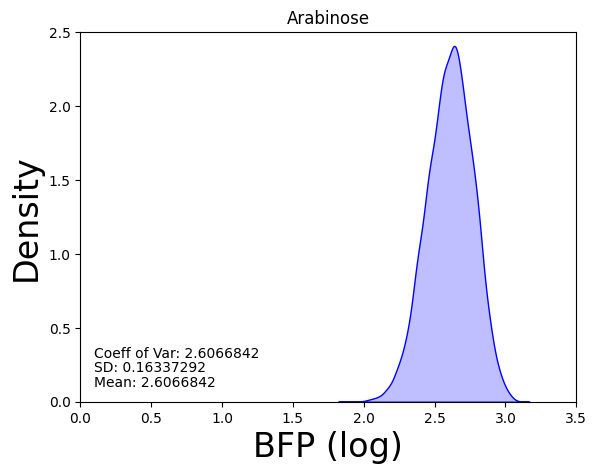

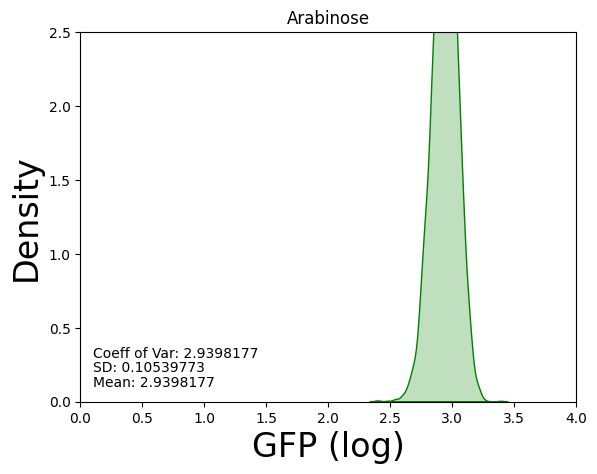

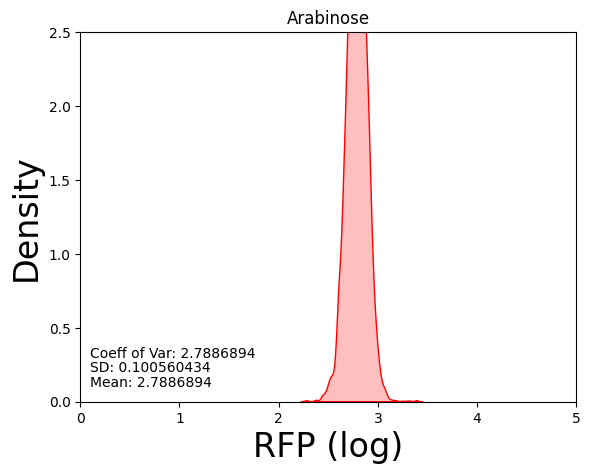

B02
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
B02: 0.00 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


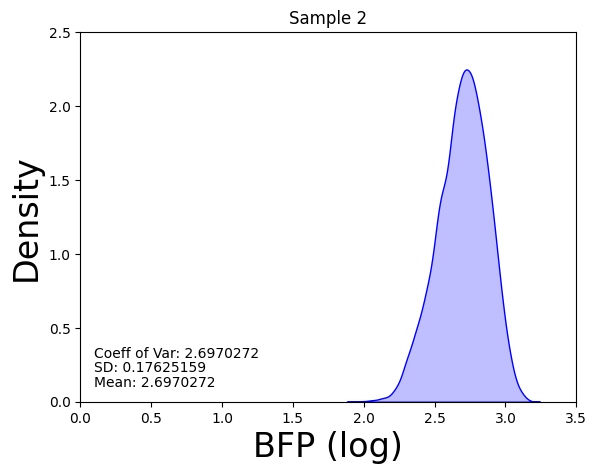

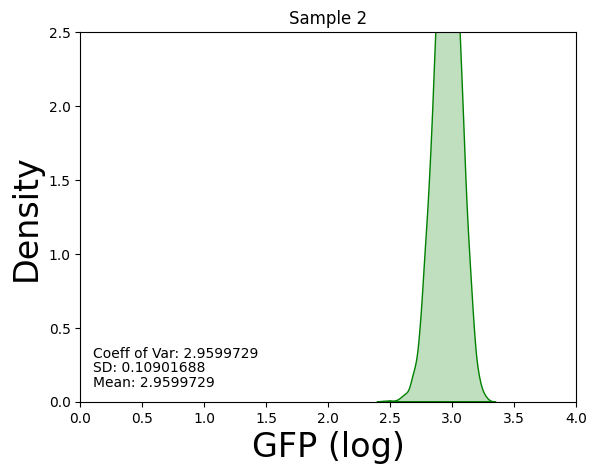

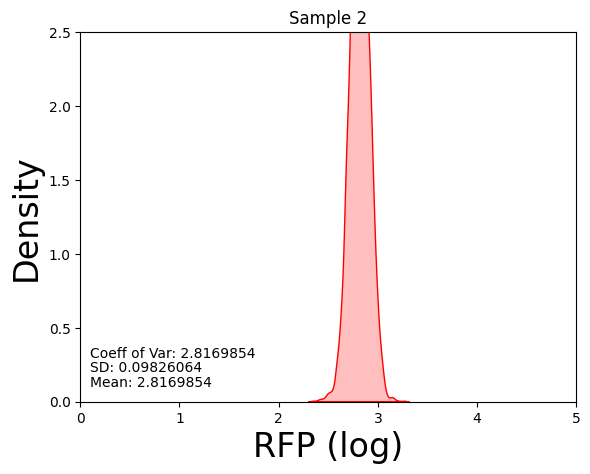

B03
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
B03: 0.00 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


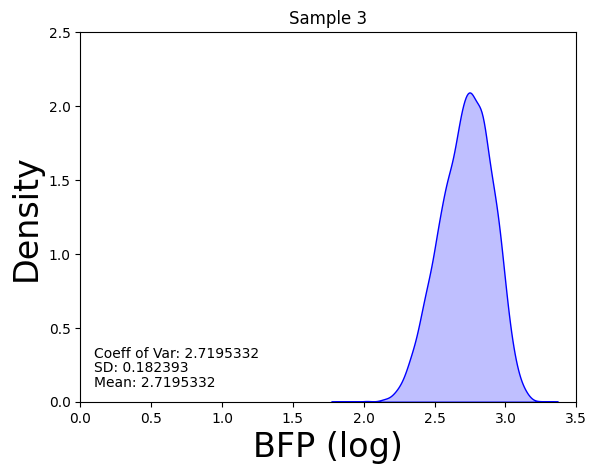

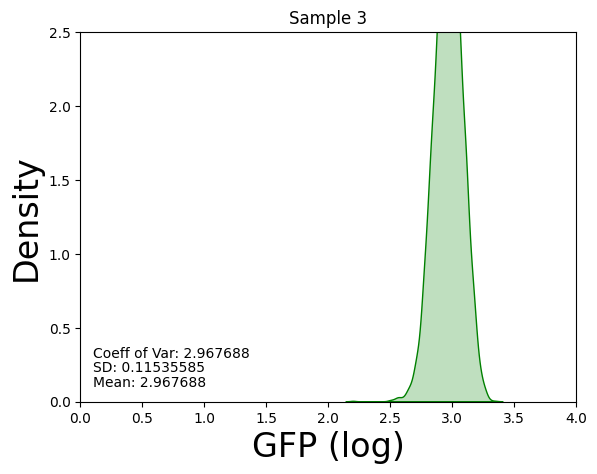

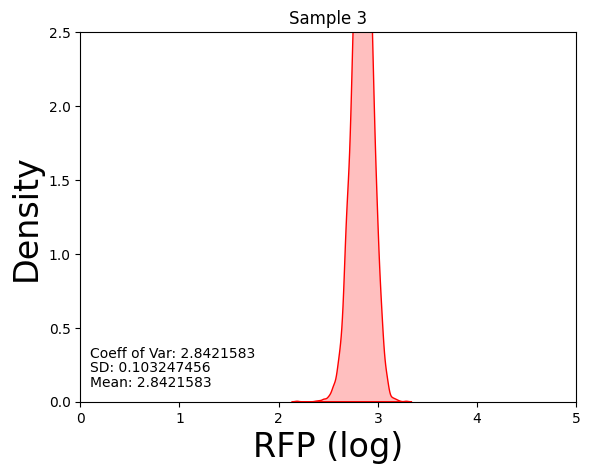

B04
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
B04: 0.01 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


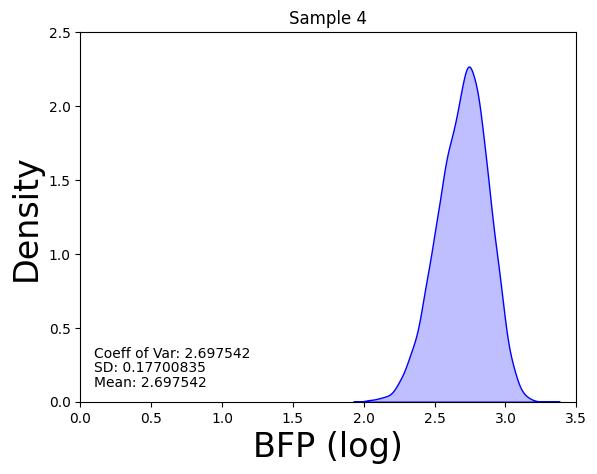

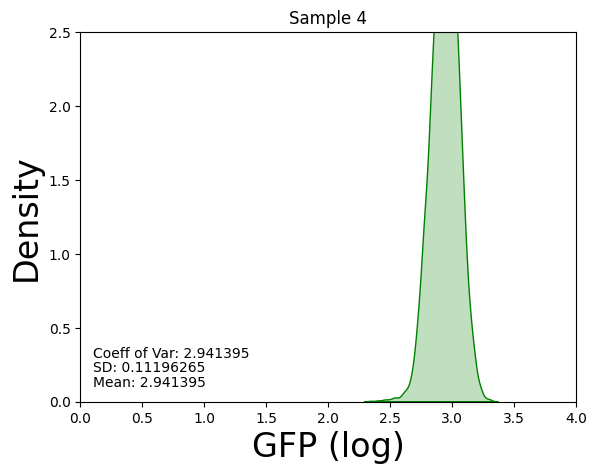

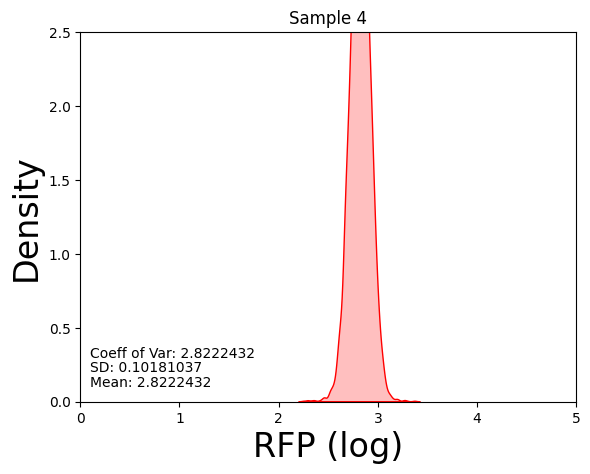

B05
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
B05: 0.01 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


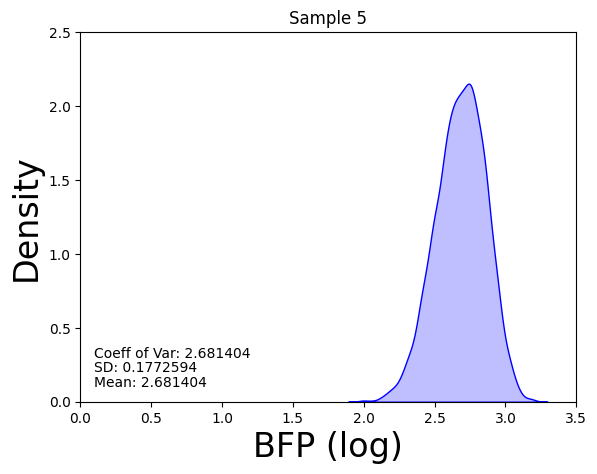

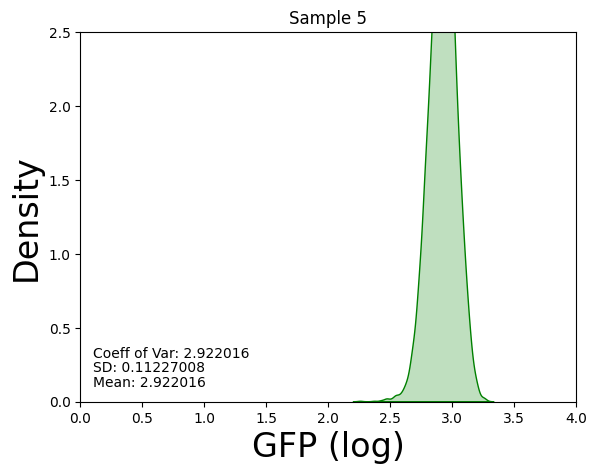

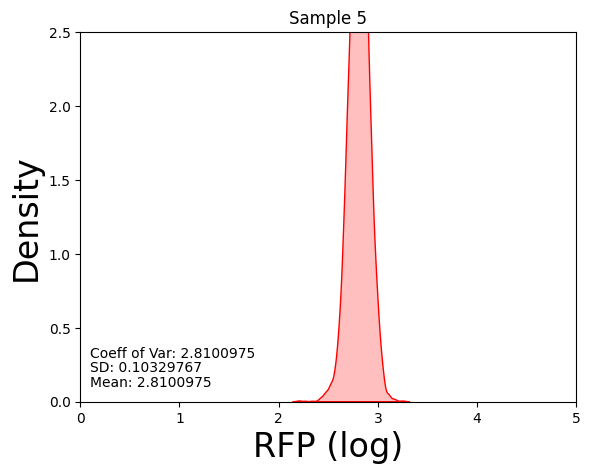

B06
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
B06: 0.01 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


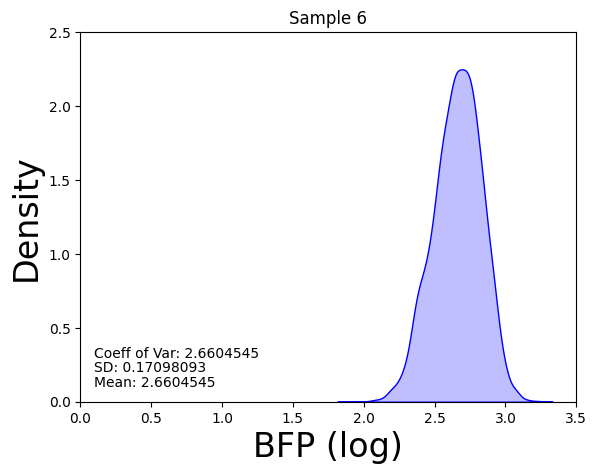

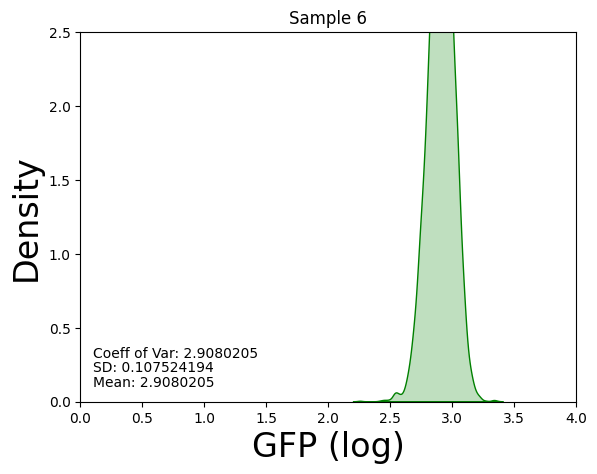

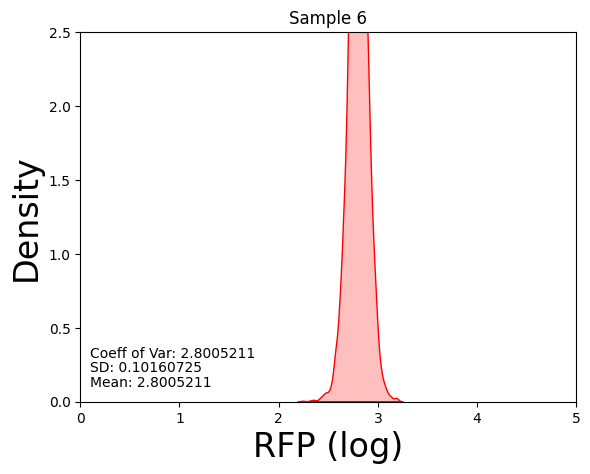

B07
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
B07: 0.00 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


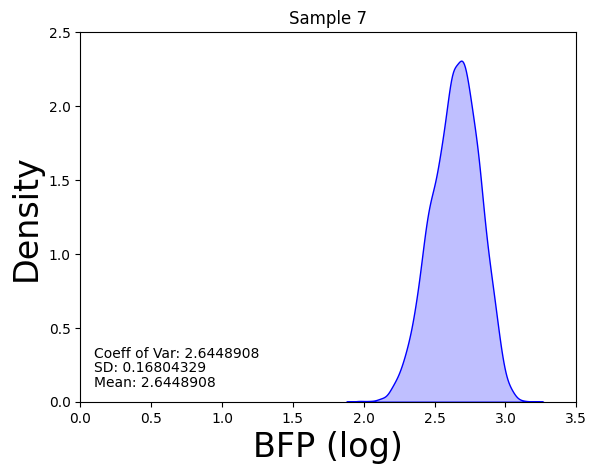

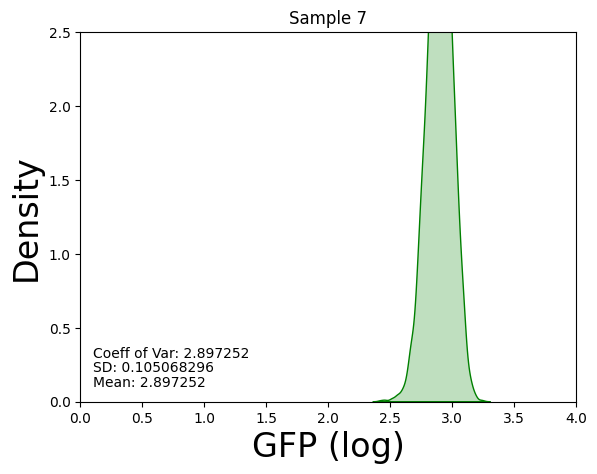

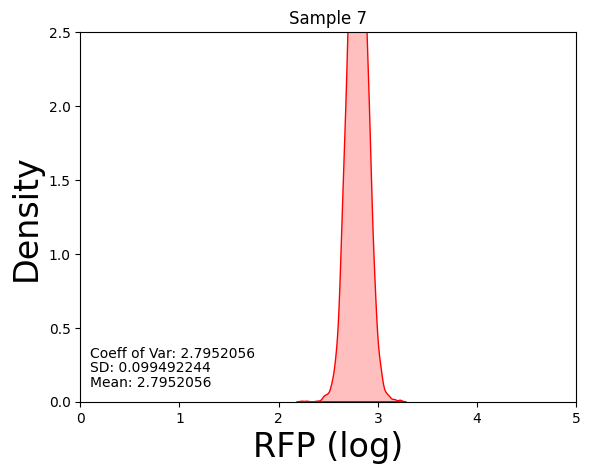

B08
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
B08: 0.00 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


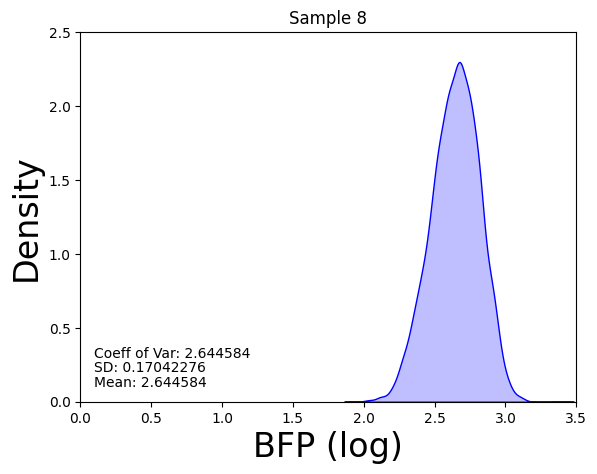

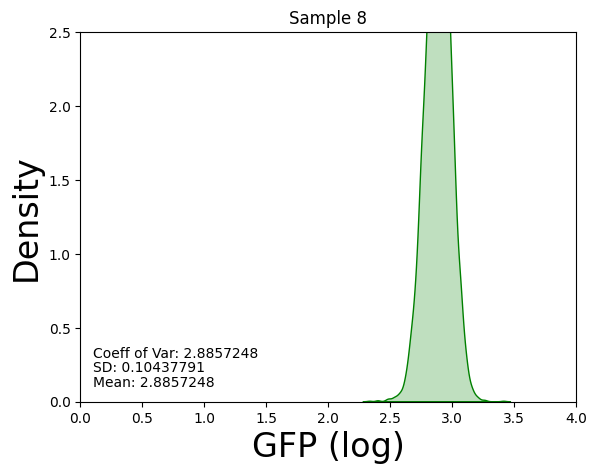

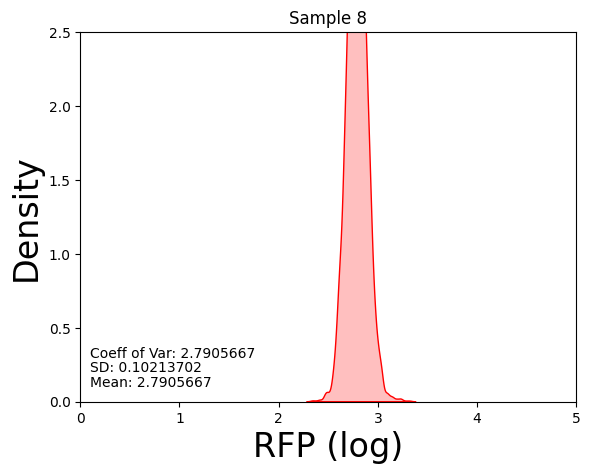

B09
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
B09: 0.01 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


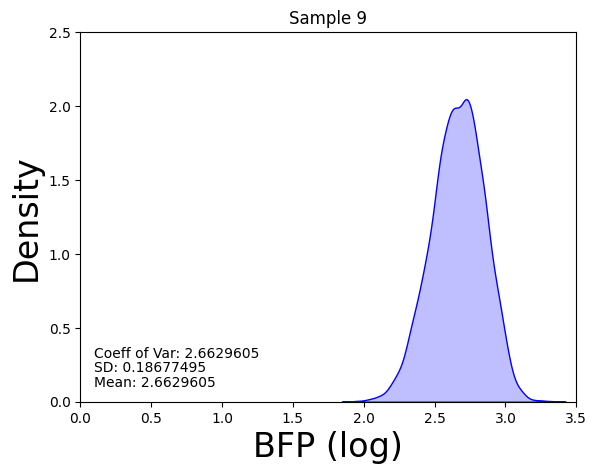

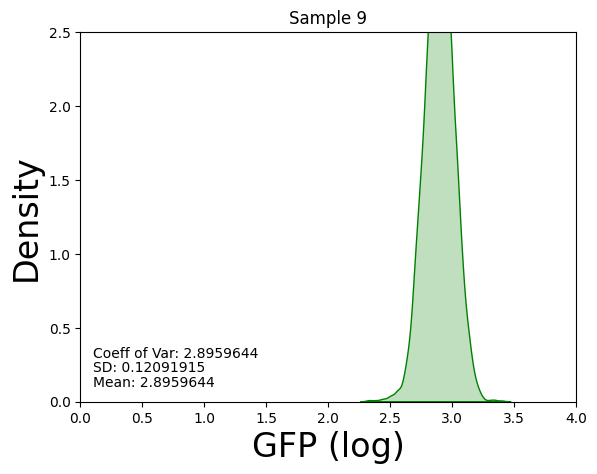

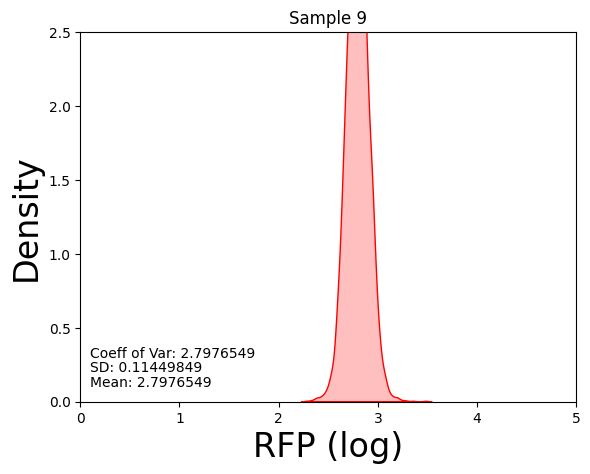

B10
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
B10: 0.01 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


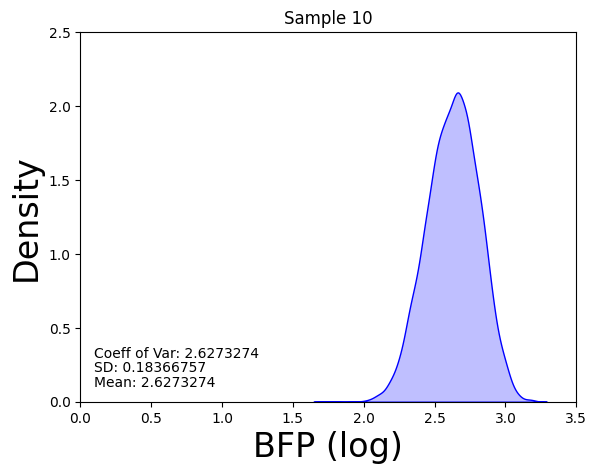

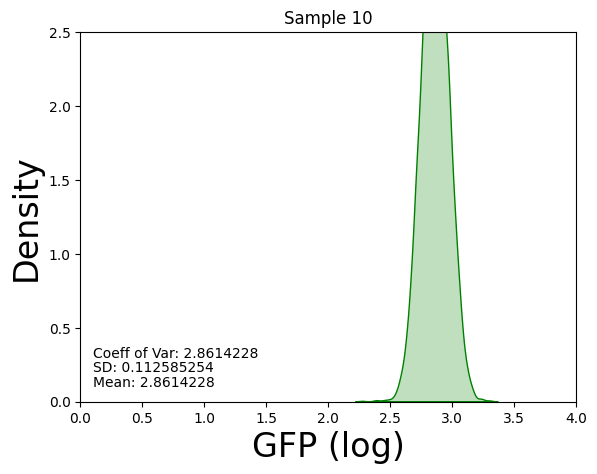

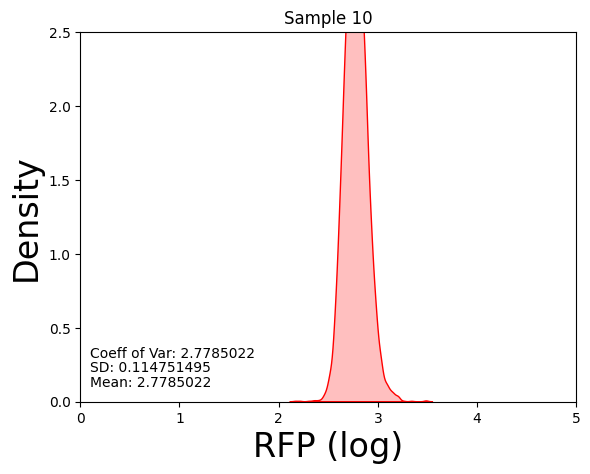

B11
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
B11: 0.00 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


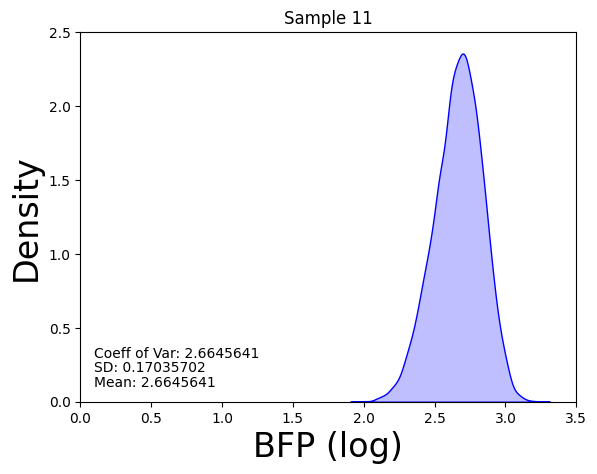

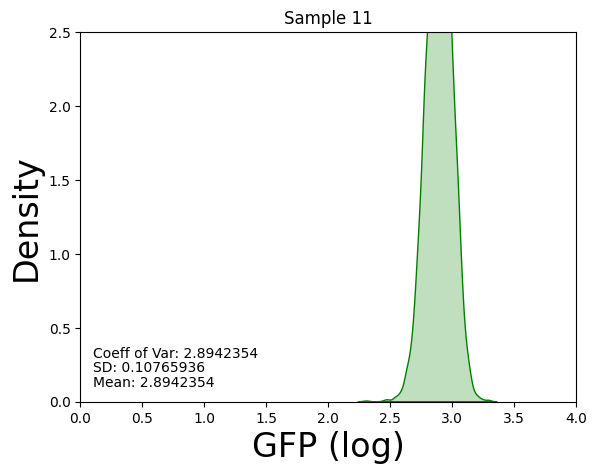

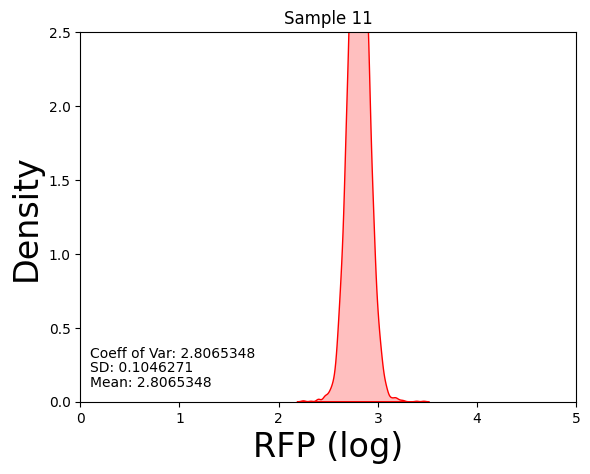

B12
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
B12: 0.01 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


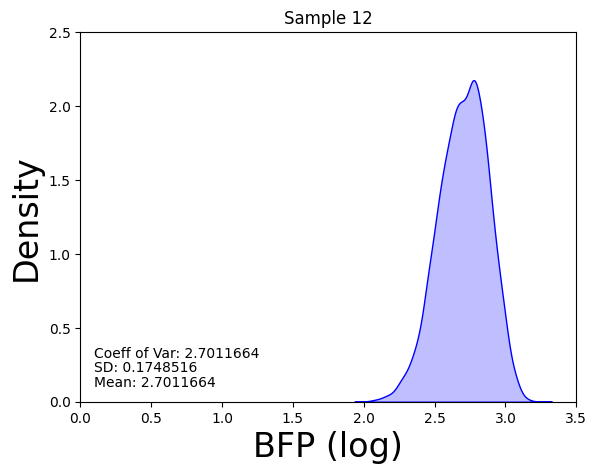

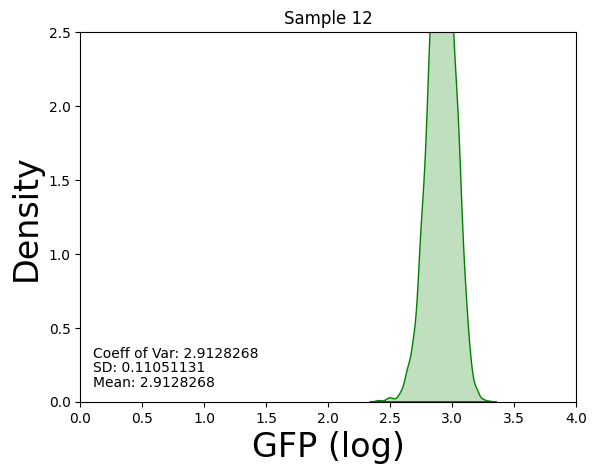

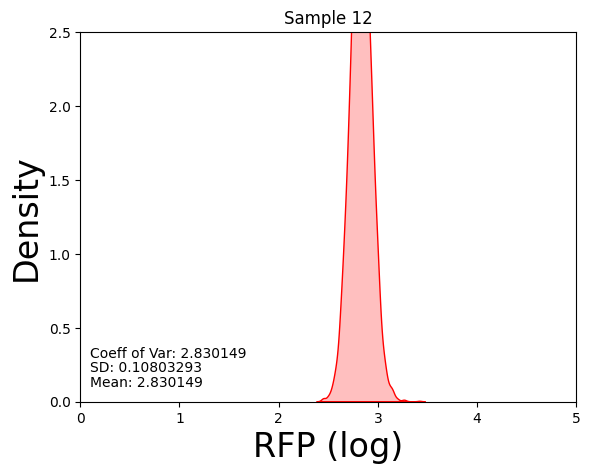

C01
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
C01: 0.01 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


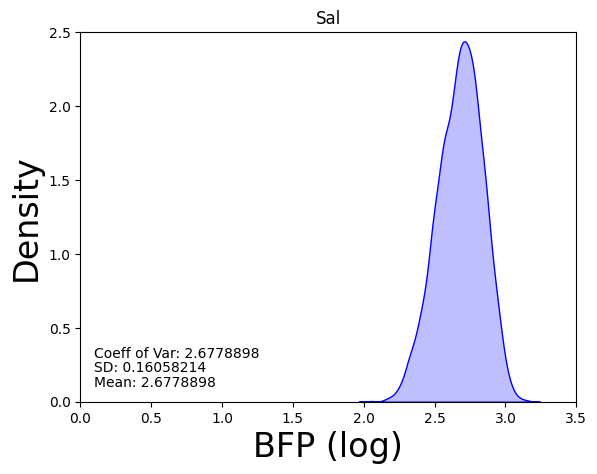

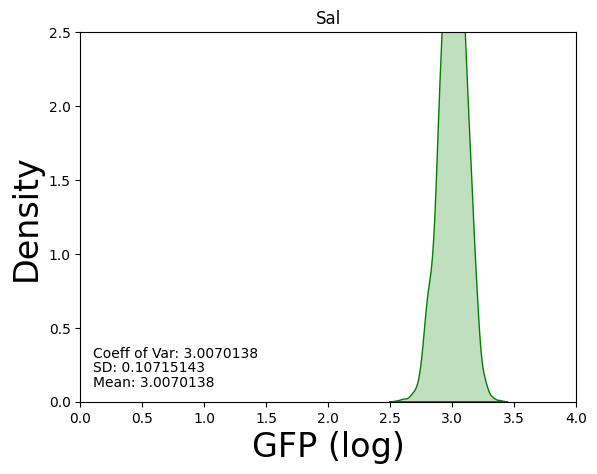

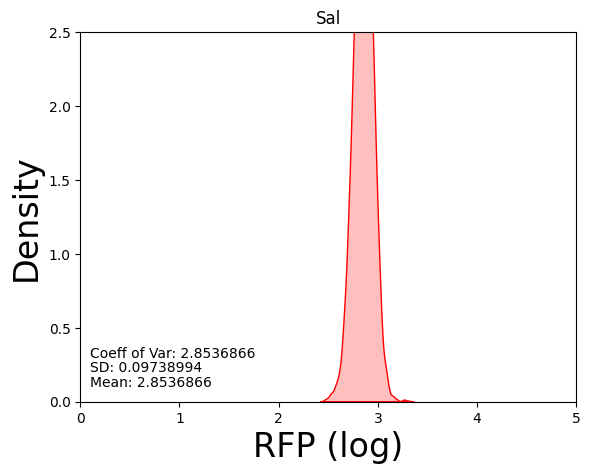

C02
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
C02: 0.01 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


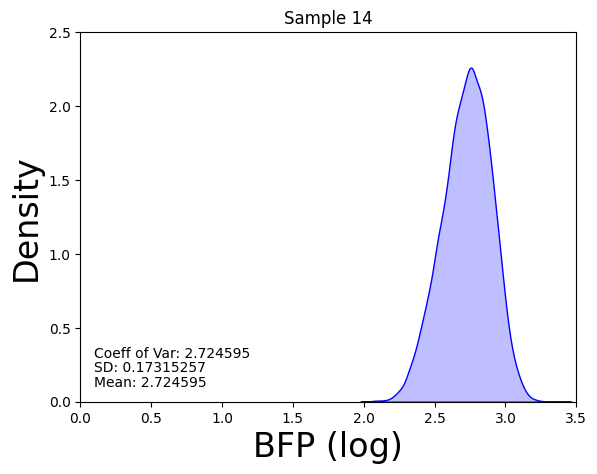

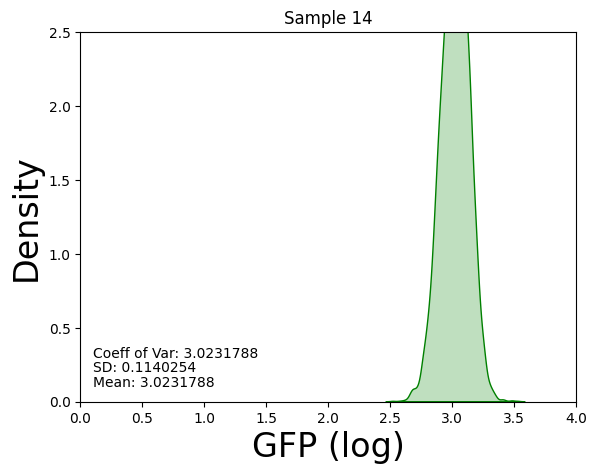

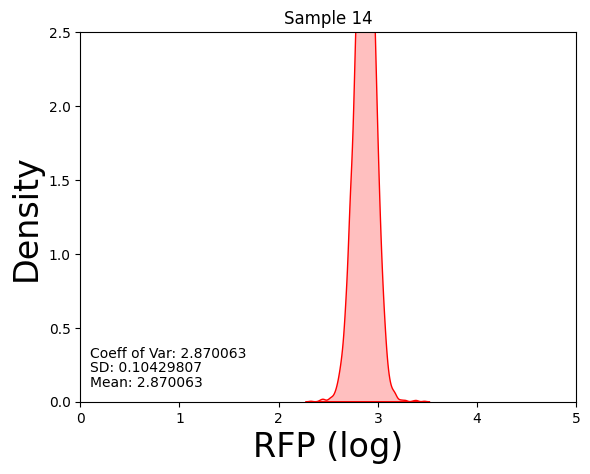

C03
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
C03: 0.01 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


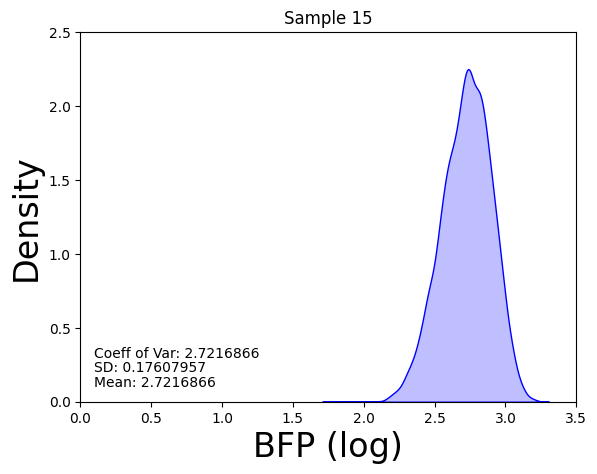

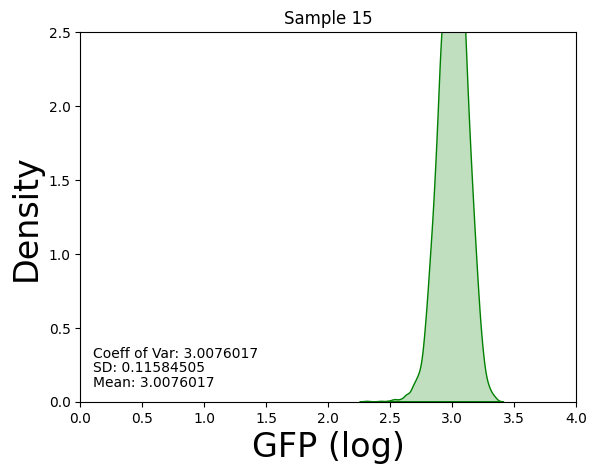

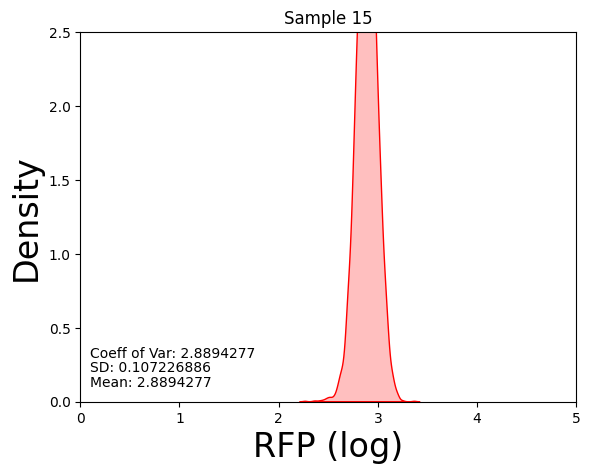

C04
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
C04: 0.02 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


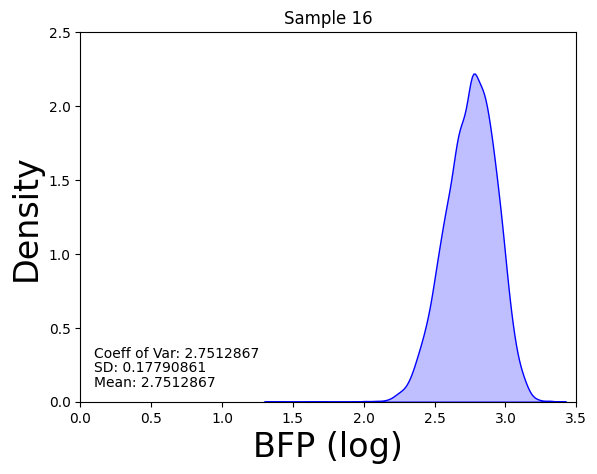

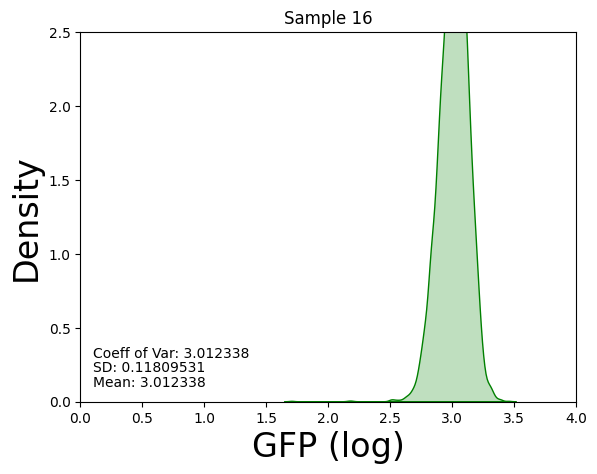

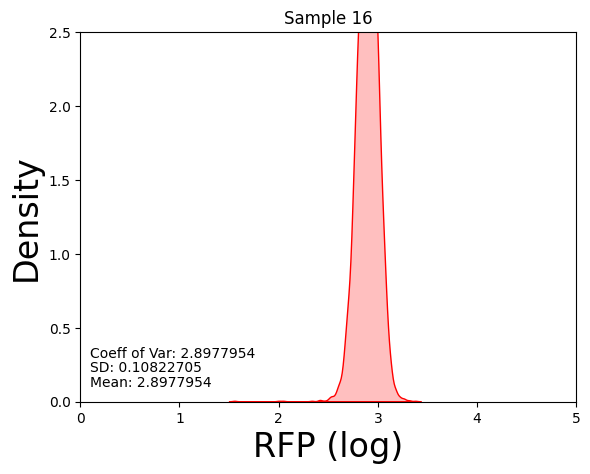

C05
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
C05: 0.02 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


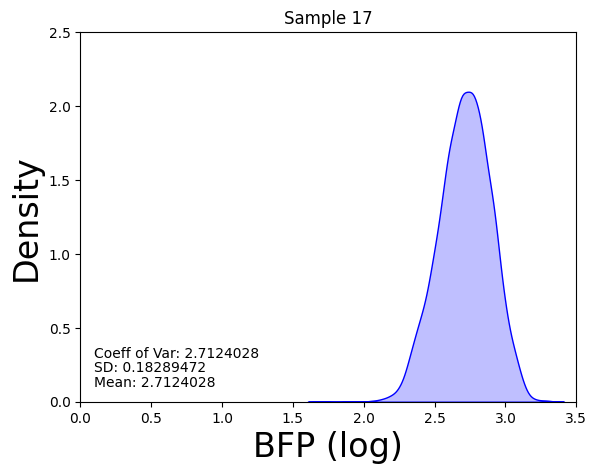

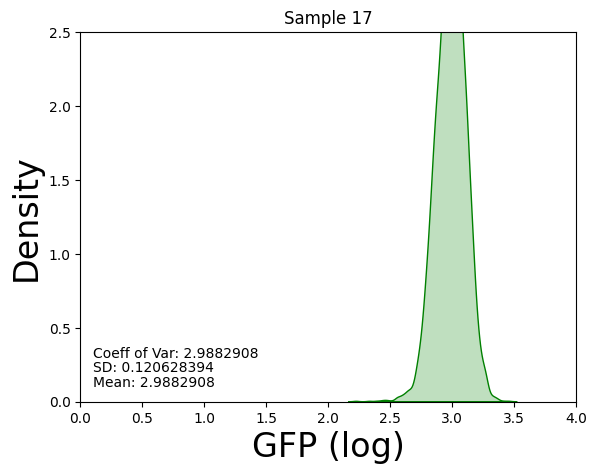

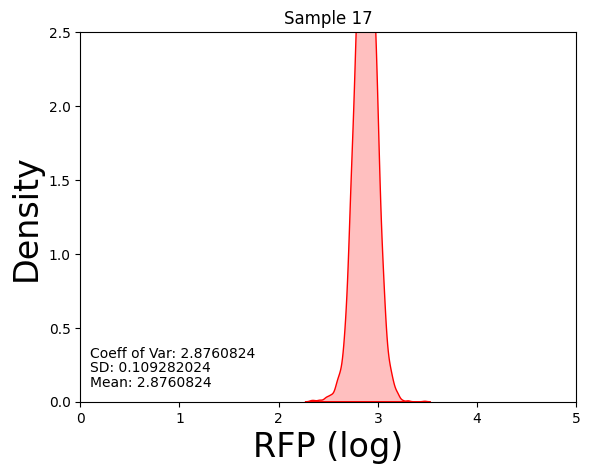

C06
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
C06: 0.02 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


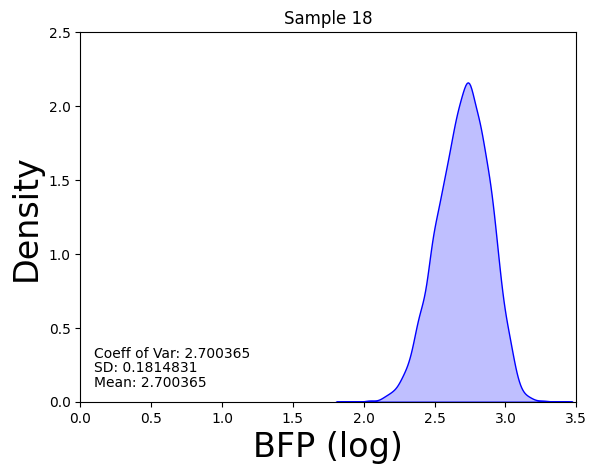

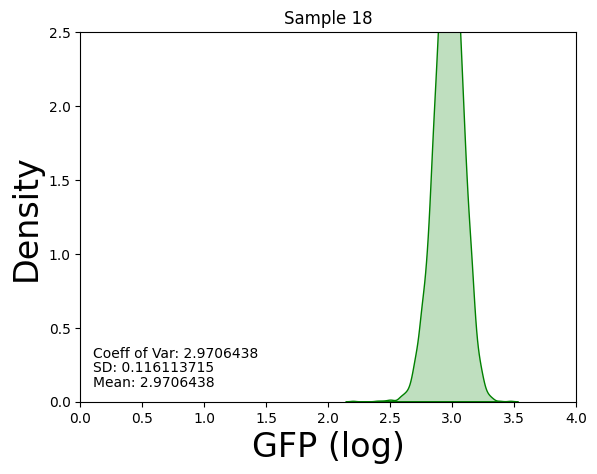

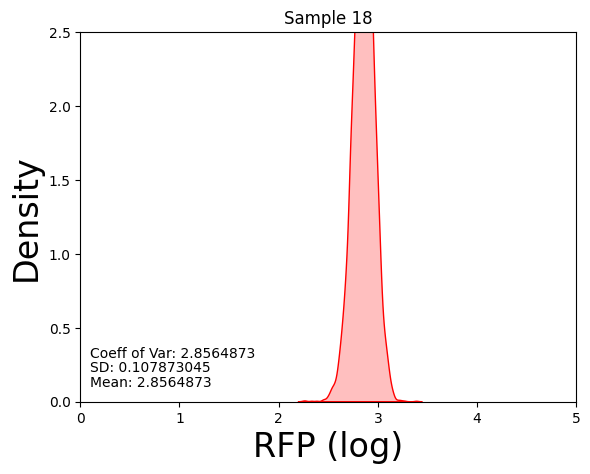

C07
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
C07: 0.01 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


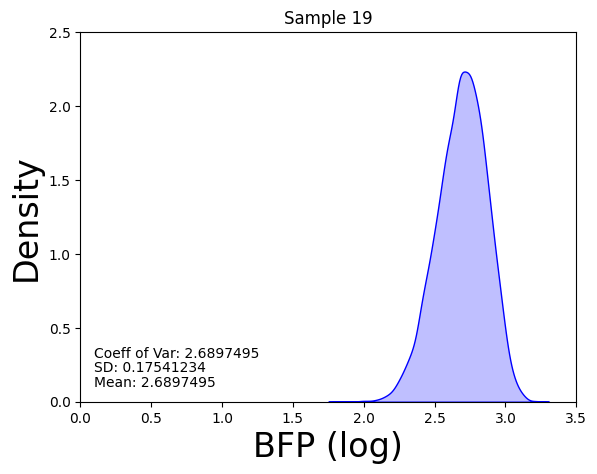

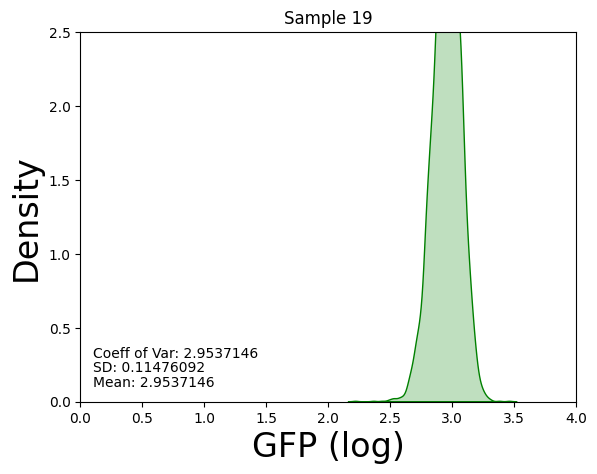

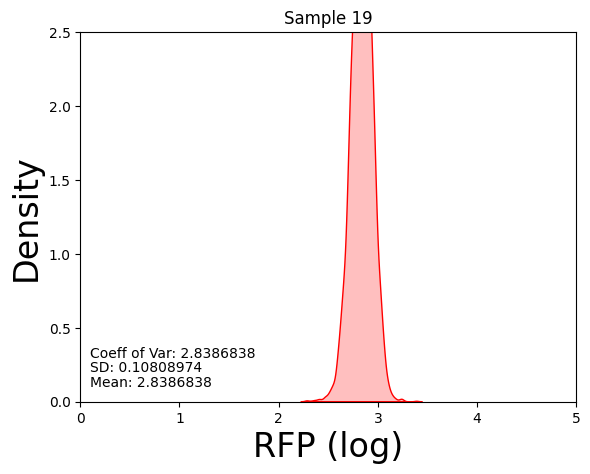

C08
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
C08: 0.01 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


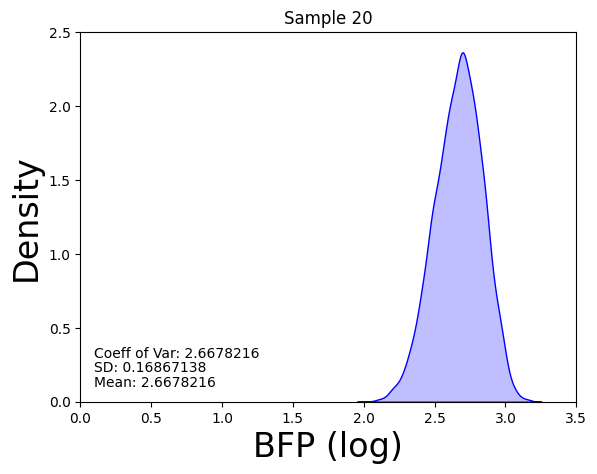

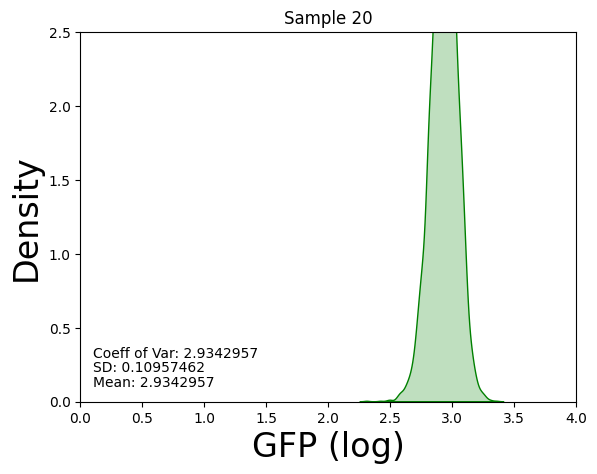

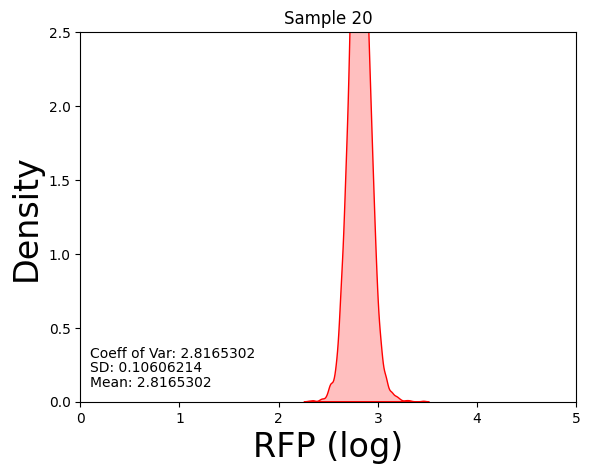

C09
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
C09: 0.01 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


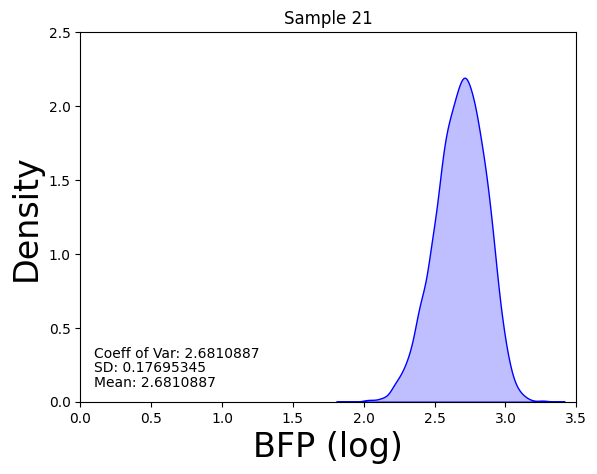

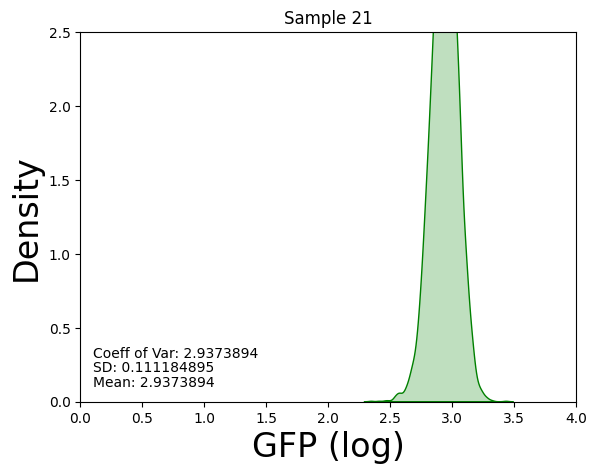

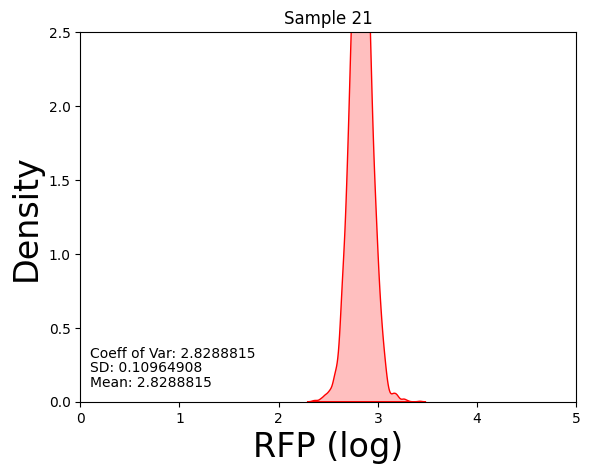

C10
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
C10: 0.01 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


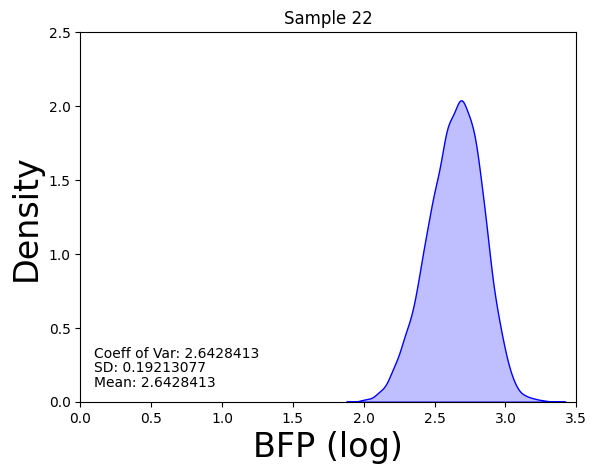

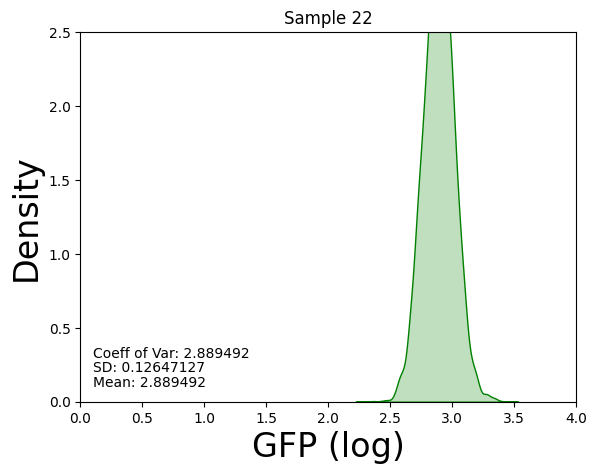

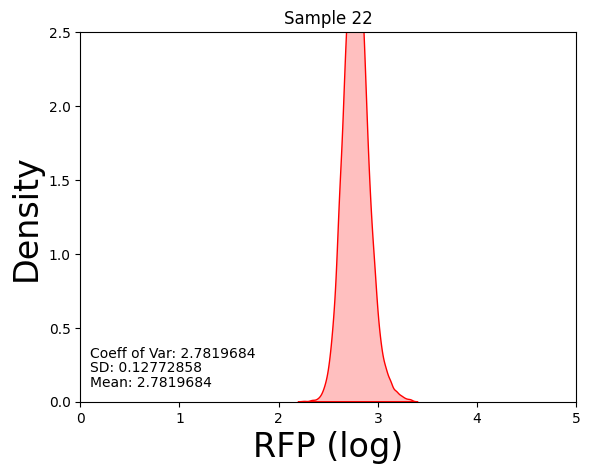

C11
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
C11: 0.01 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


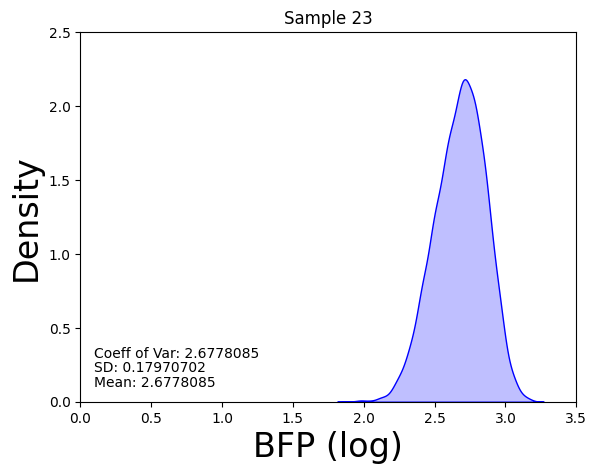

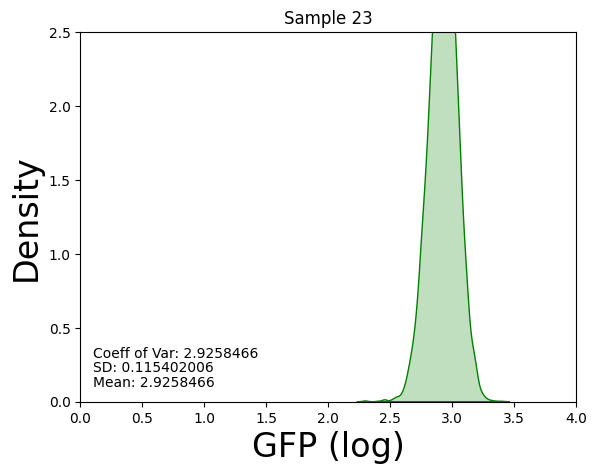

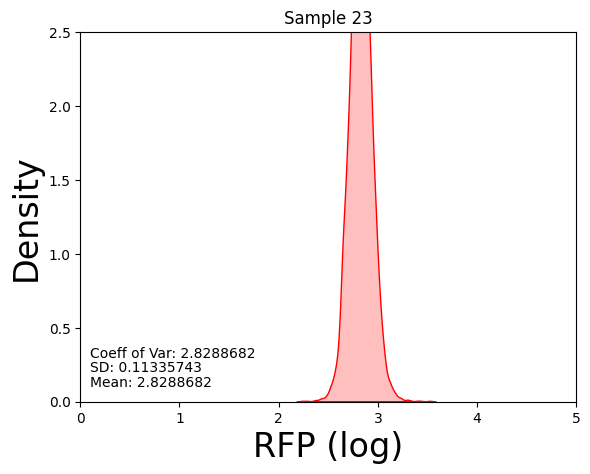

C12
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
C12: 0.01 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


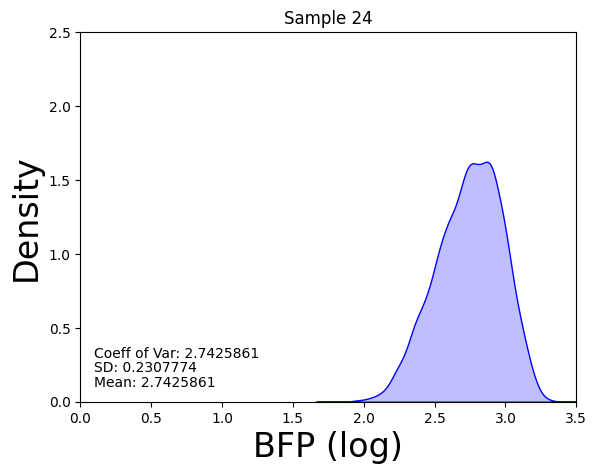

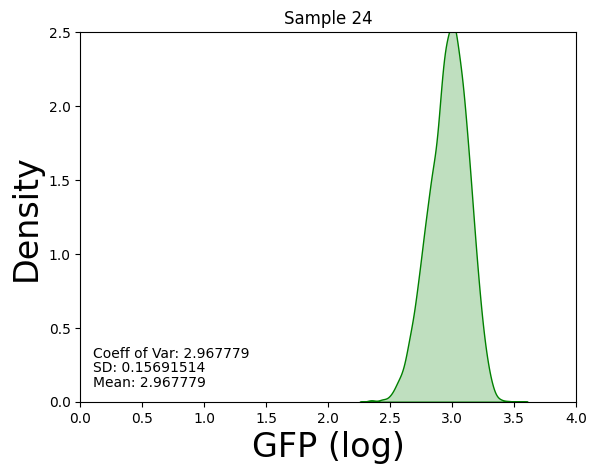

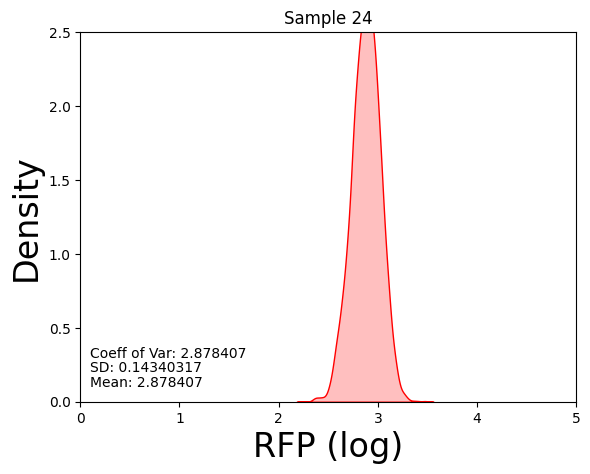

D01
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
D01: 0.00 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


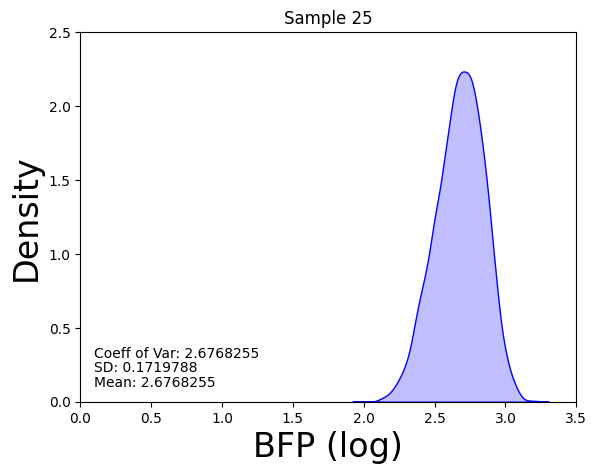

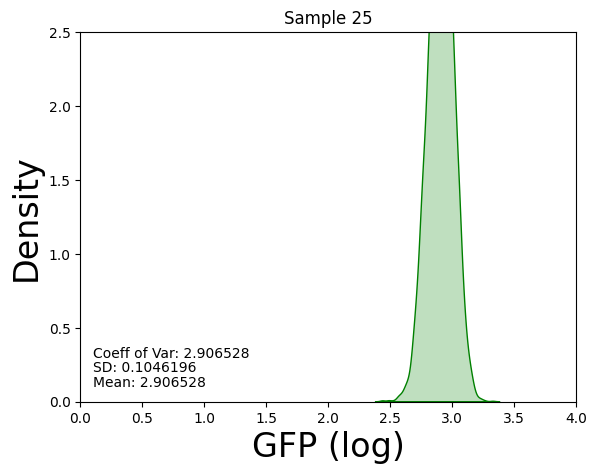

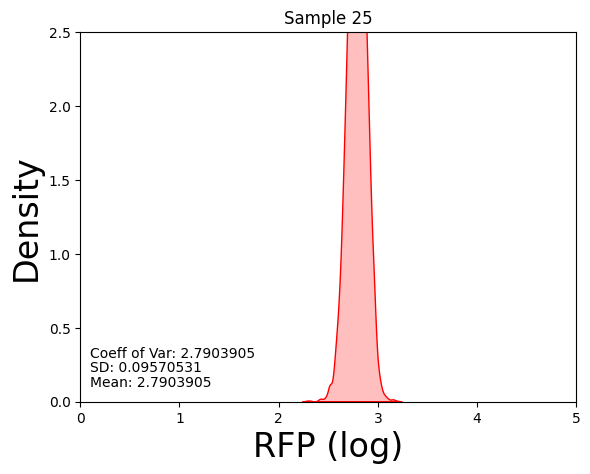

D02
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
D02: 0.00 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


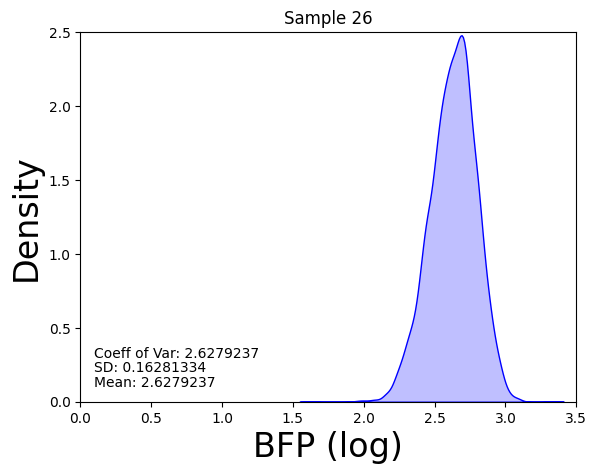

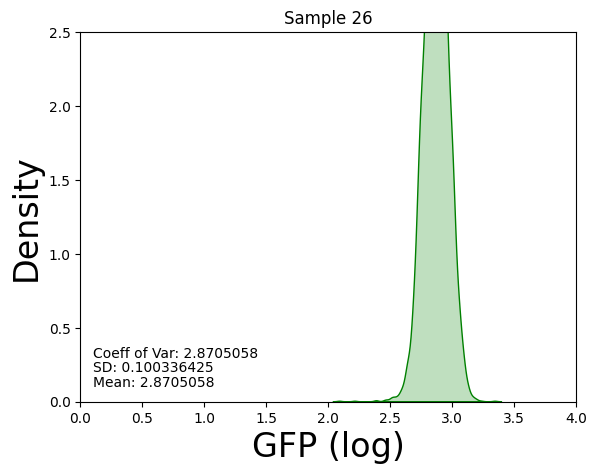

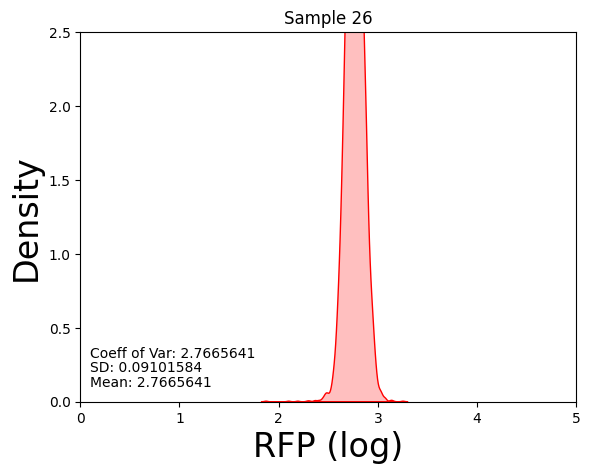

D03
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
D03: 0.00 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


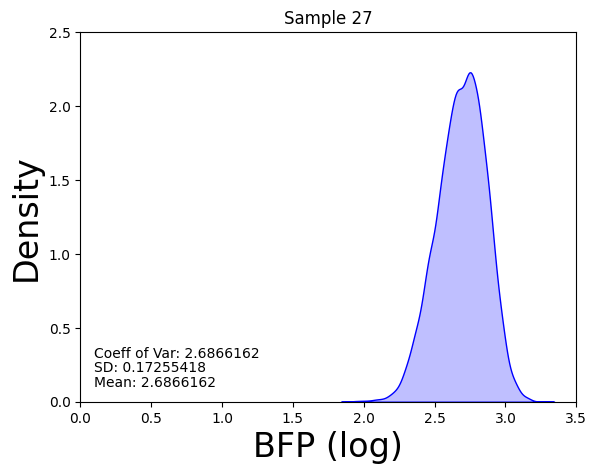

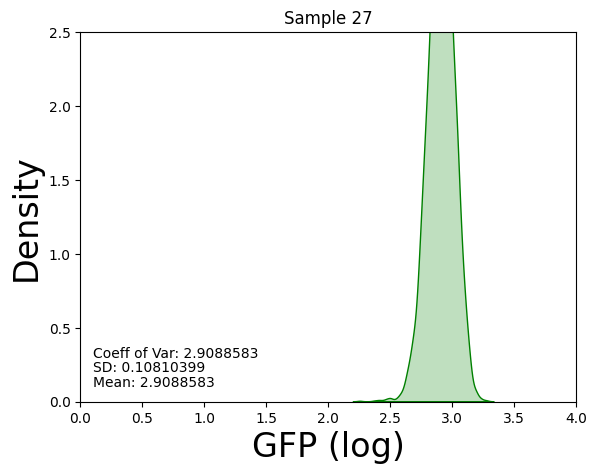

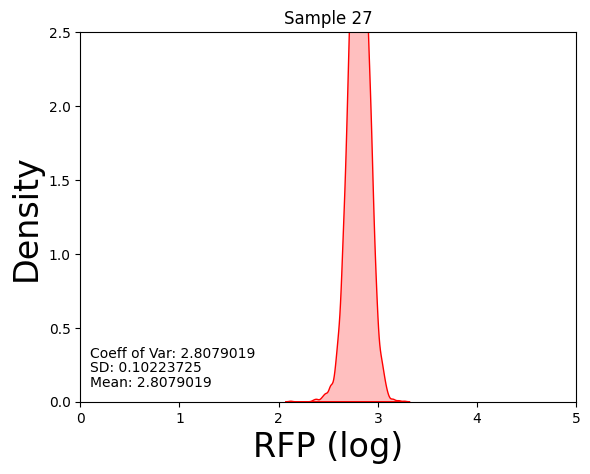

D04
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
D04: 0.01 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


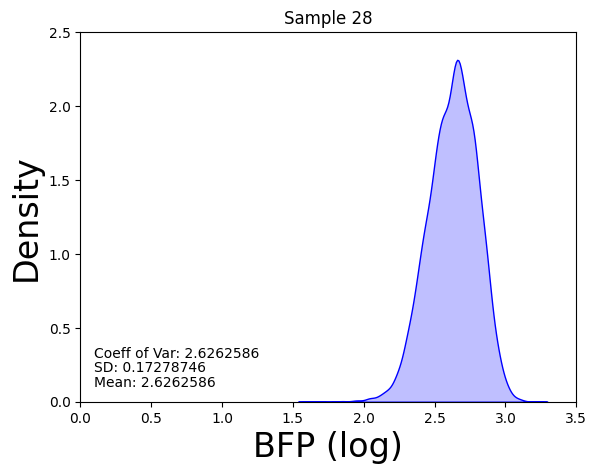

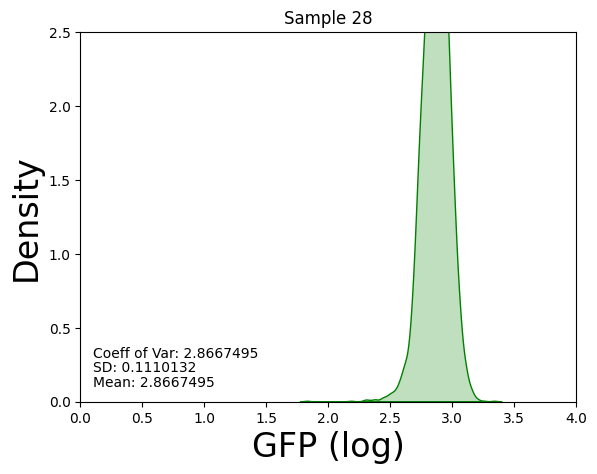

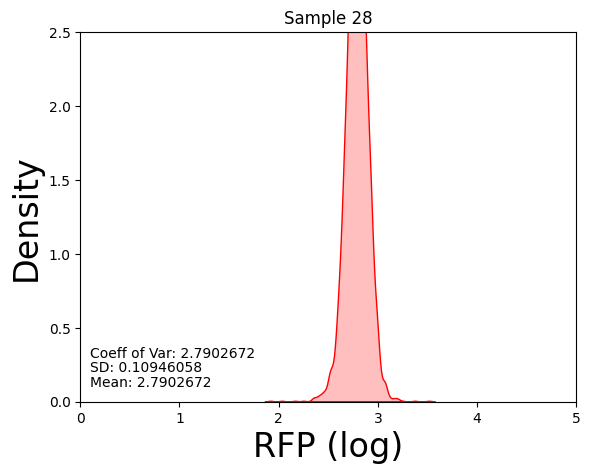

D05
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
D05: 0.01 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


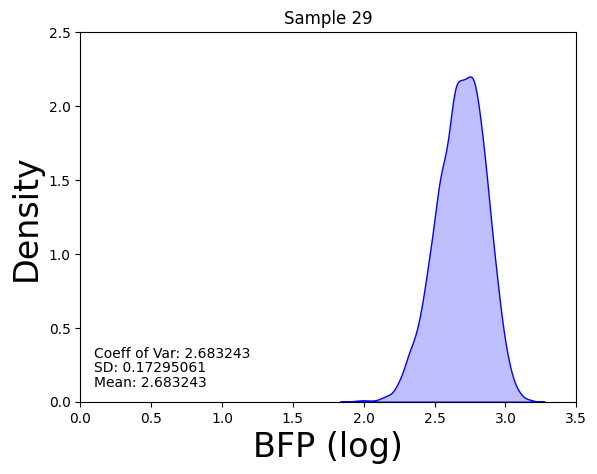

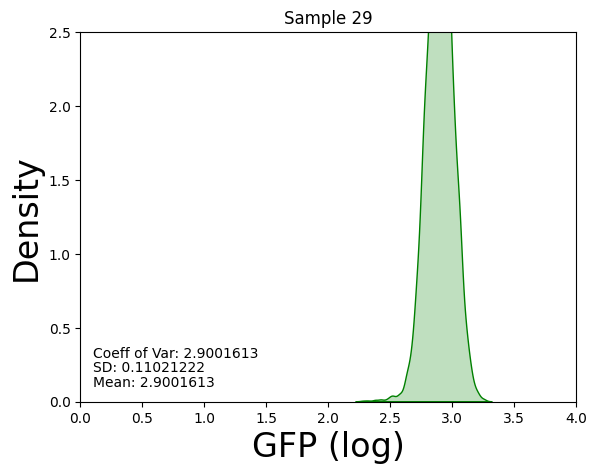

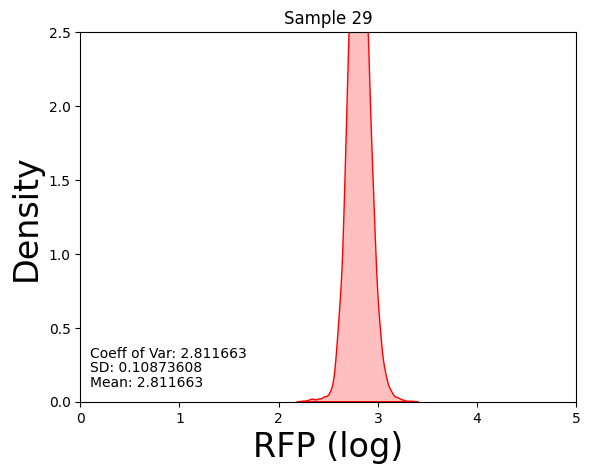

D06
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
D06: 0.01 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


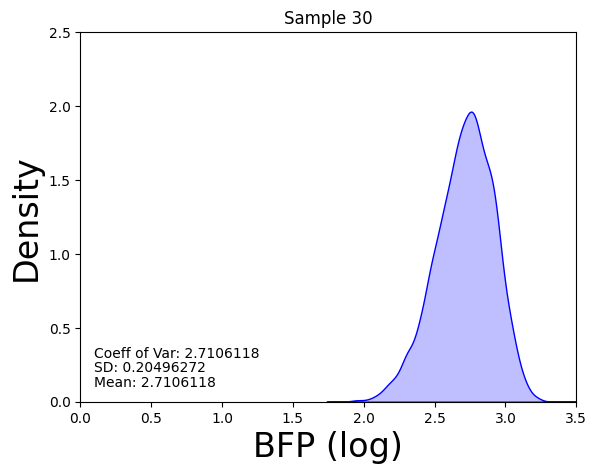

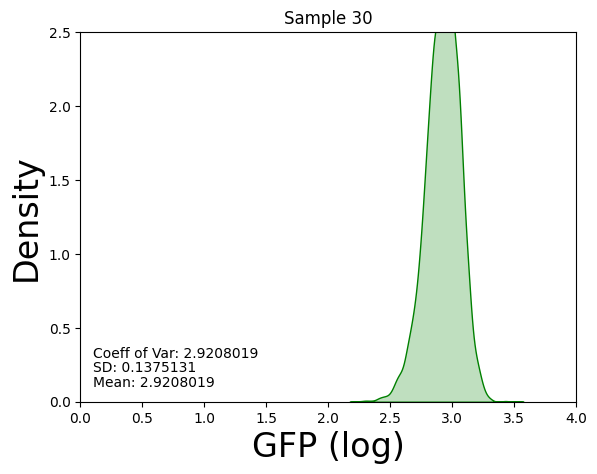

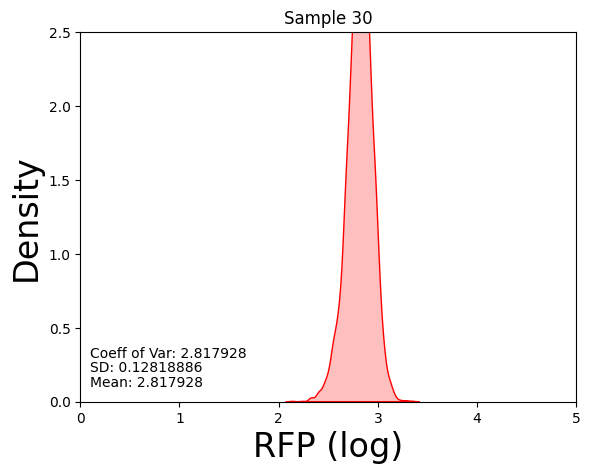

D07
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
D07: 0.01 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


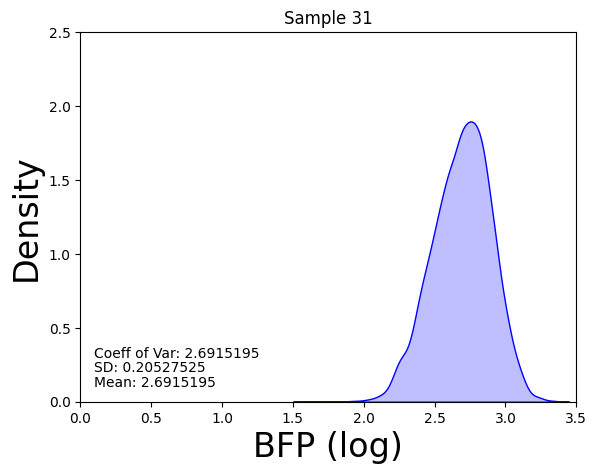

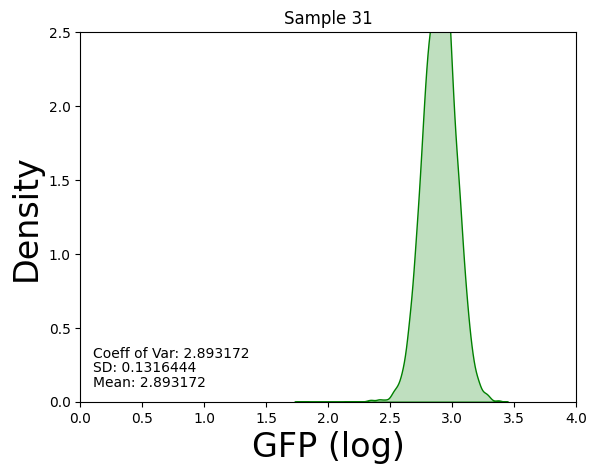

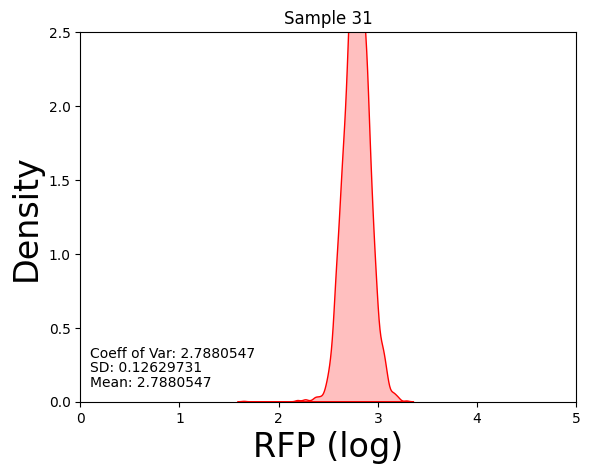

D08
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
D08: 0.00 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


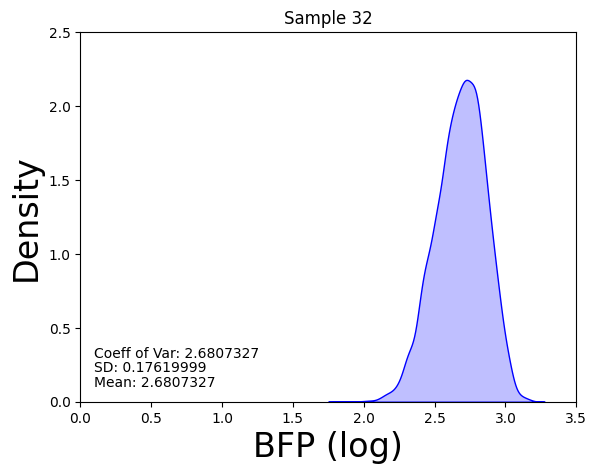

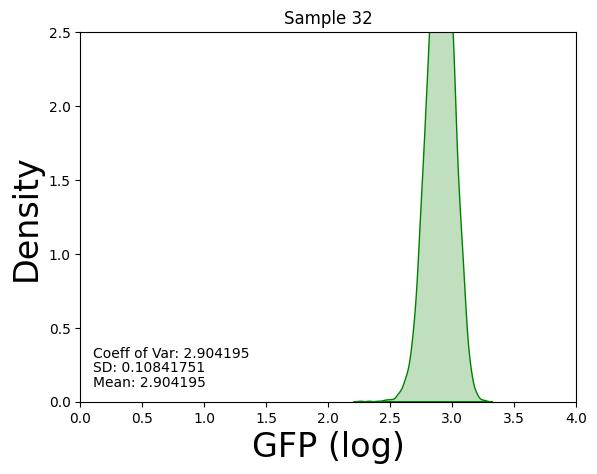

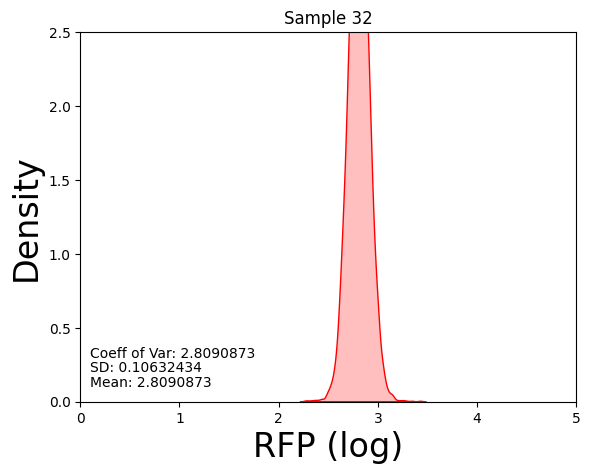

D09
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
D09: 0.01 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


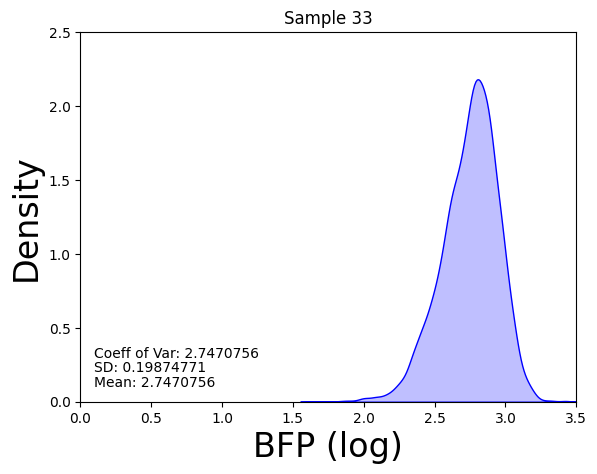

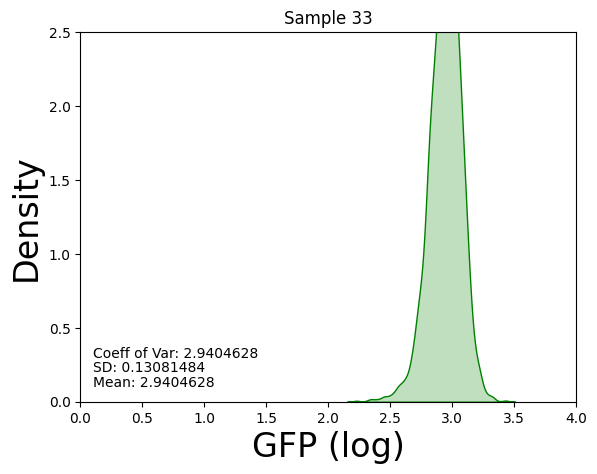

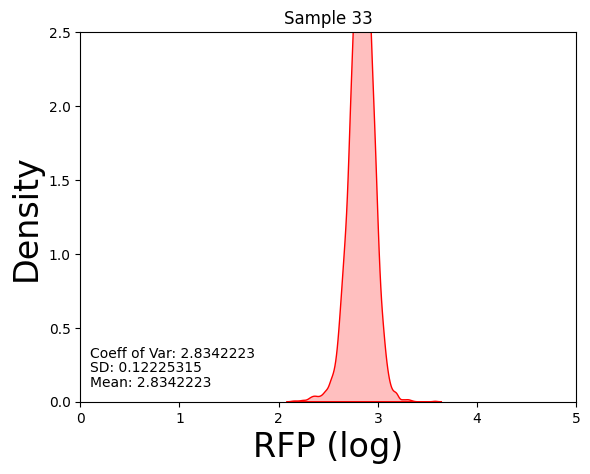

D10
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
D10: 0.01 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


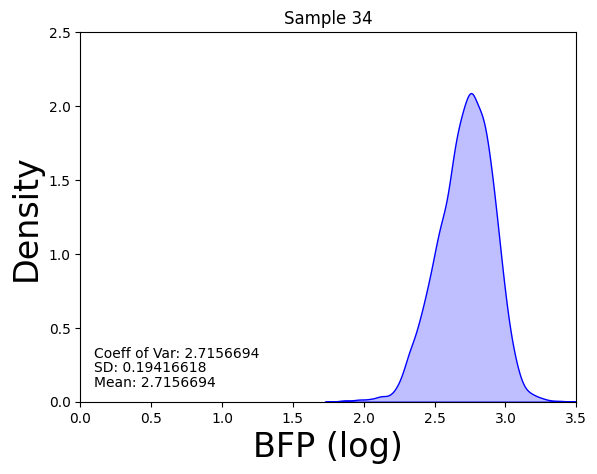

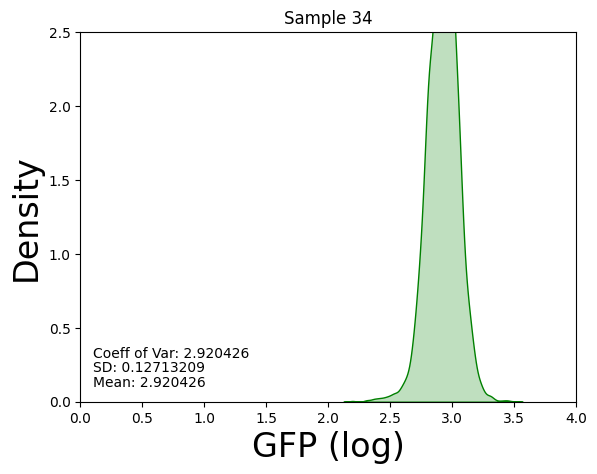

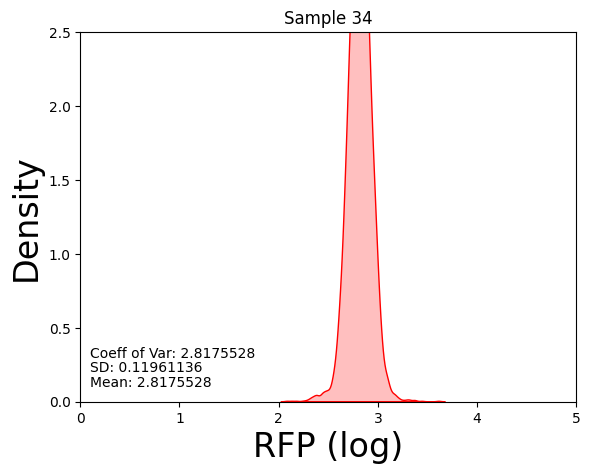

D11
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
D11: 0.00 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


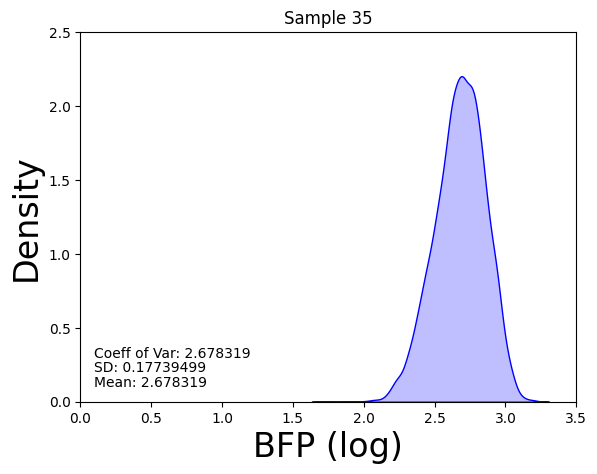

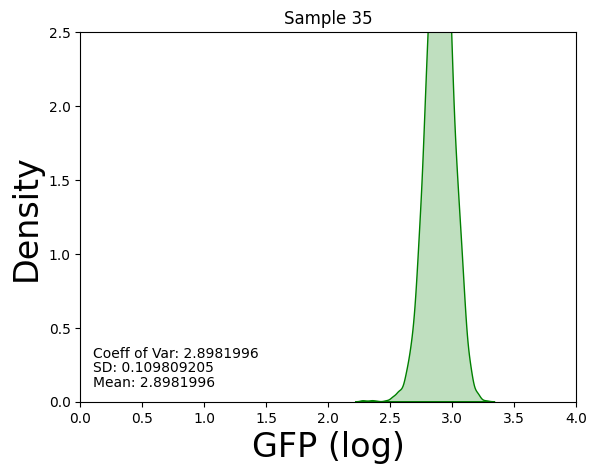

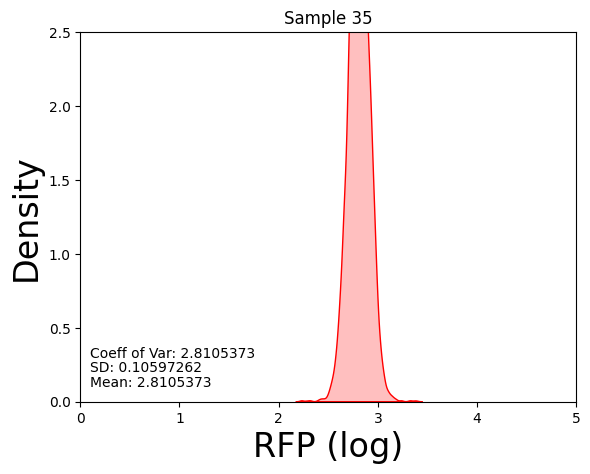

D12
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
D12: 0.00 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


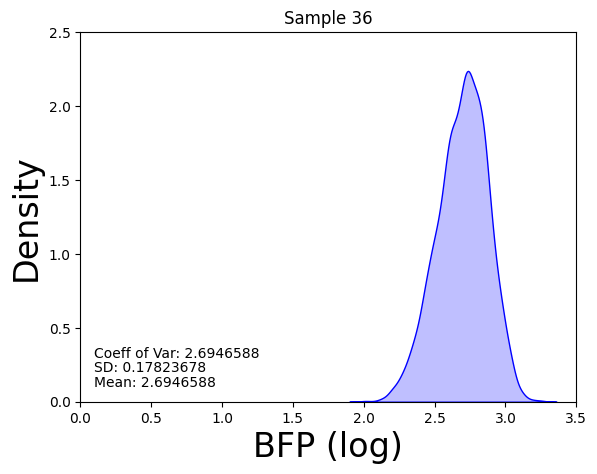

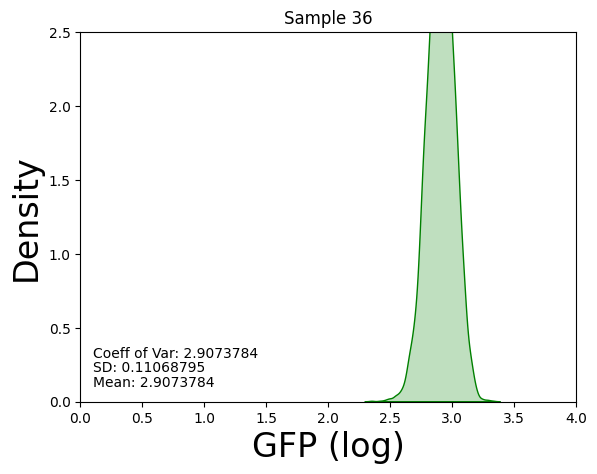

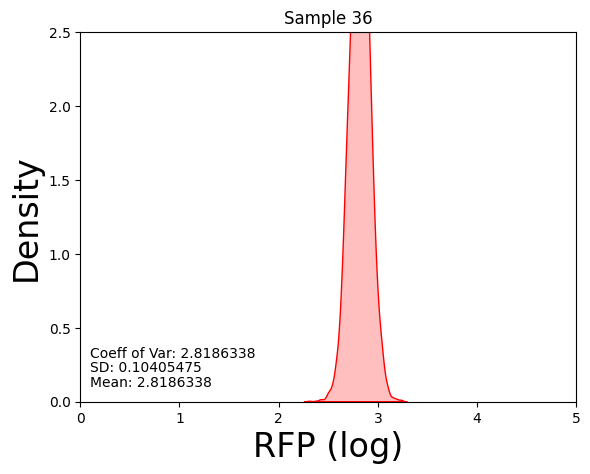

E01
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
E01: 0.00 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


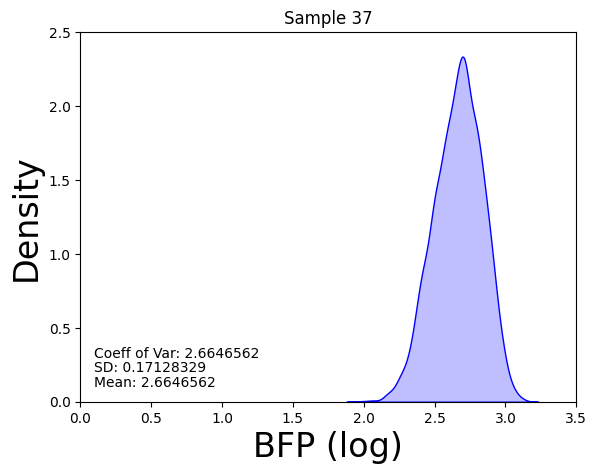

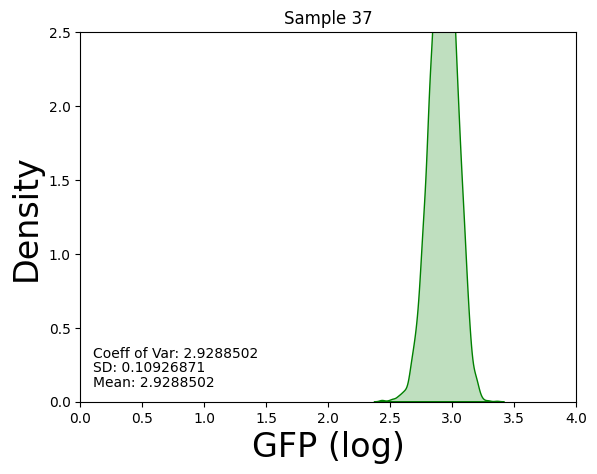

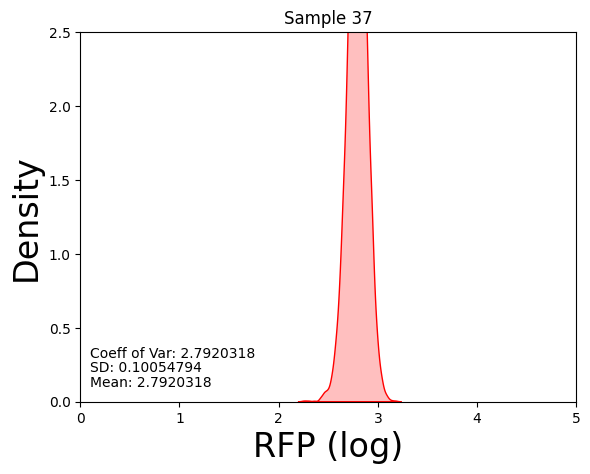

E02
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
E02: 0.00 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


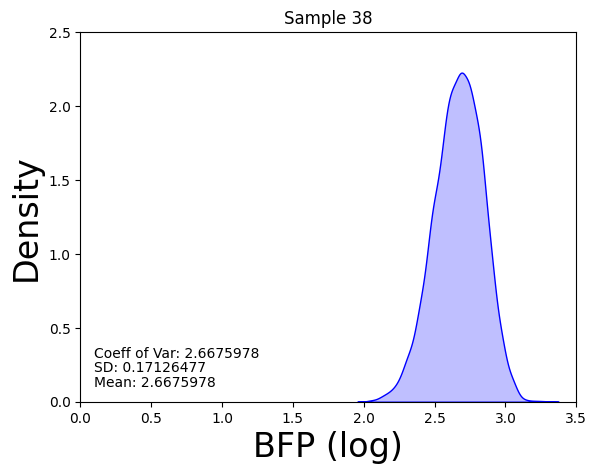

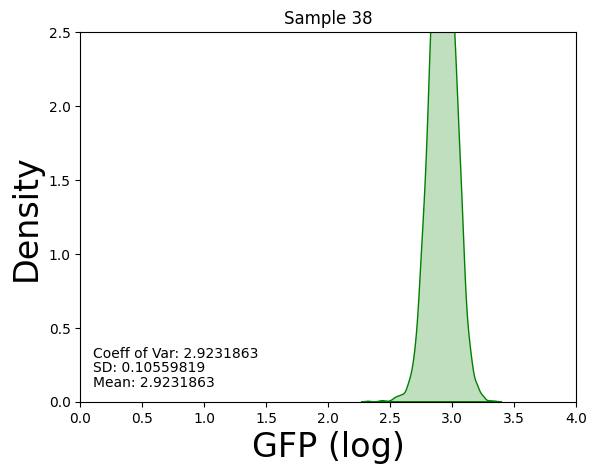

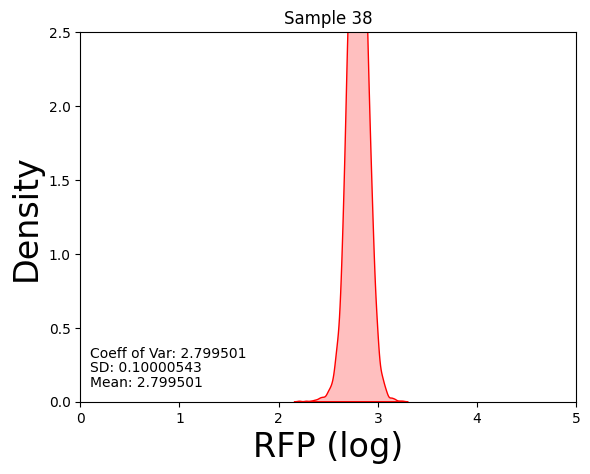

E03
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
E03: 0.03 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


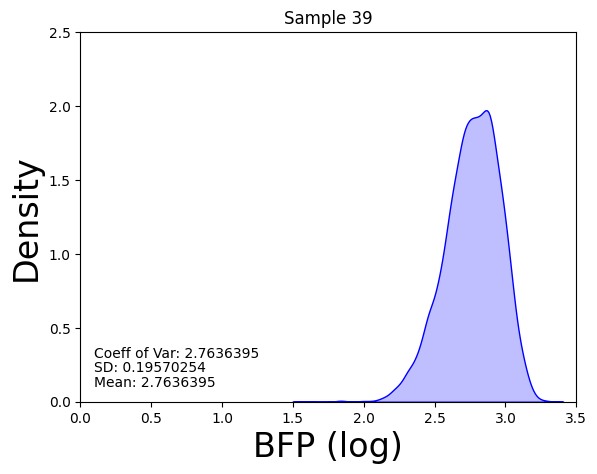

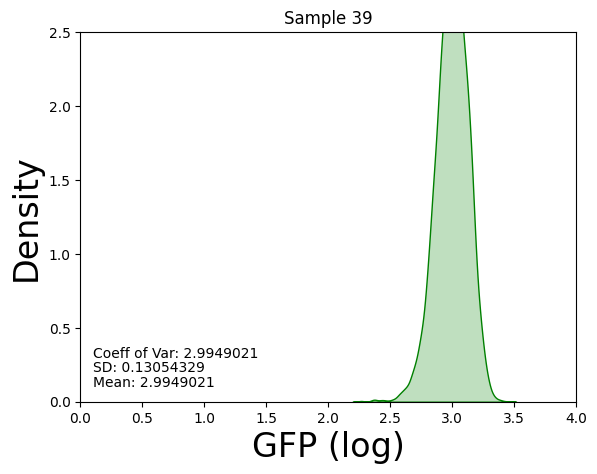

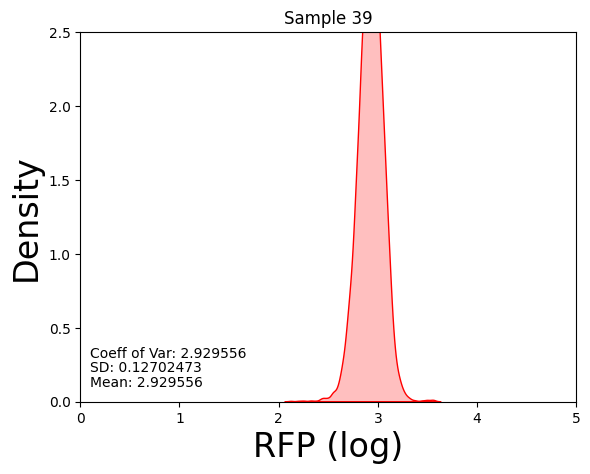

E04
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
E04: 0.00 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


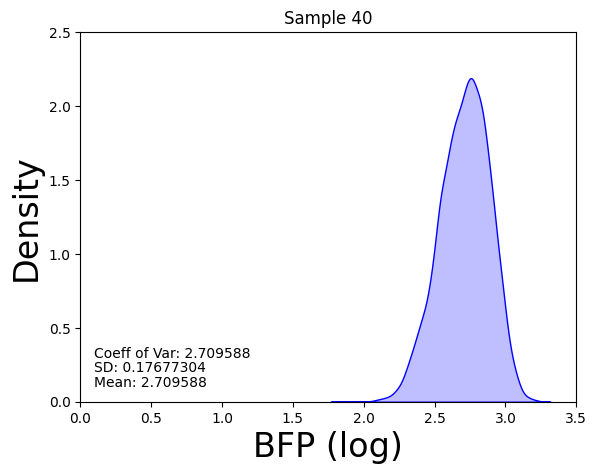

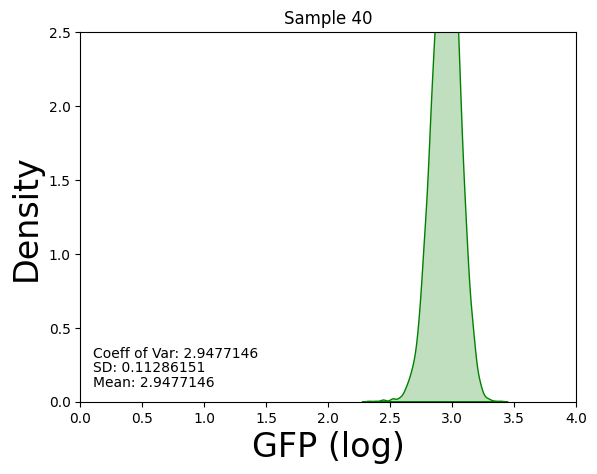

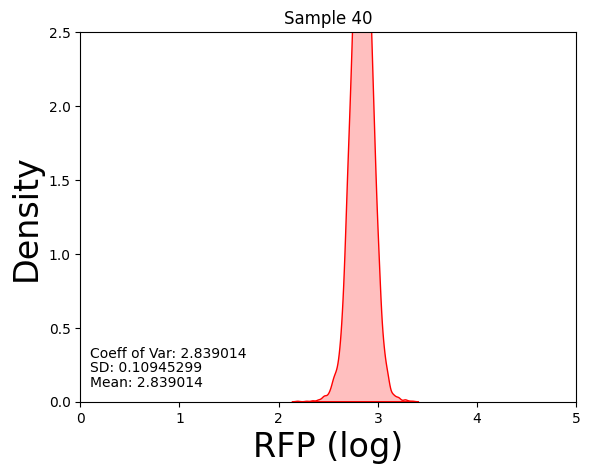

E05
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
E05: 0.00 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


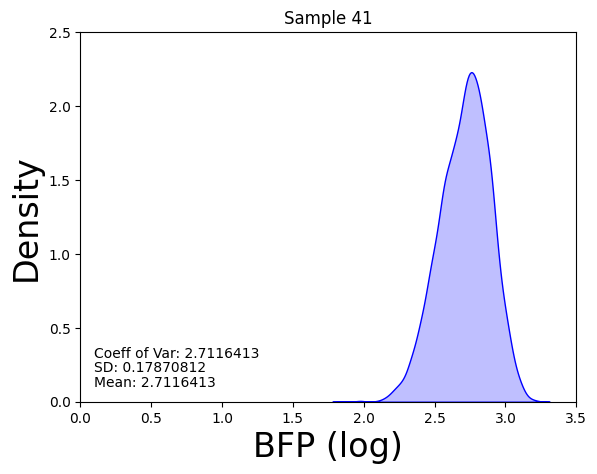

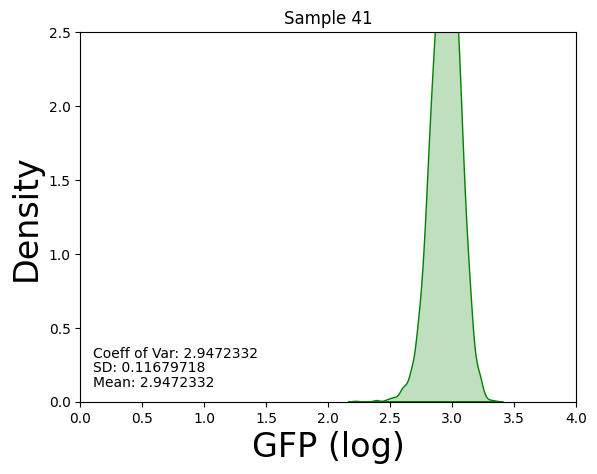

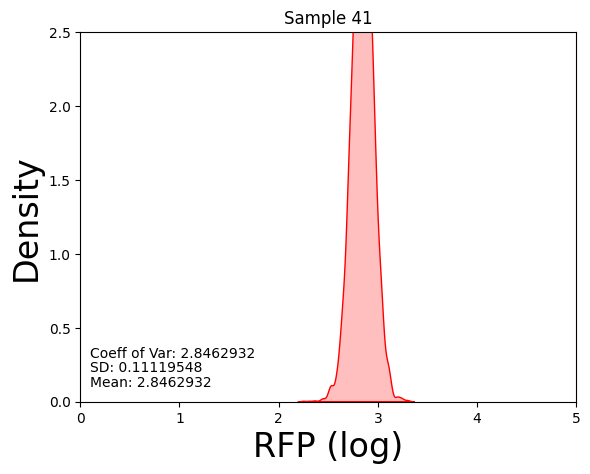

E06
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
E06: 0.01 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


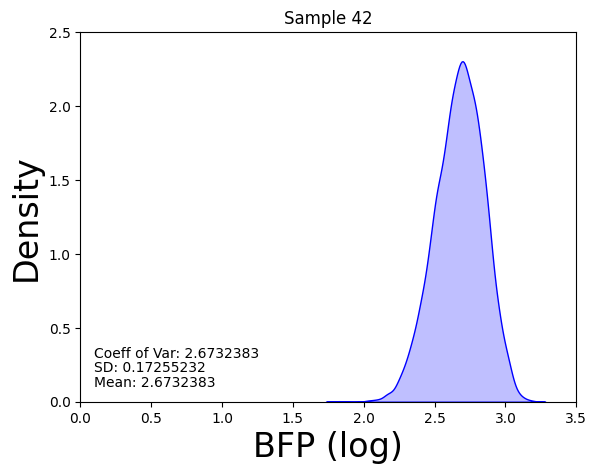

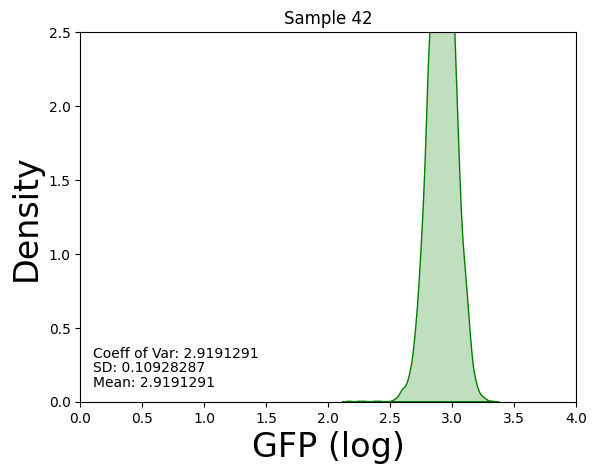

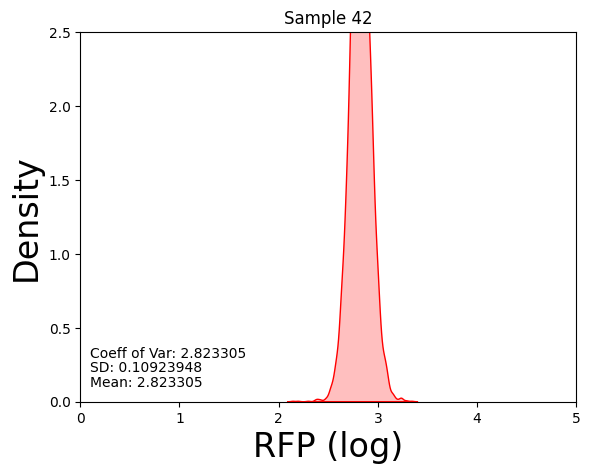

E07
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
E07: 0.00 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


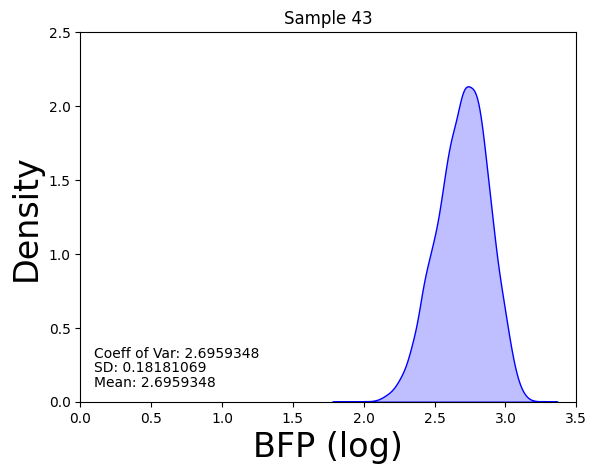

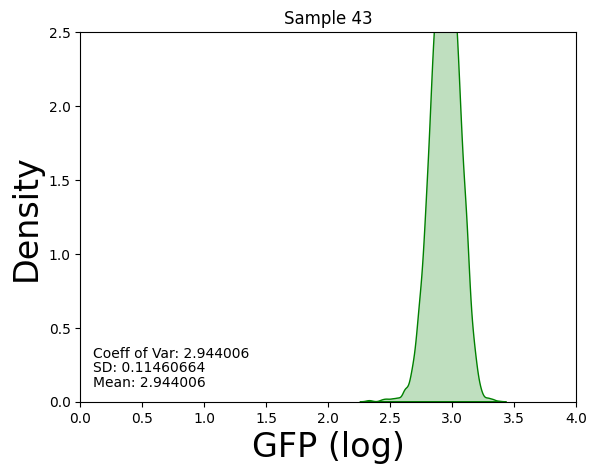

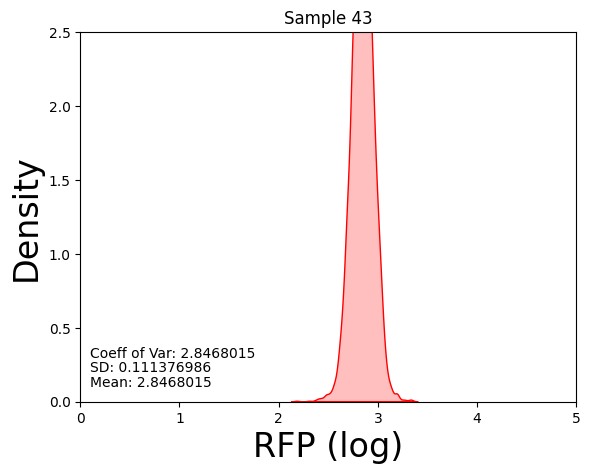

E08
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
E08: 0.01 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


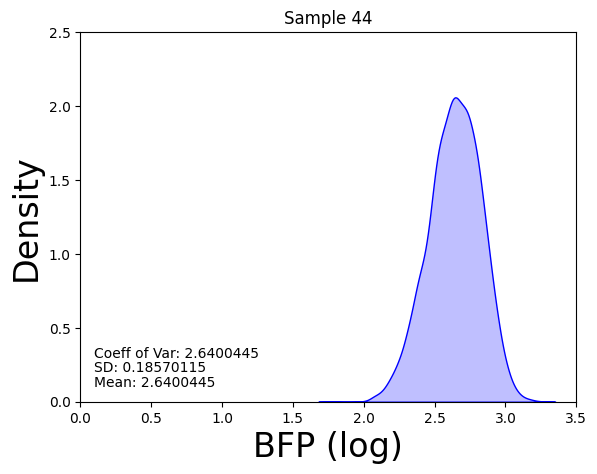

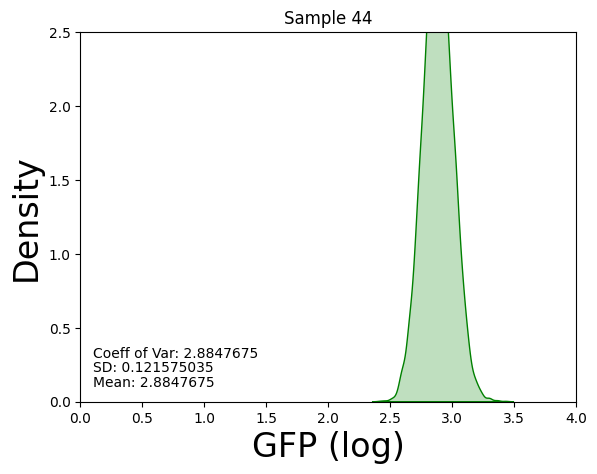

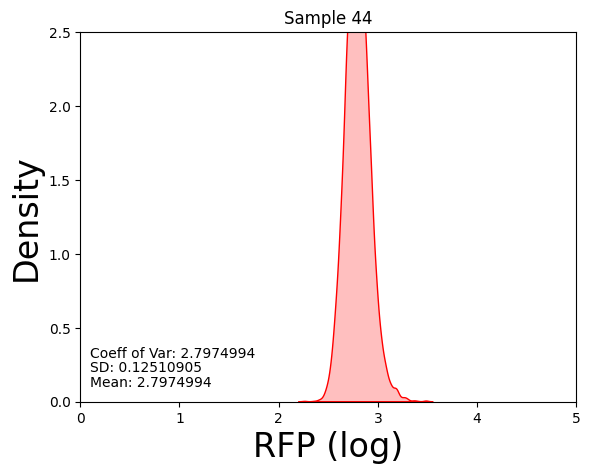

E09
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
E09: 0.01 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


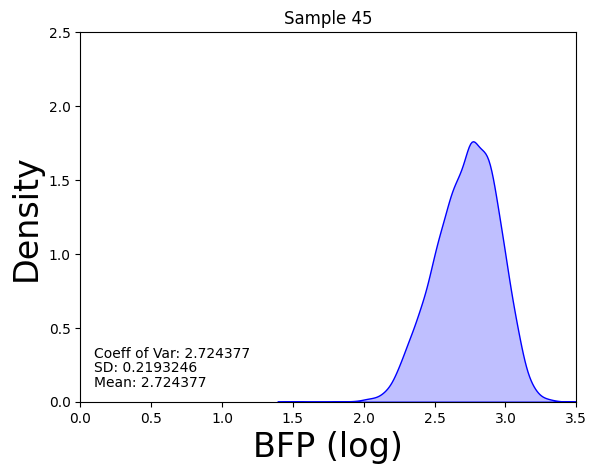

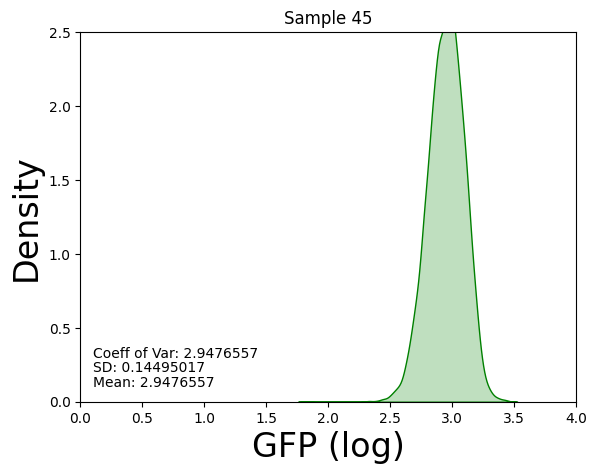

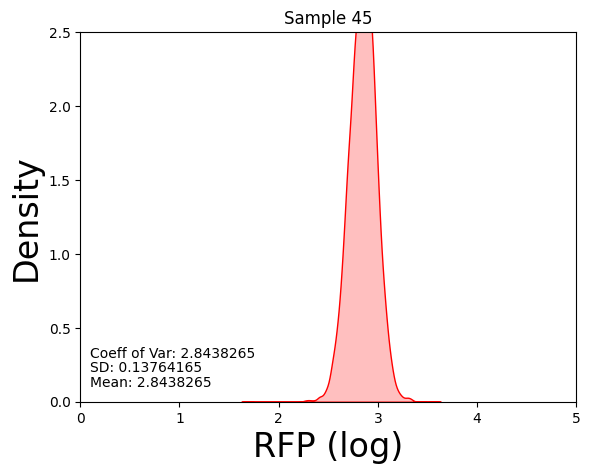

E10
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
E10: 0.01 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


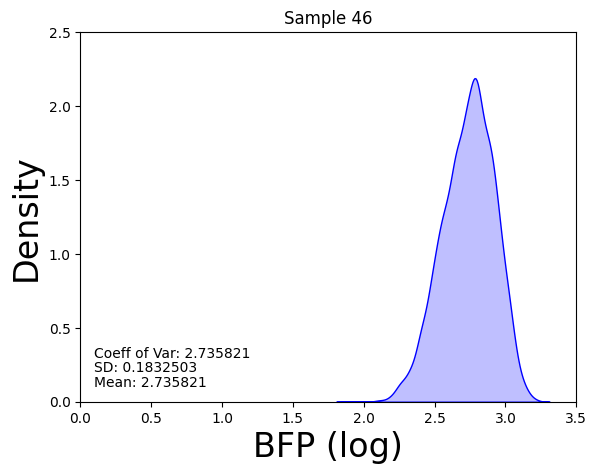

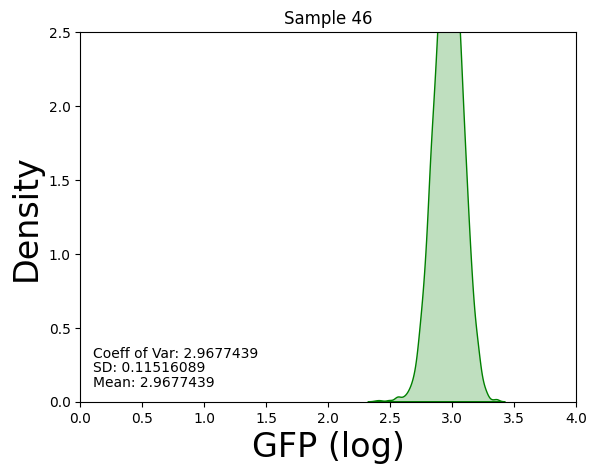

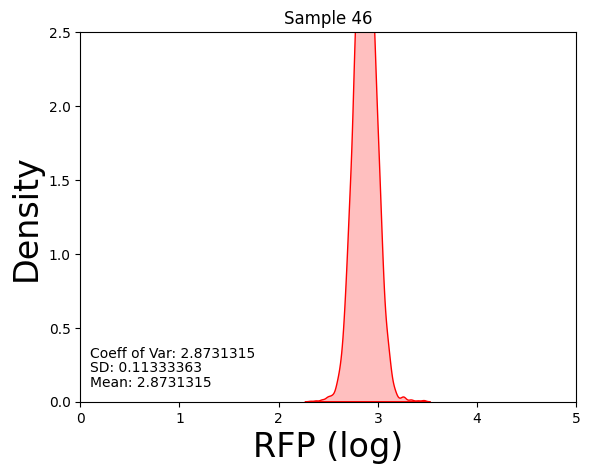

E11
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
E11: 0.00 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


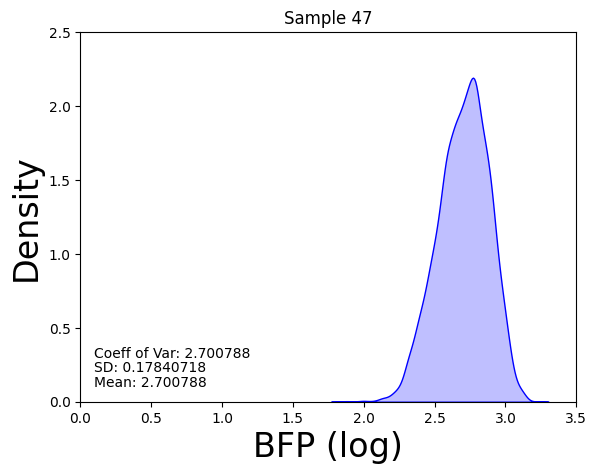

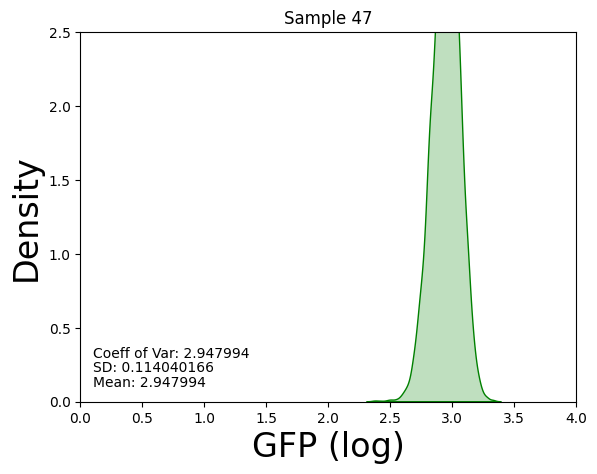

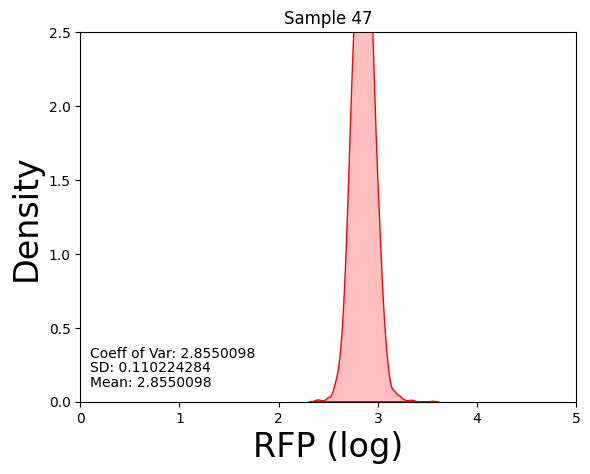

E12
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
E12: 0.01 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


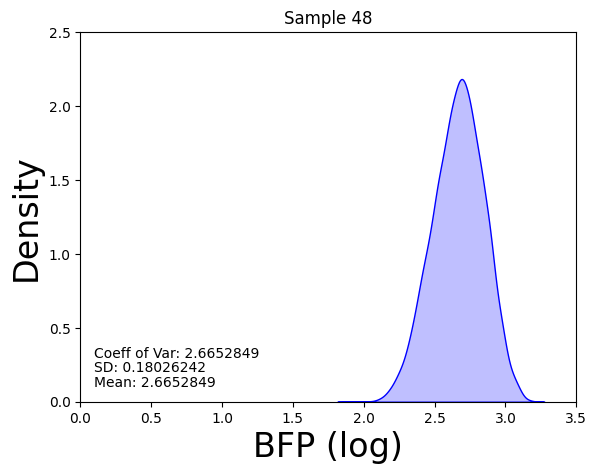

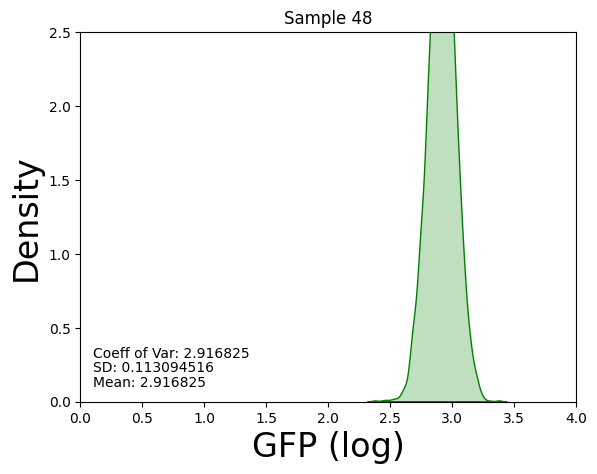

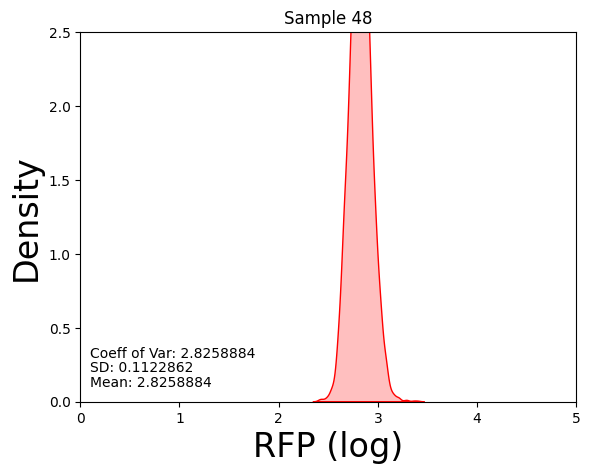

F01
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
F01: 0.01 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


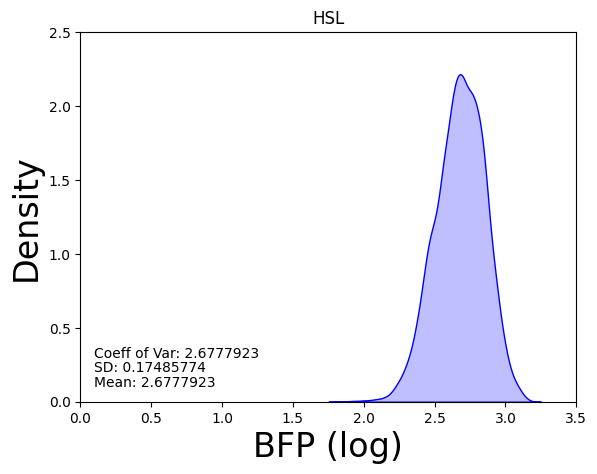

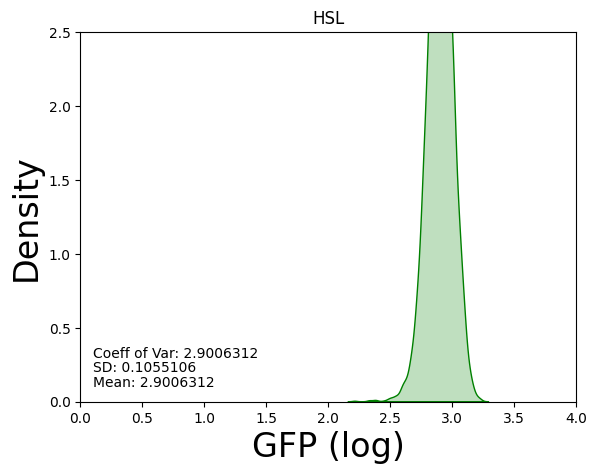

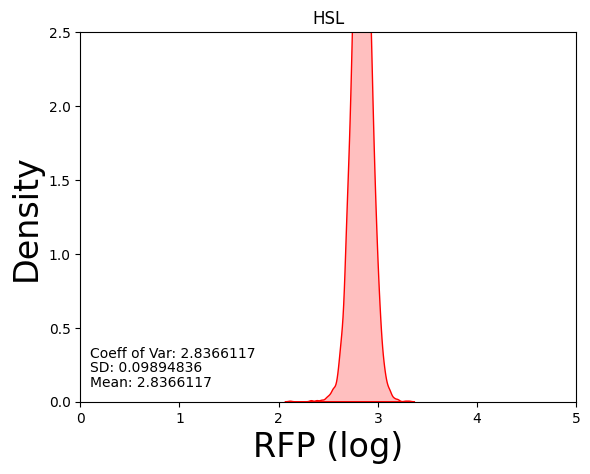

F02
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
F02: 0.01 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


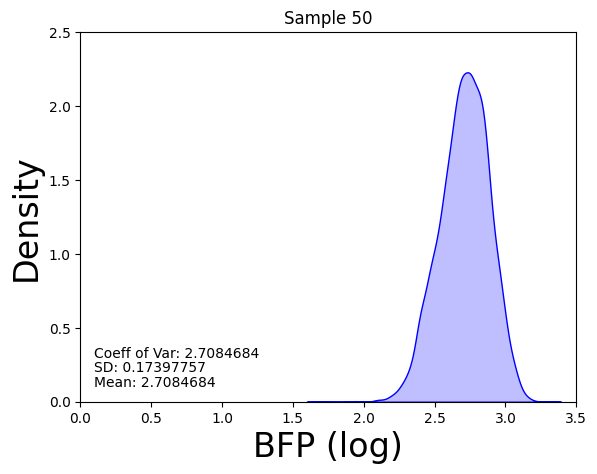

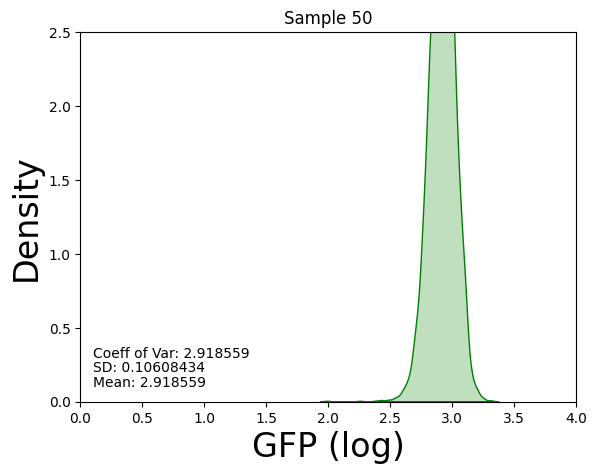

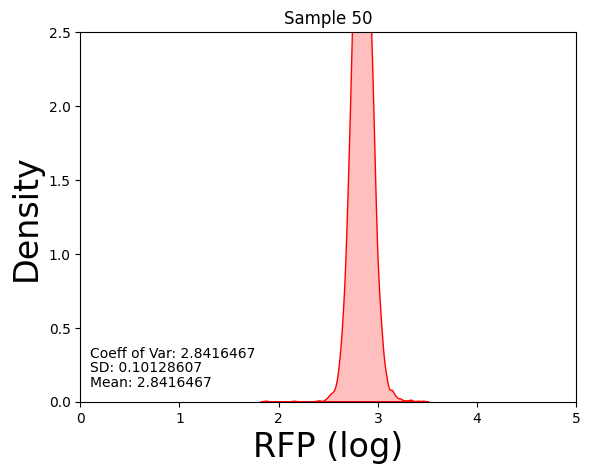

F03
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
F03: 0.00 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


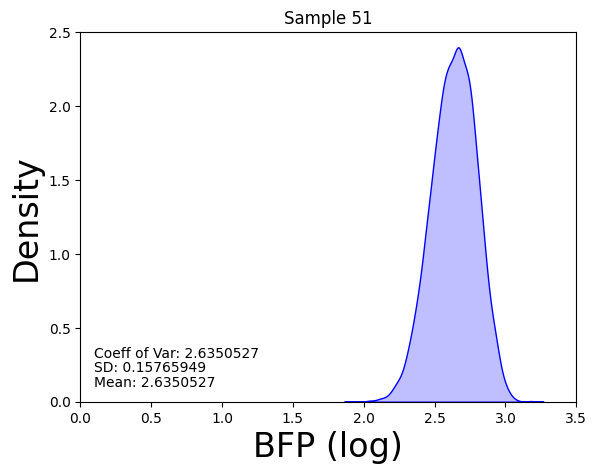

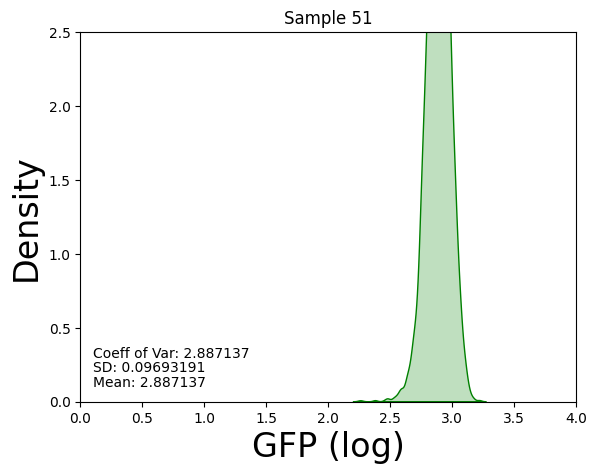

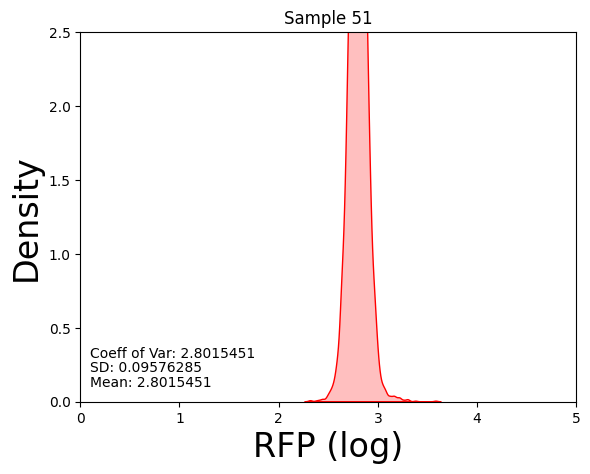

F04
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
F04: 0.00 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


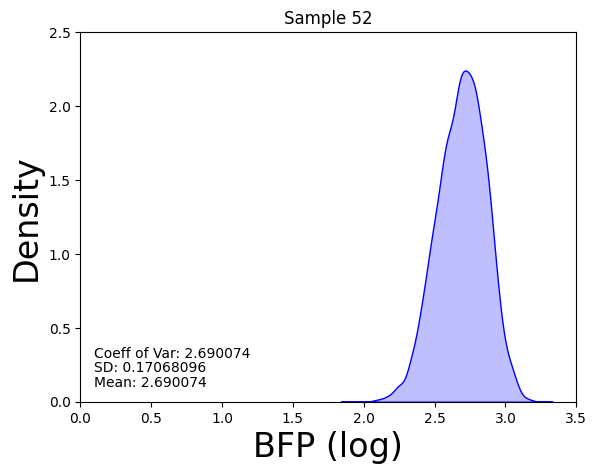

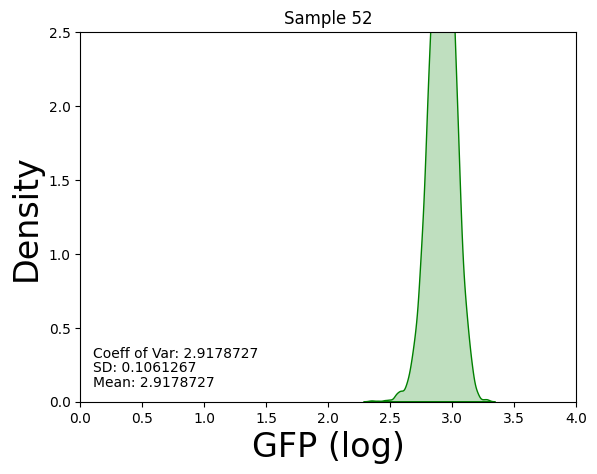

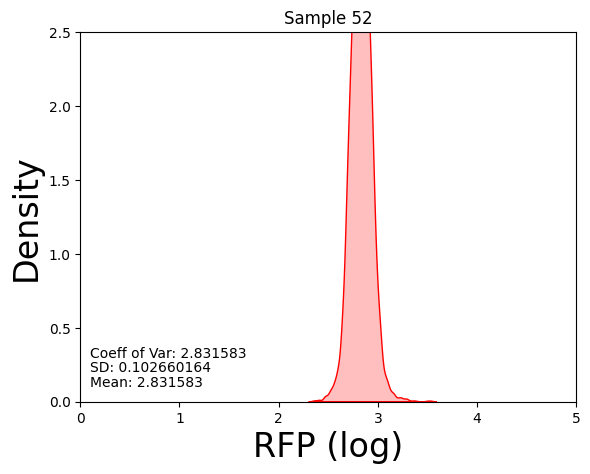

F05
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
F05: 0.01 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


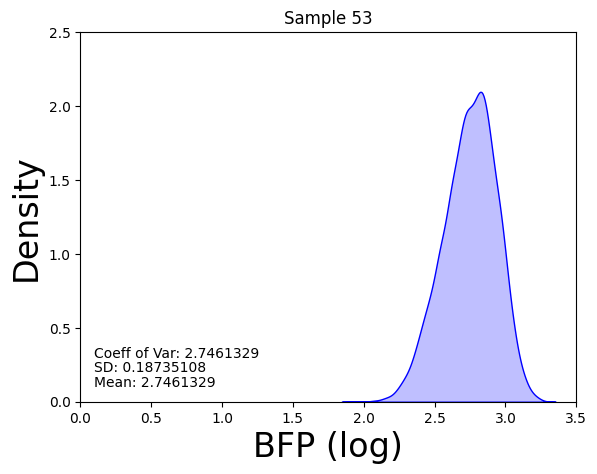

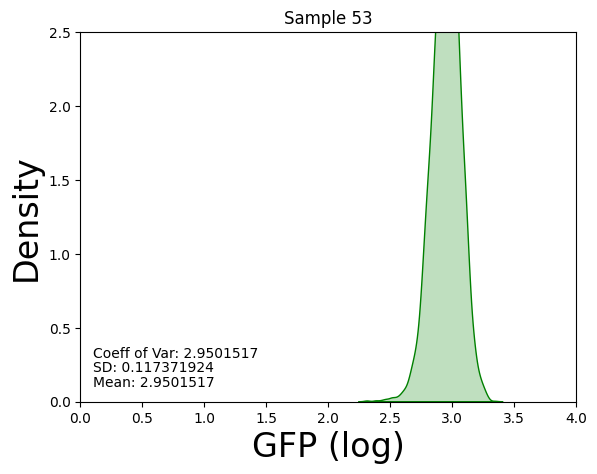

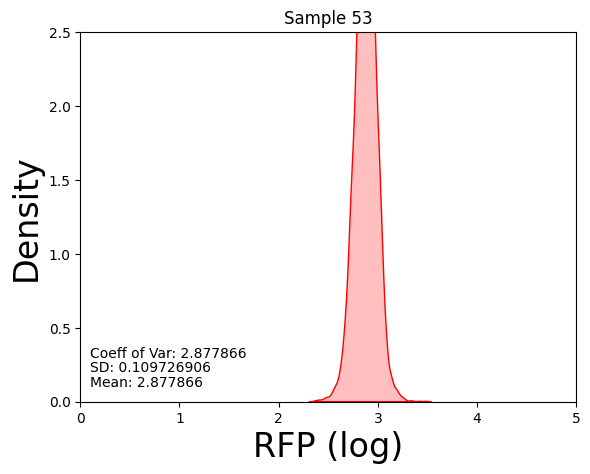

F06
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
F06: 0.02 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


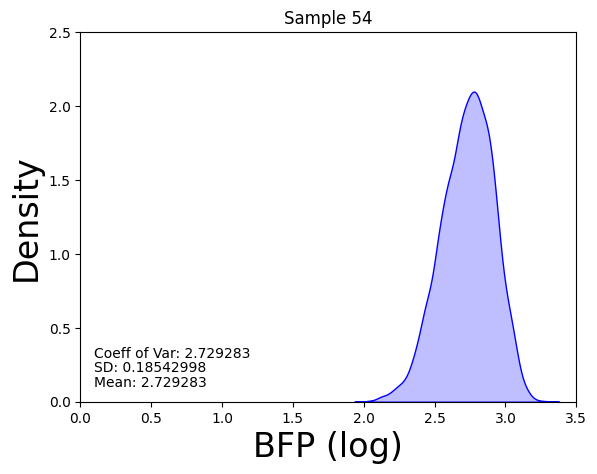

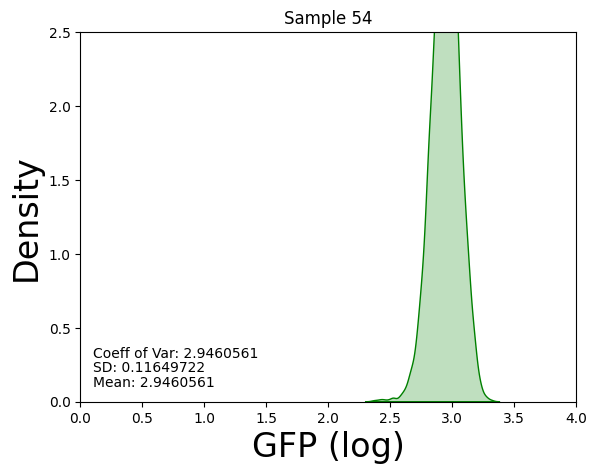

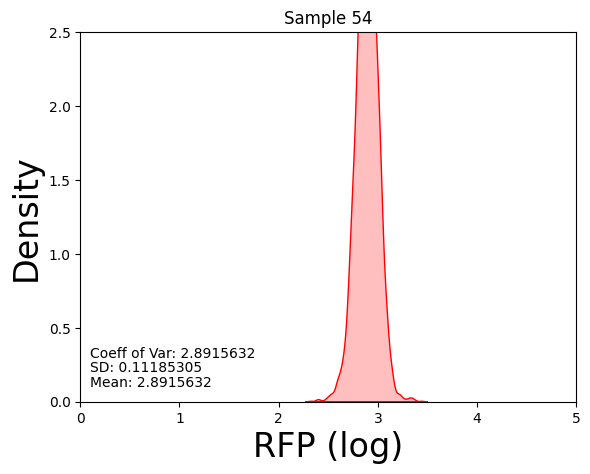

F07
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
F07: 0.02 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


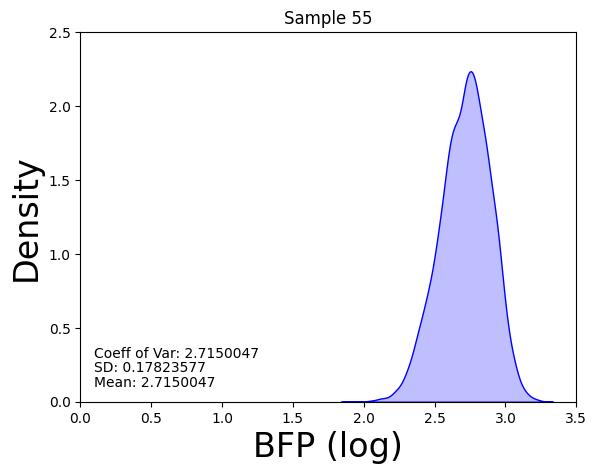

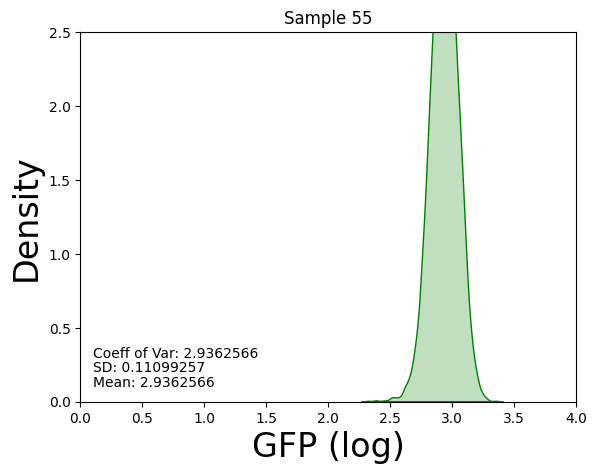

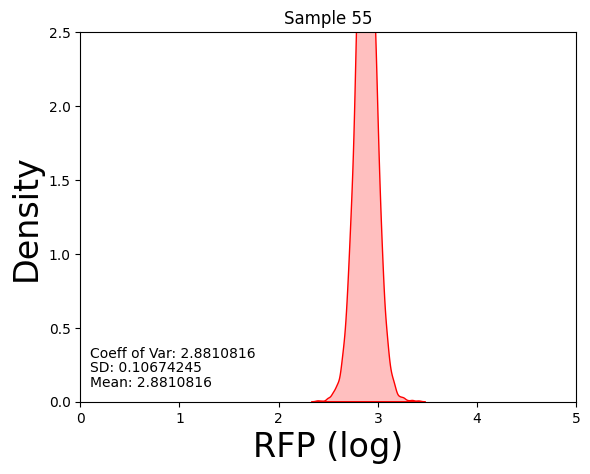

F08
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
F08: 0.01 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


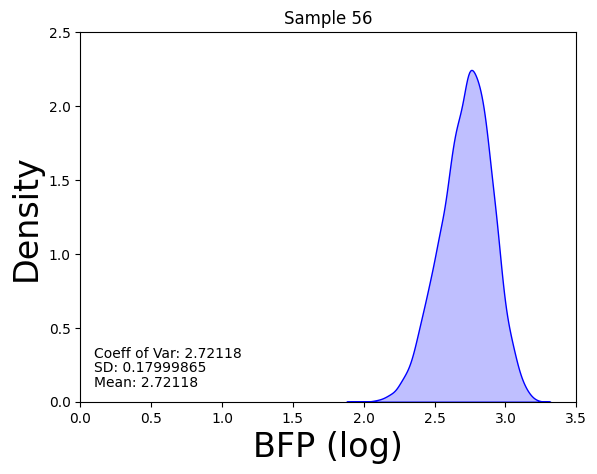

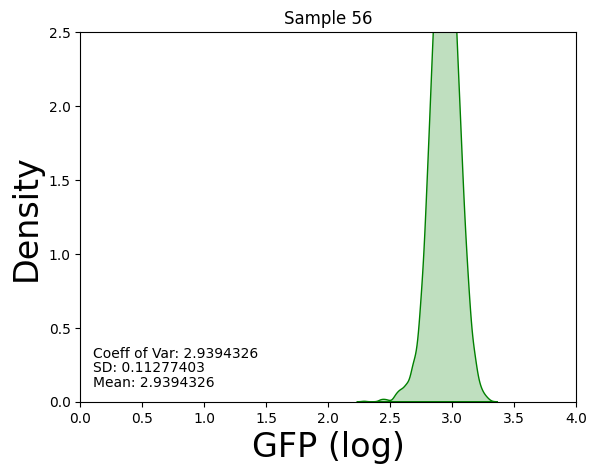

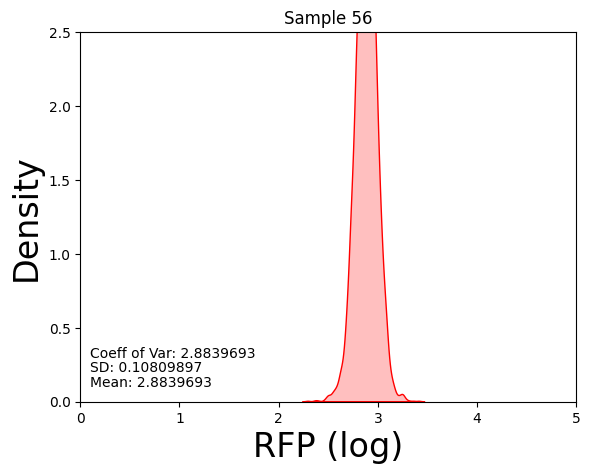

F09
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
F09: 0.01 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


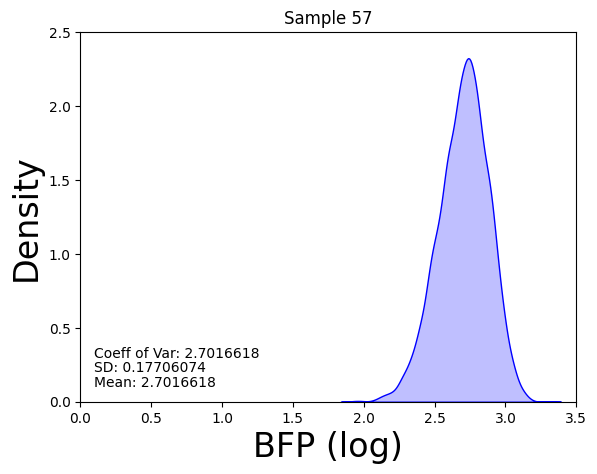

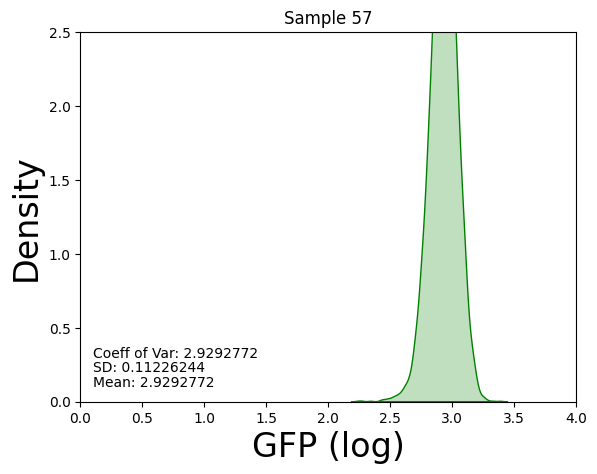

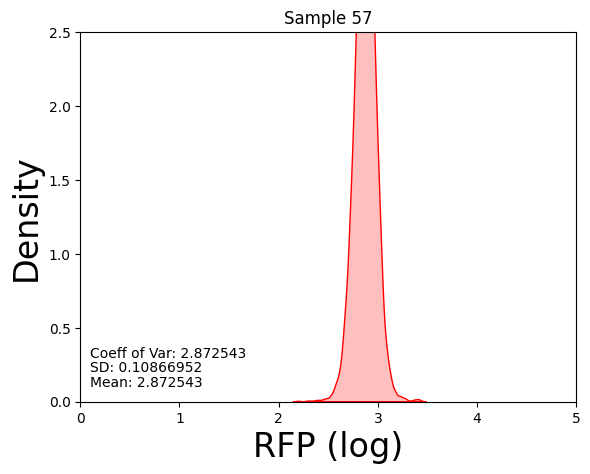

F10
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
F10: 0.01 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


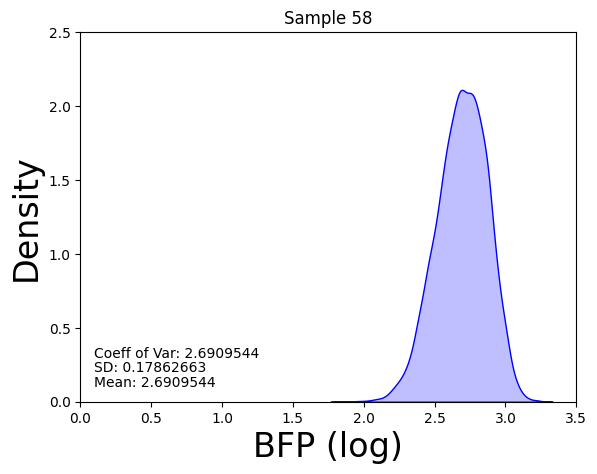

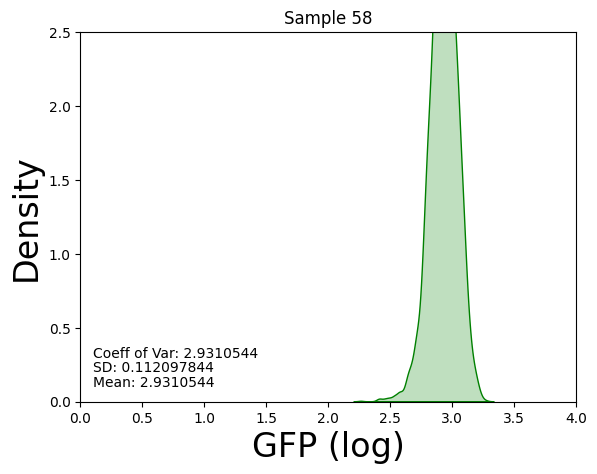

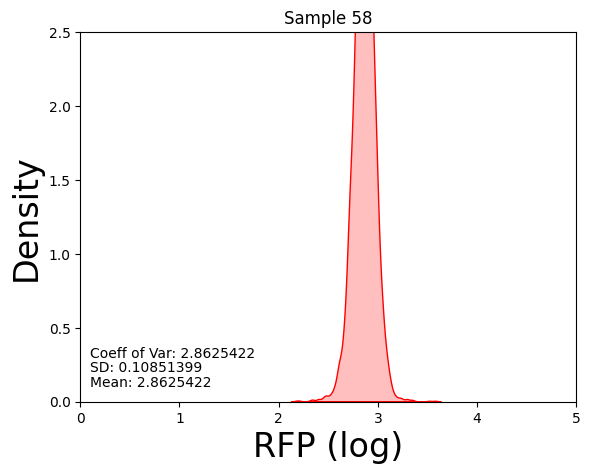

F11
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
F11: 0.02 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


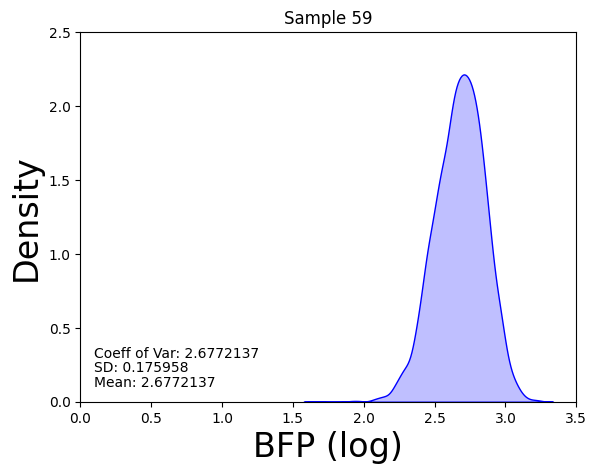

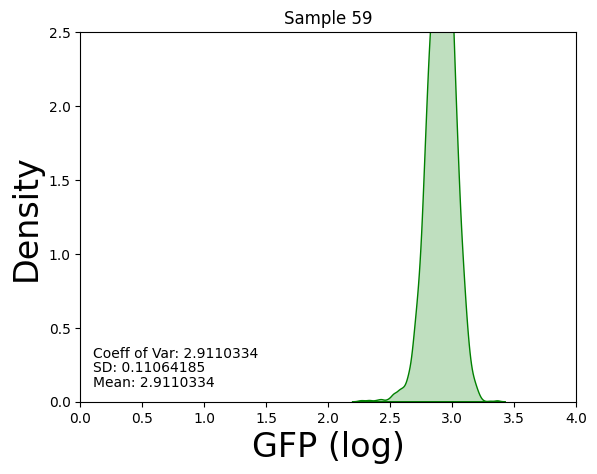

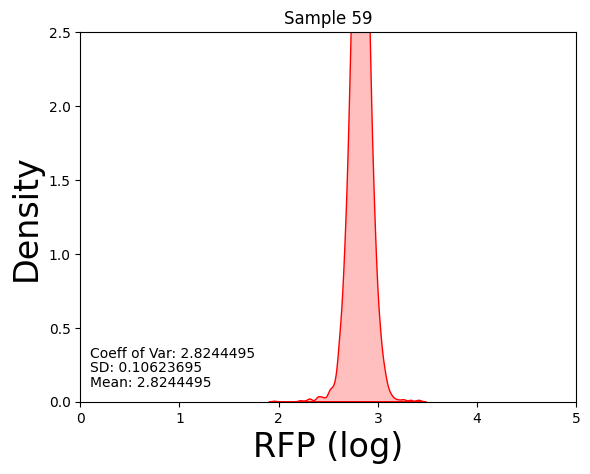

F12
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
F12: 0.01 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


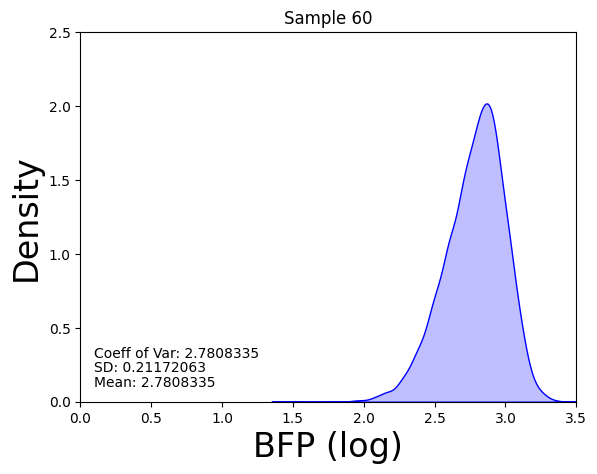

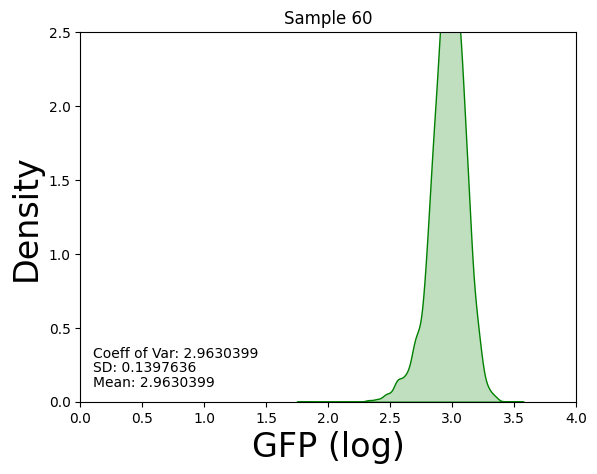

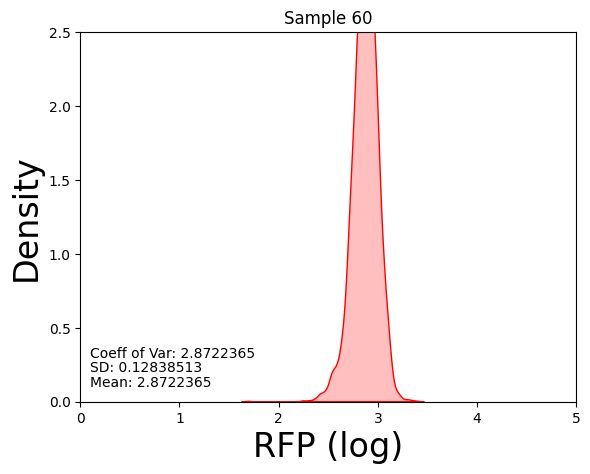

G01
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
G01: 0.01 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


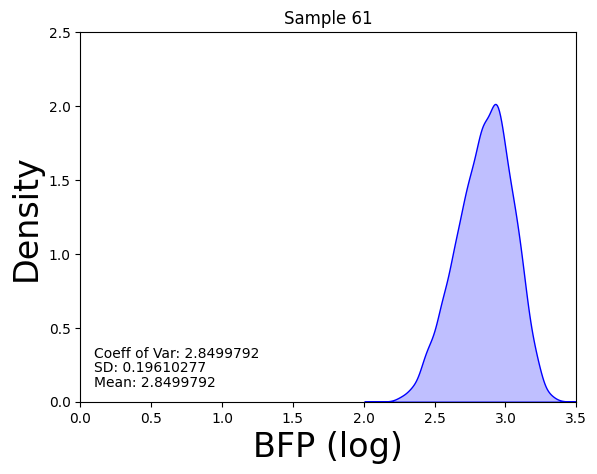

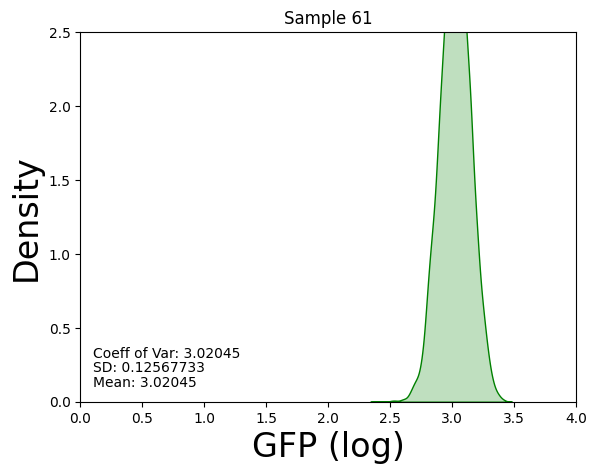

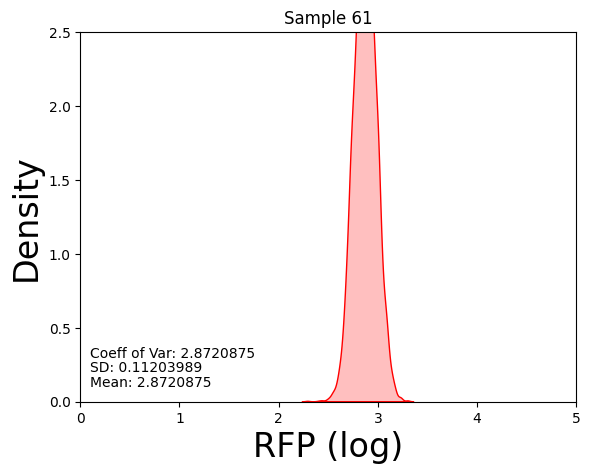

G02
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
G02: 0.03 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


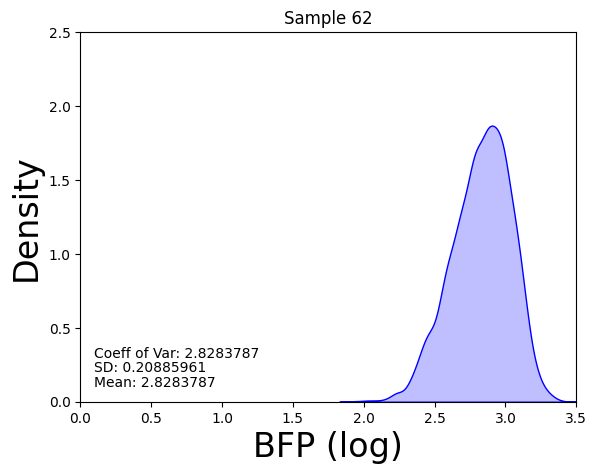

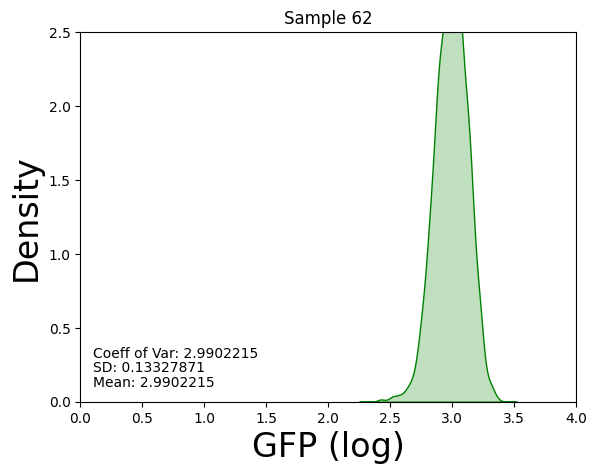

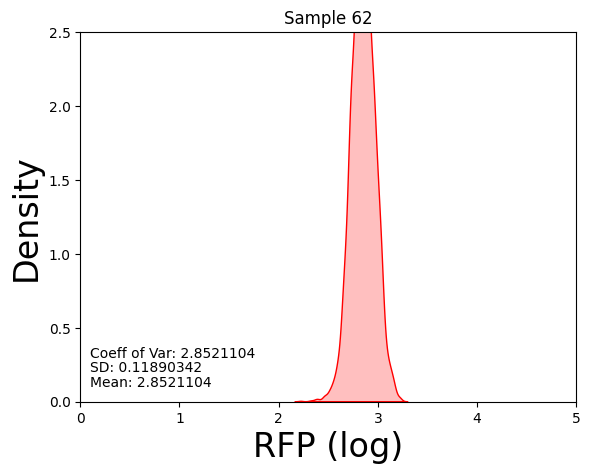

G03
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
G03: 0.03 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


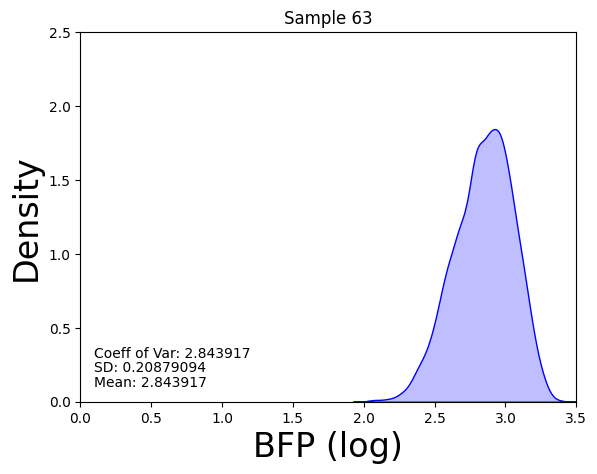

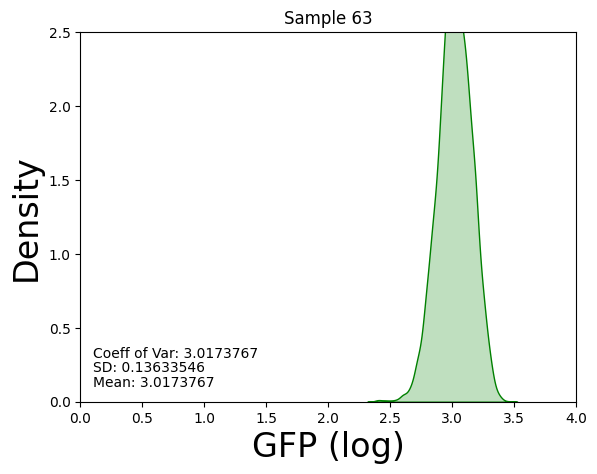

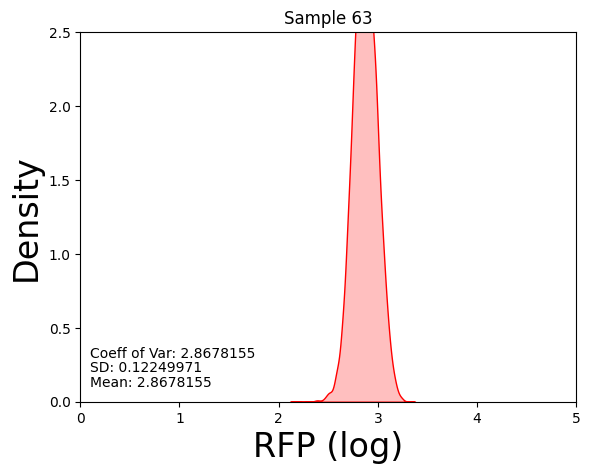

G04
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
G04: 0.02 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


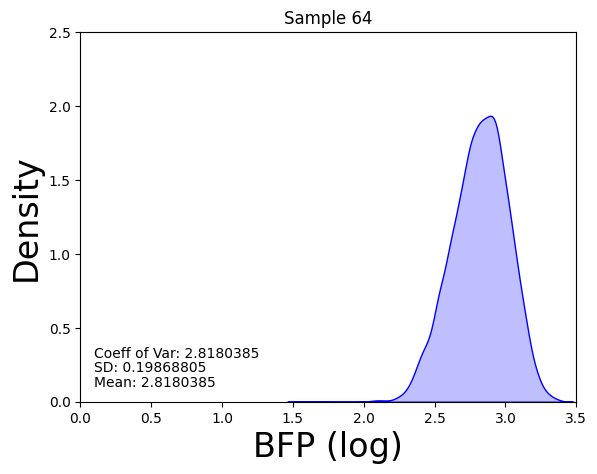

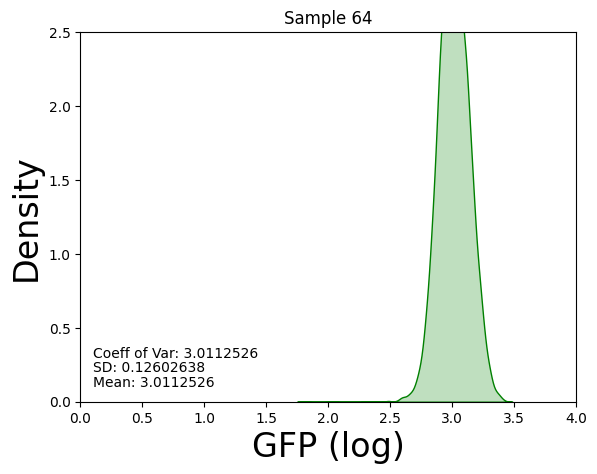

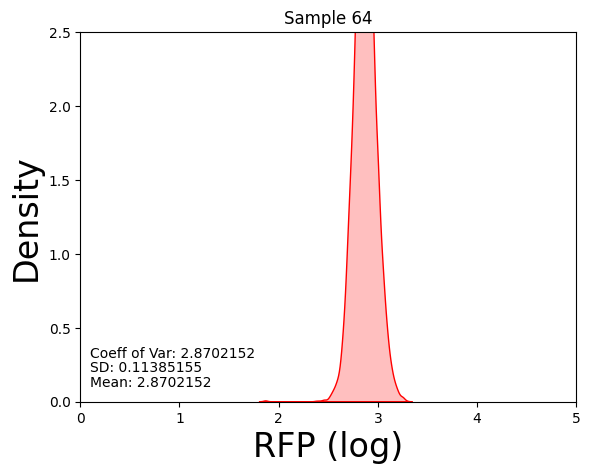

G05
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
G05: 0.03 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


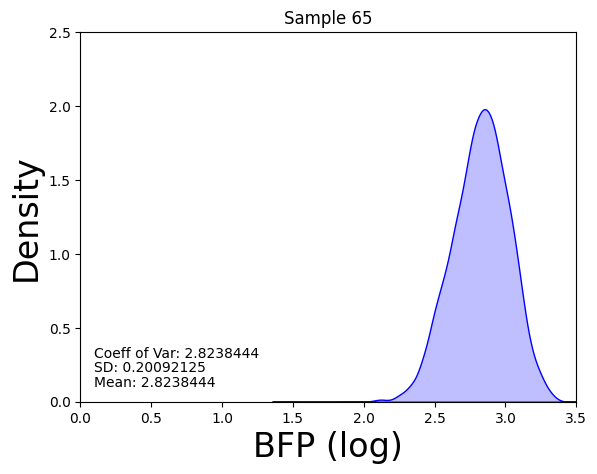

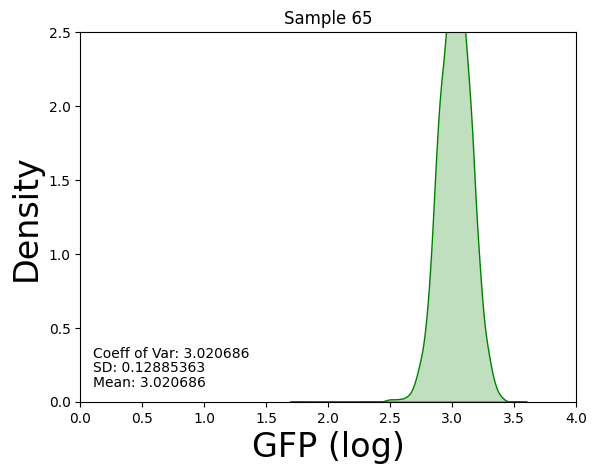

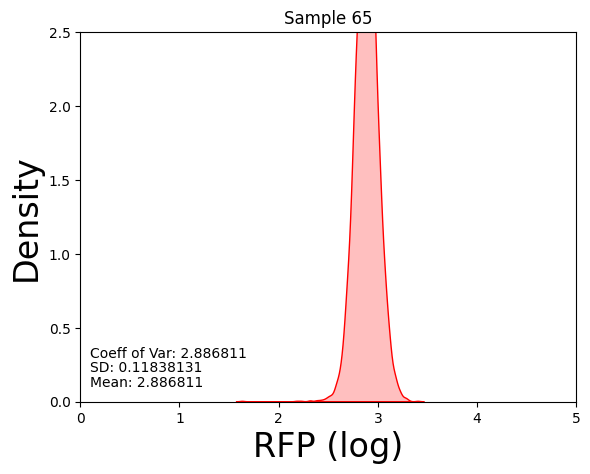

G06
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
G06: 0.03 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


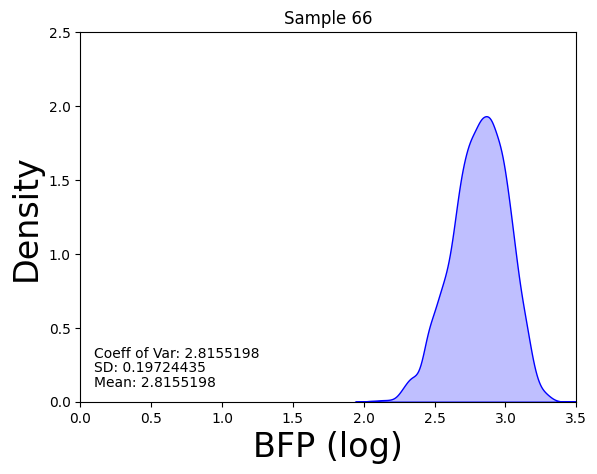

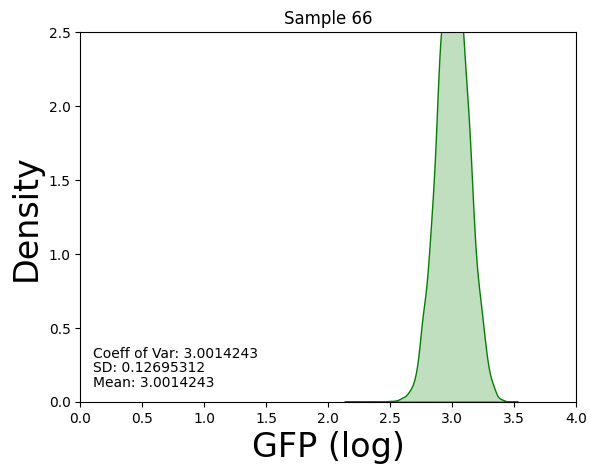

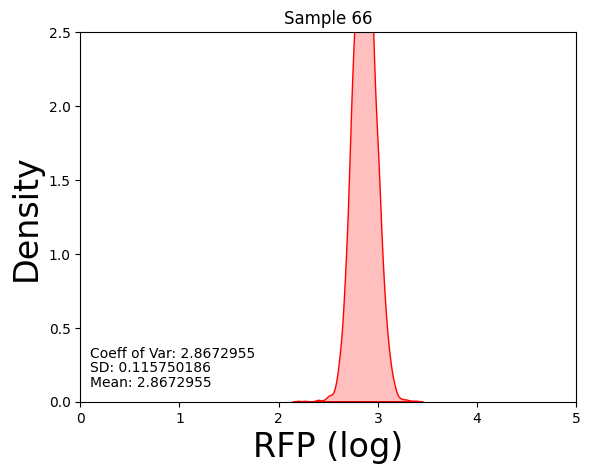

G07
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
G07: 0.03 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


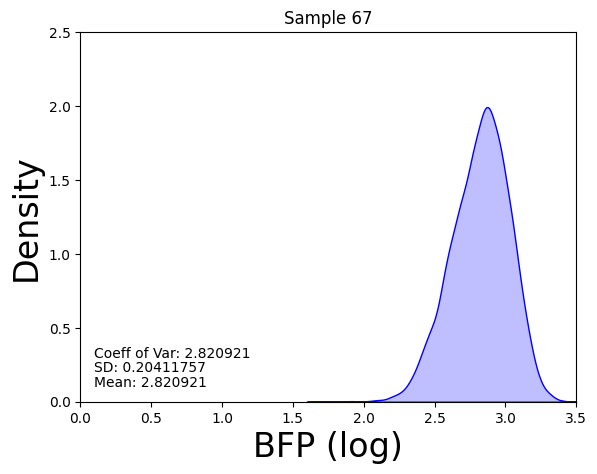

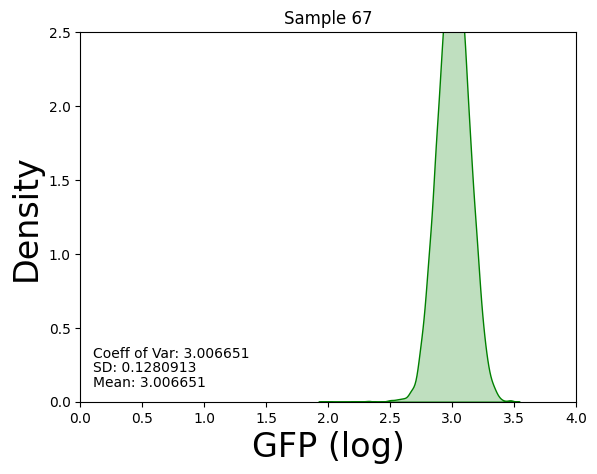

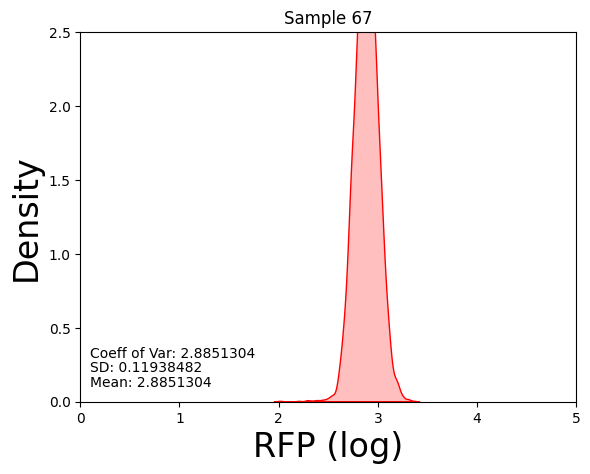

G08
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
G08: 0.04 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


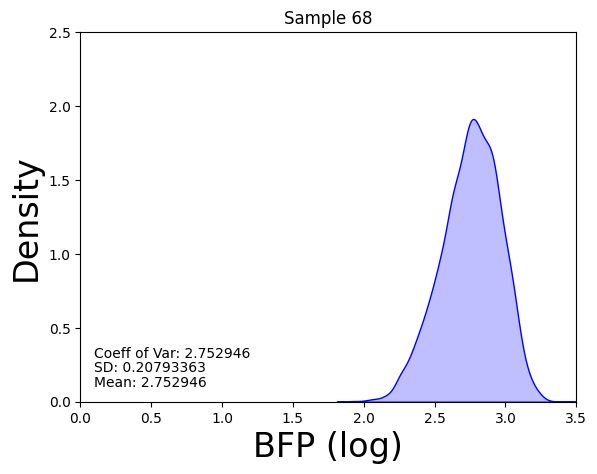

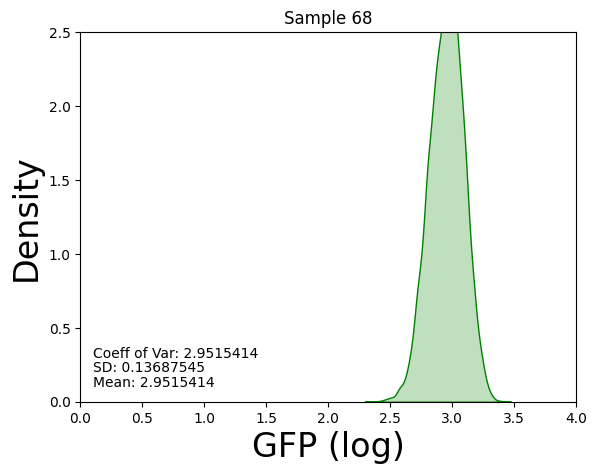

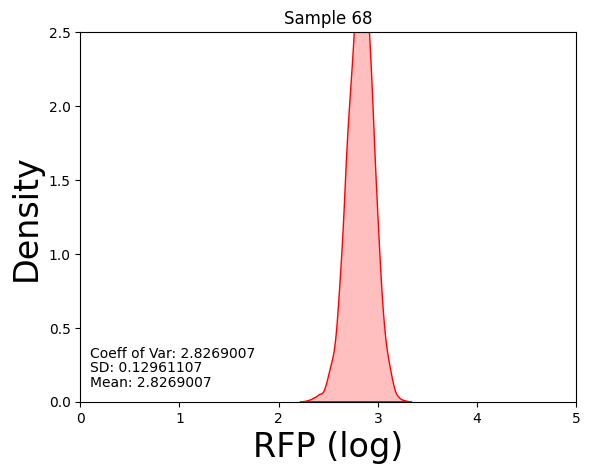

G09
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
G09: 0.06 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


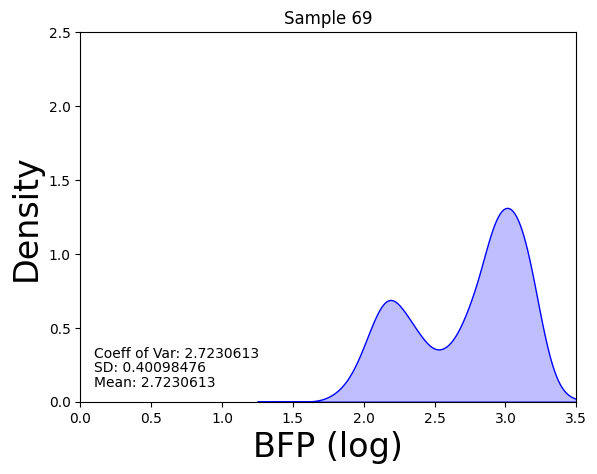

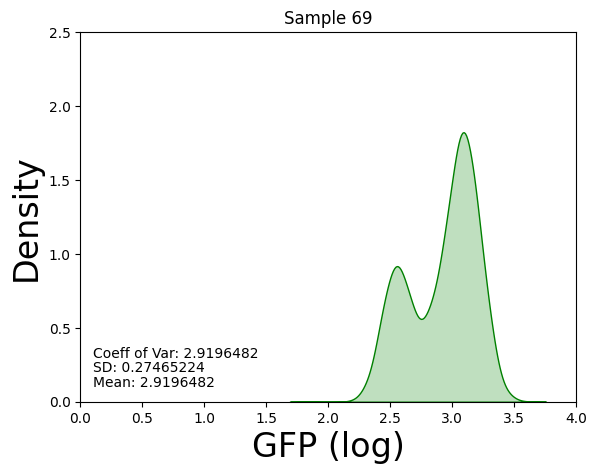

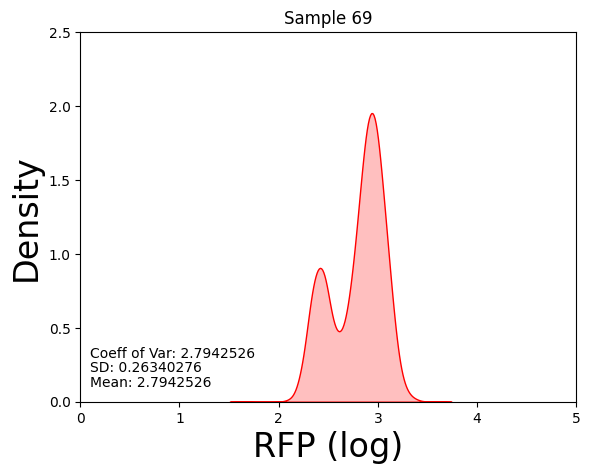

G10
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
G10: 0.02 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


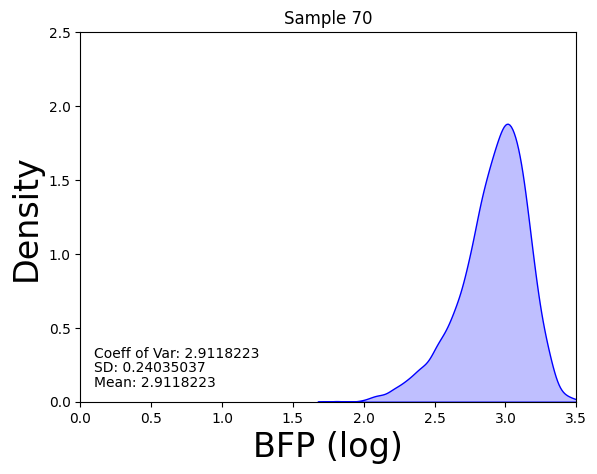

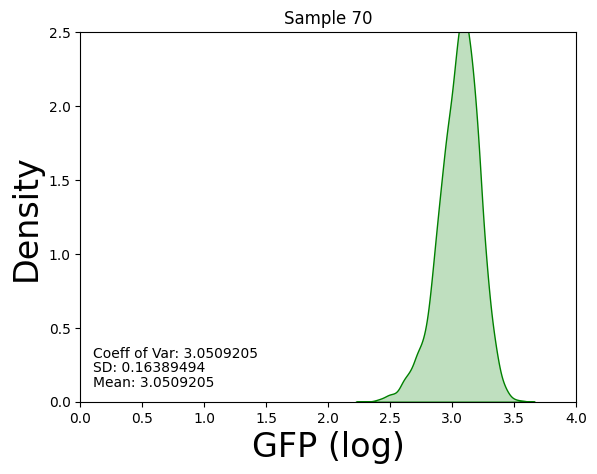

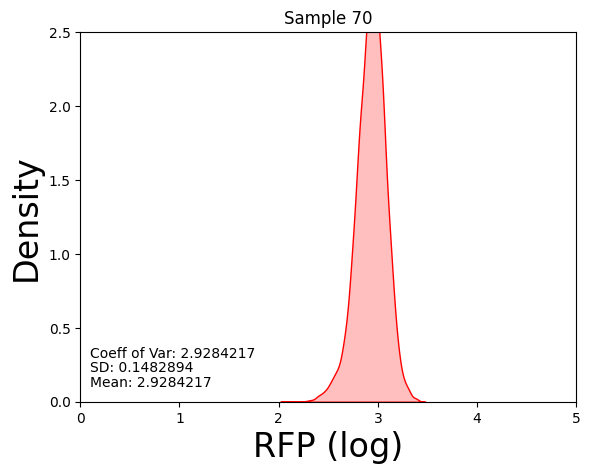

G11
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
G11: 0.00 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


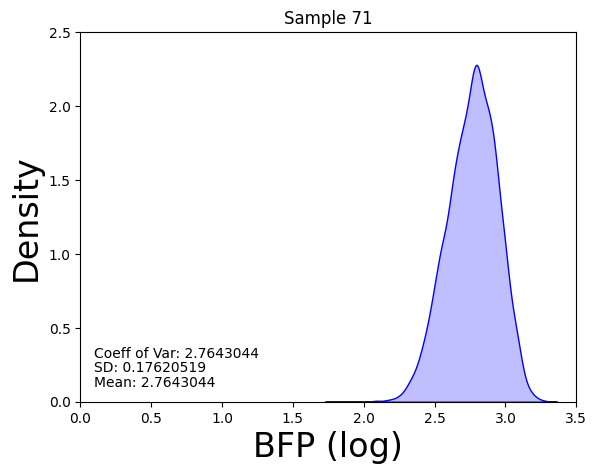

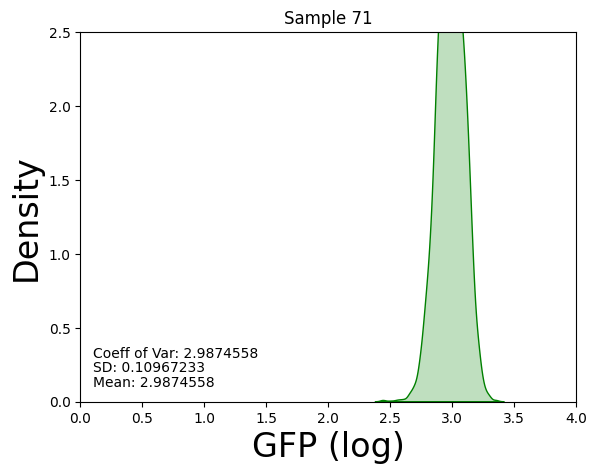

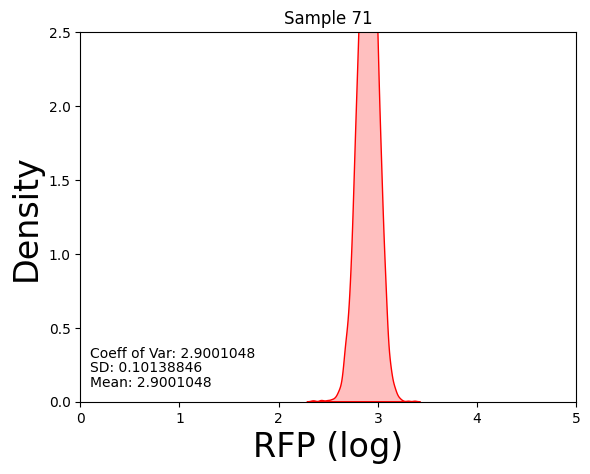

G12
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
G12: 0.00 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


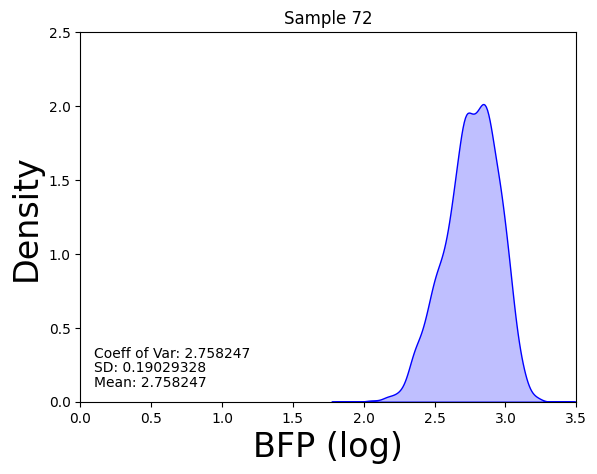

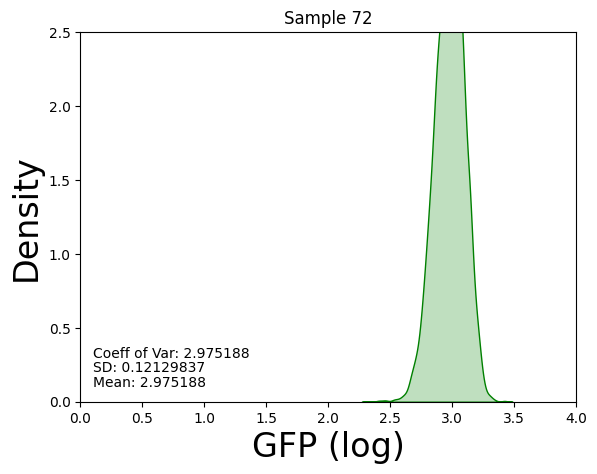

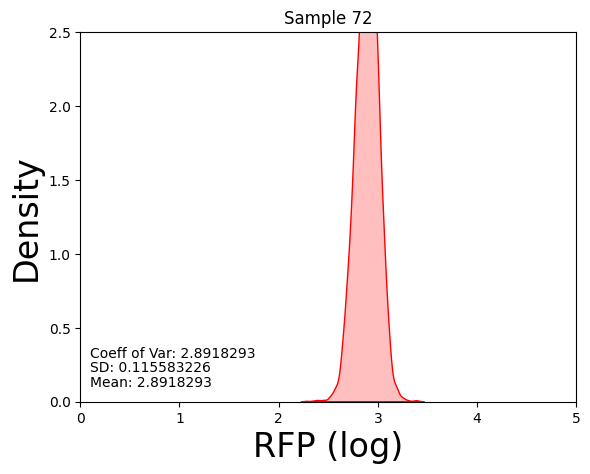

H11
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
H11: 0.00 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


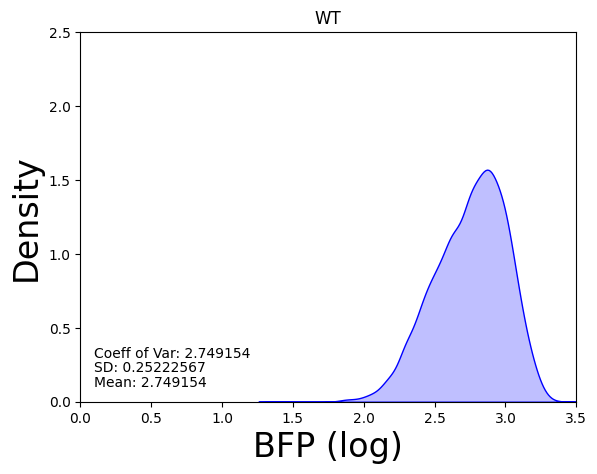

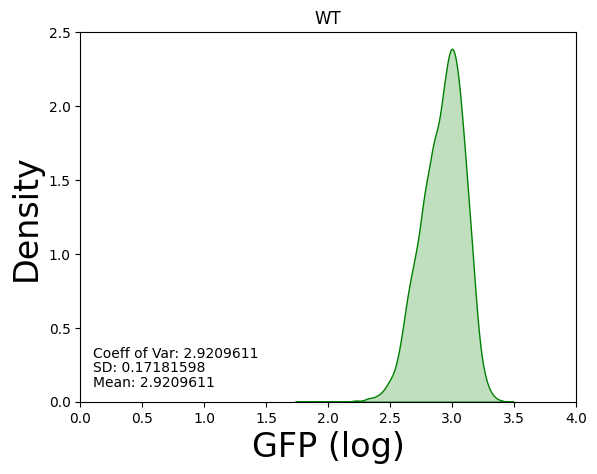

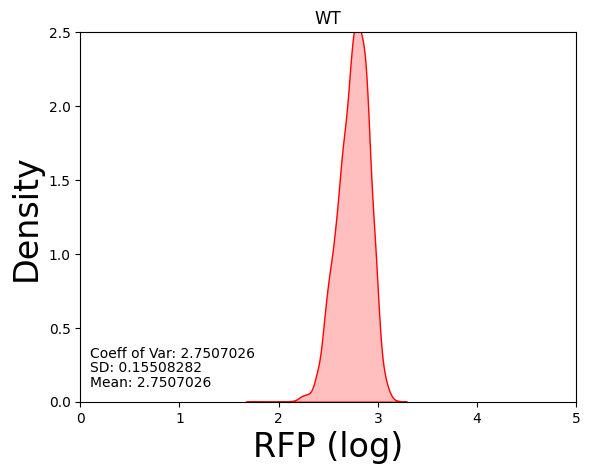

H12
['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', '405 - Area', '405 - Height', '405 - Width', 'GFP - Area', 'GFP - Height', 'GFP - Width', 'RFP-561 - Area', 'RFP-561 - Height', 'RFP-561 - Width', 'Time Stamp']
H12: 0.02 fraction of samples lost to size filtering and gating.


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


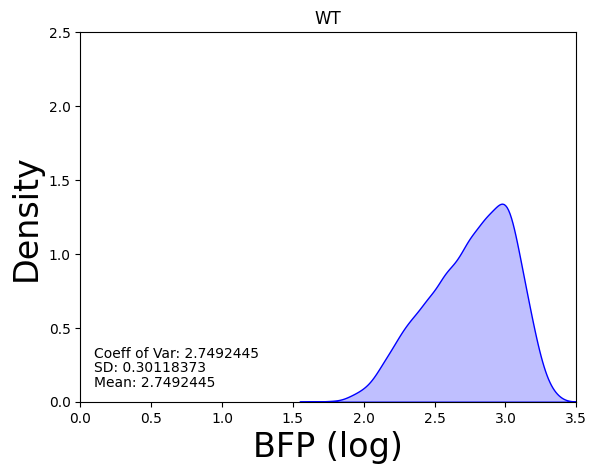

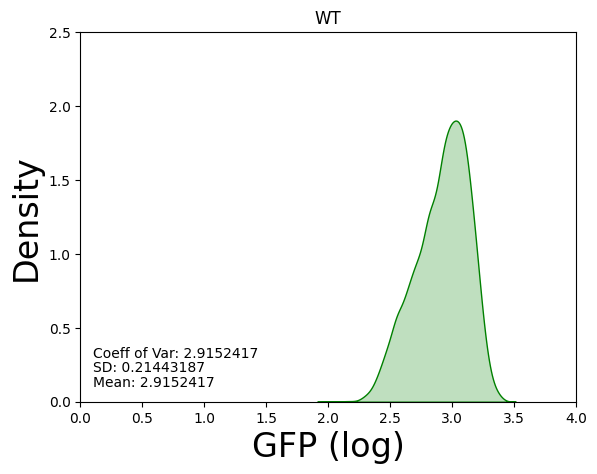

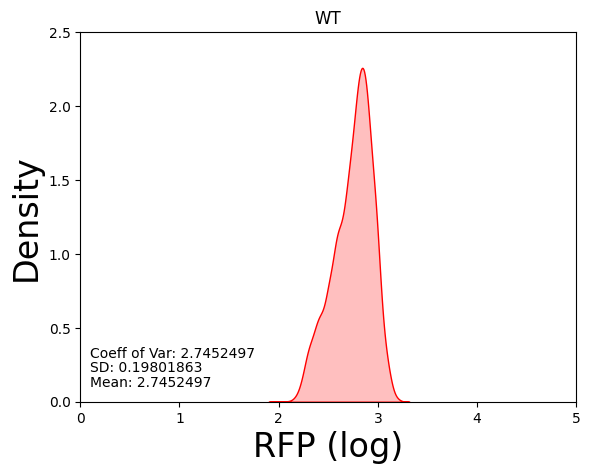

In [99]:
import os
#os.listdir()
#!pwd

Dirpath = '/Users/Kevin Chang/Downloads/Sample Group - 1/Sample Group - 1'

All_Files = os.listdir(Dirpath)


for ThisFile in All_Files[0:]:
    if '.fcs' in ThisFile:

        #try:
            pltHex(Dirpath+'/'+ThisFile)
        #except:
        #    print(Dirpath+'/'+ThisFile)


c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = 

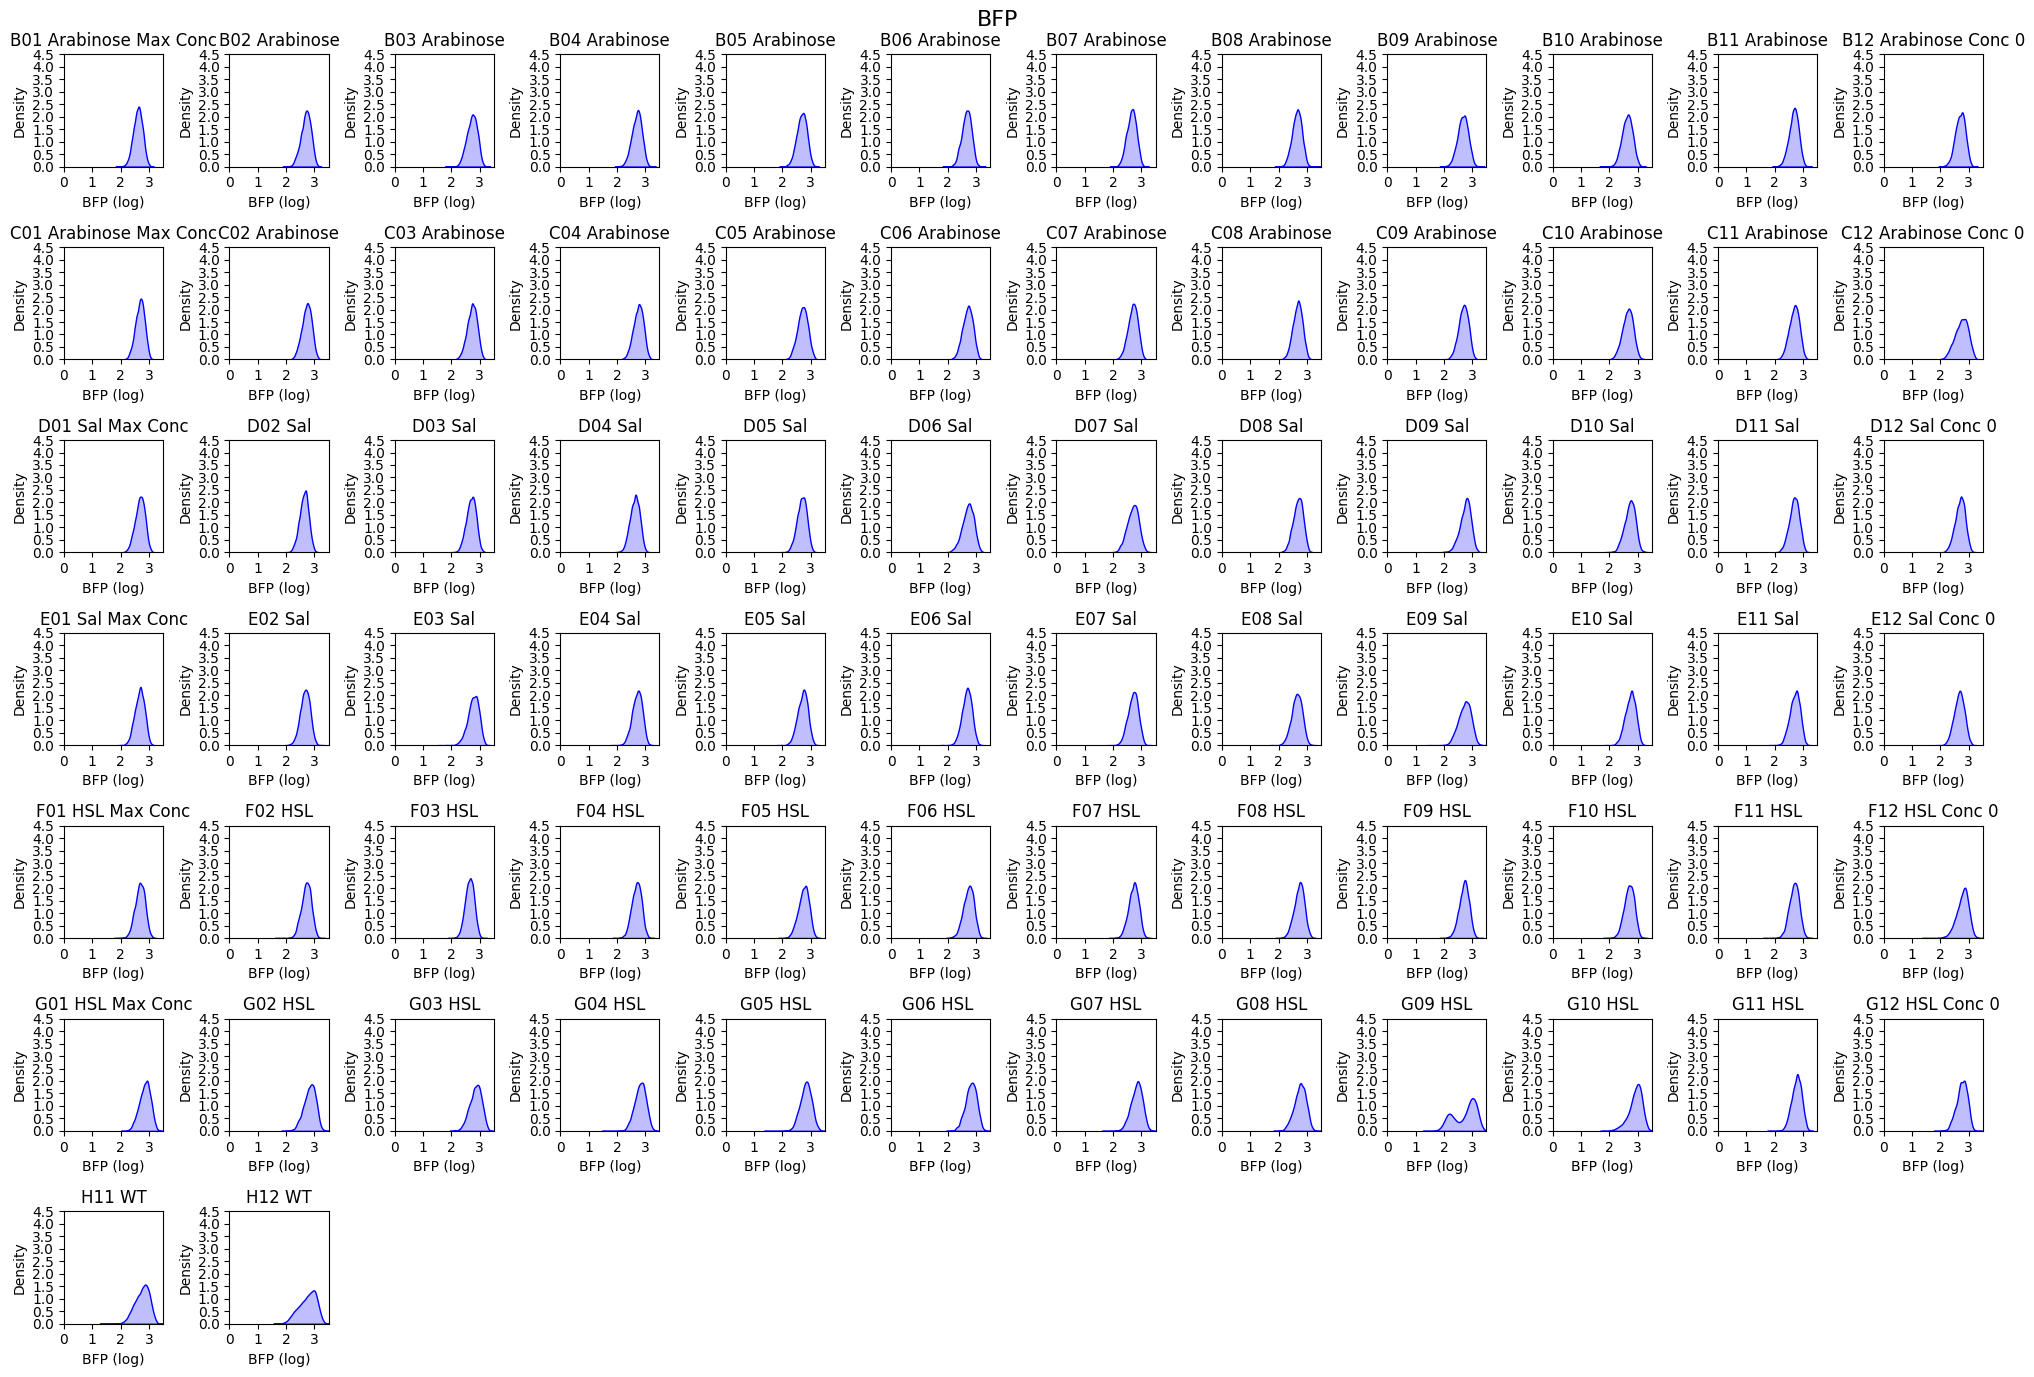

c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = 

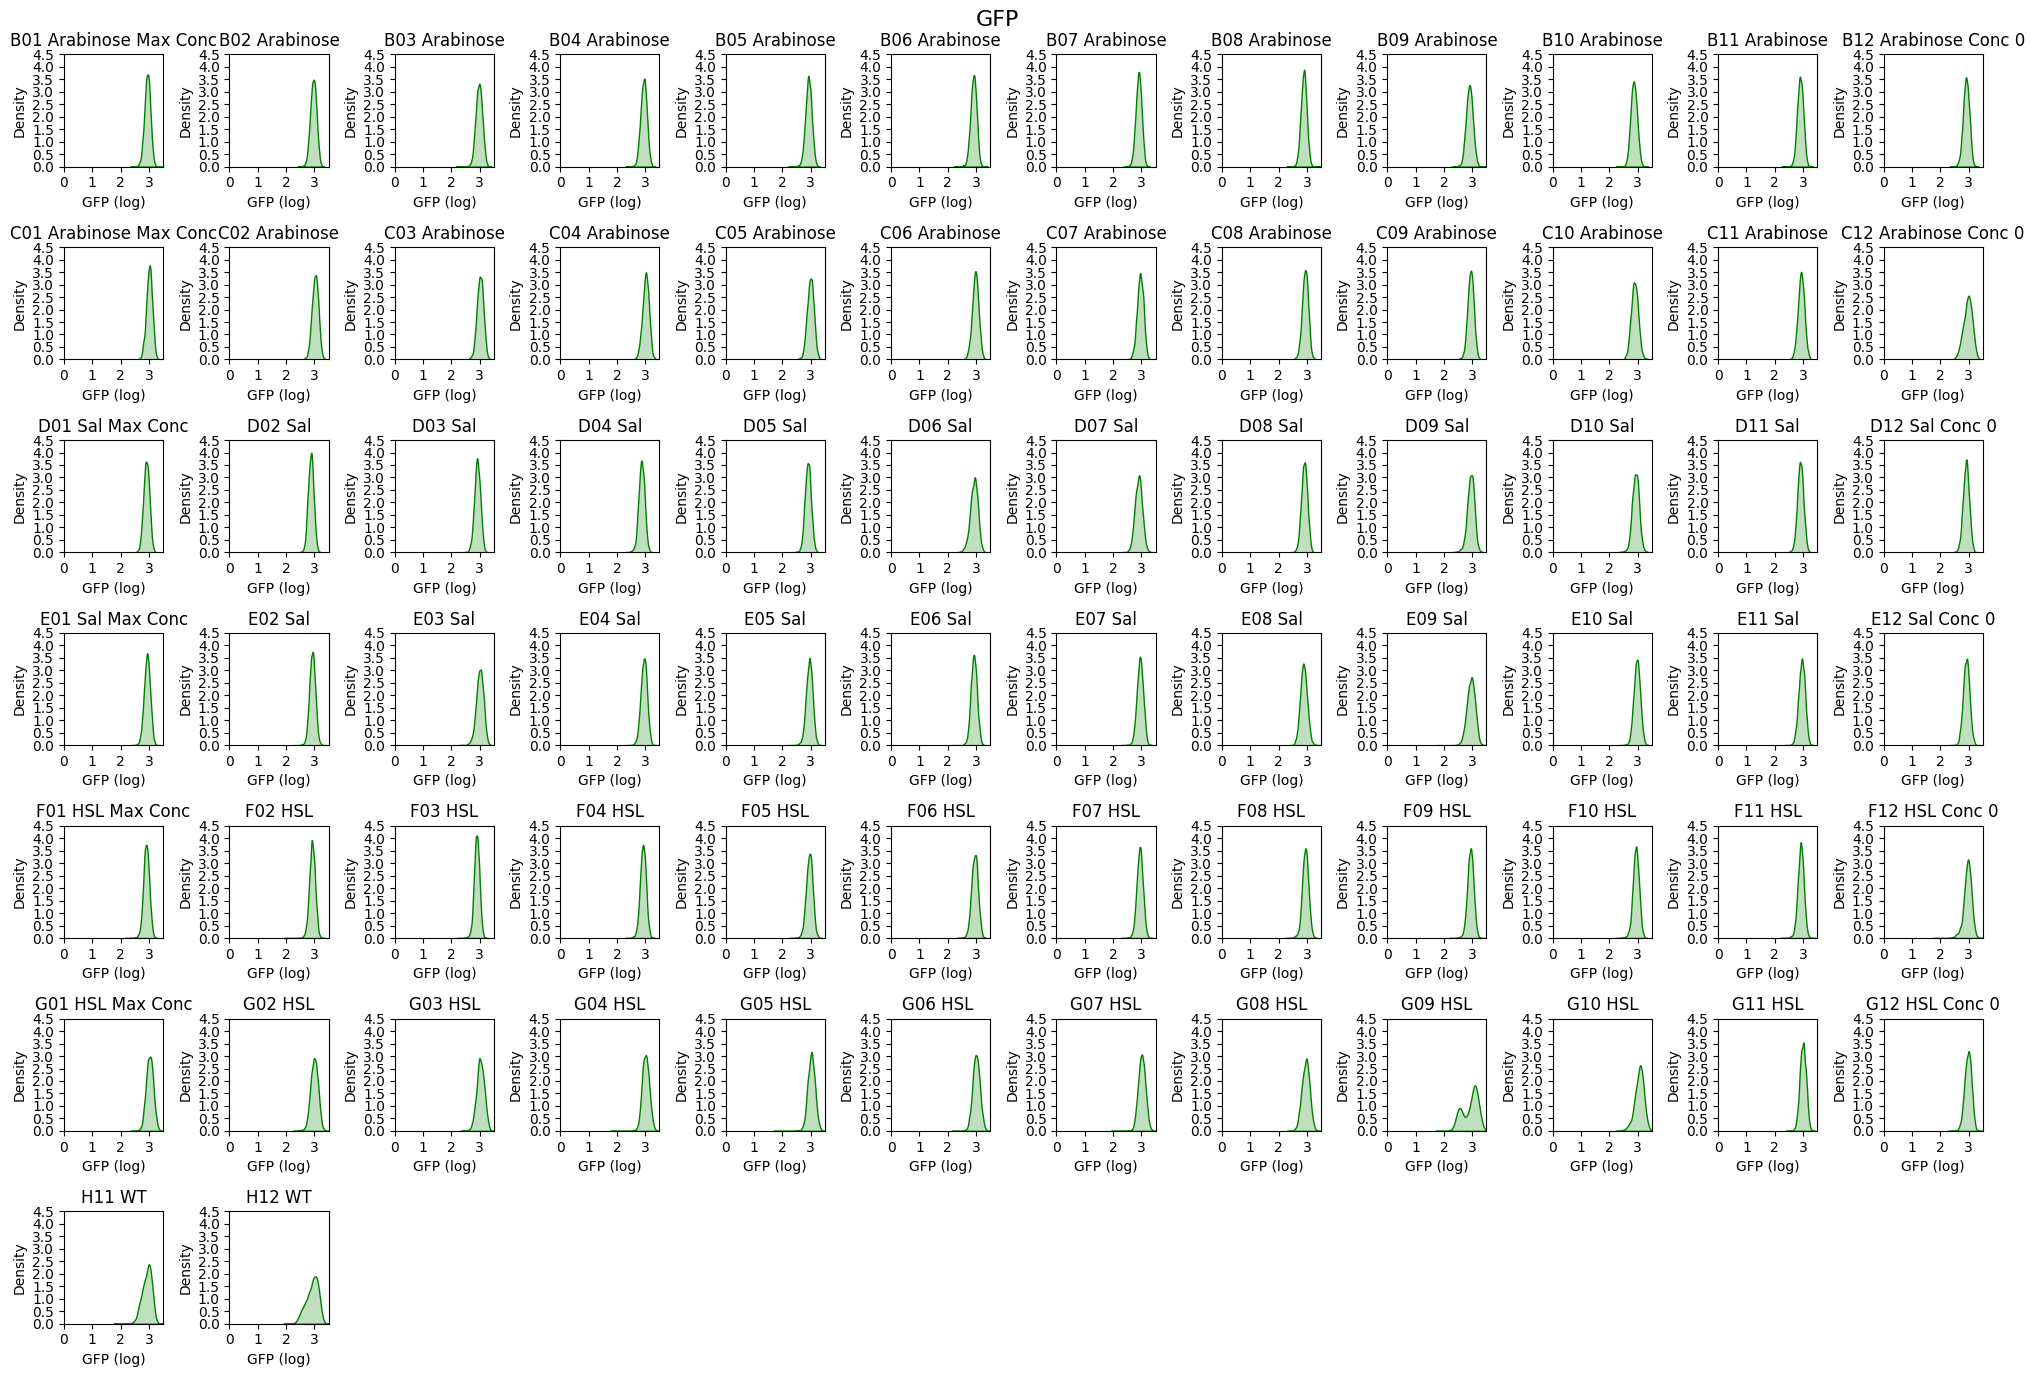

c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)
c:\Users\Kevin Chang\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\internals\blocks.py:366: RuntimeWarning: divide by zero encountered in log10
  result = 

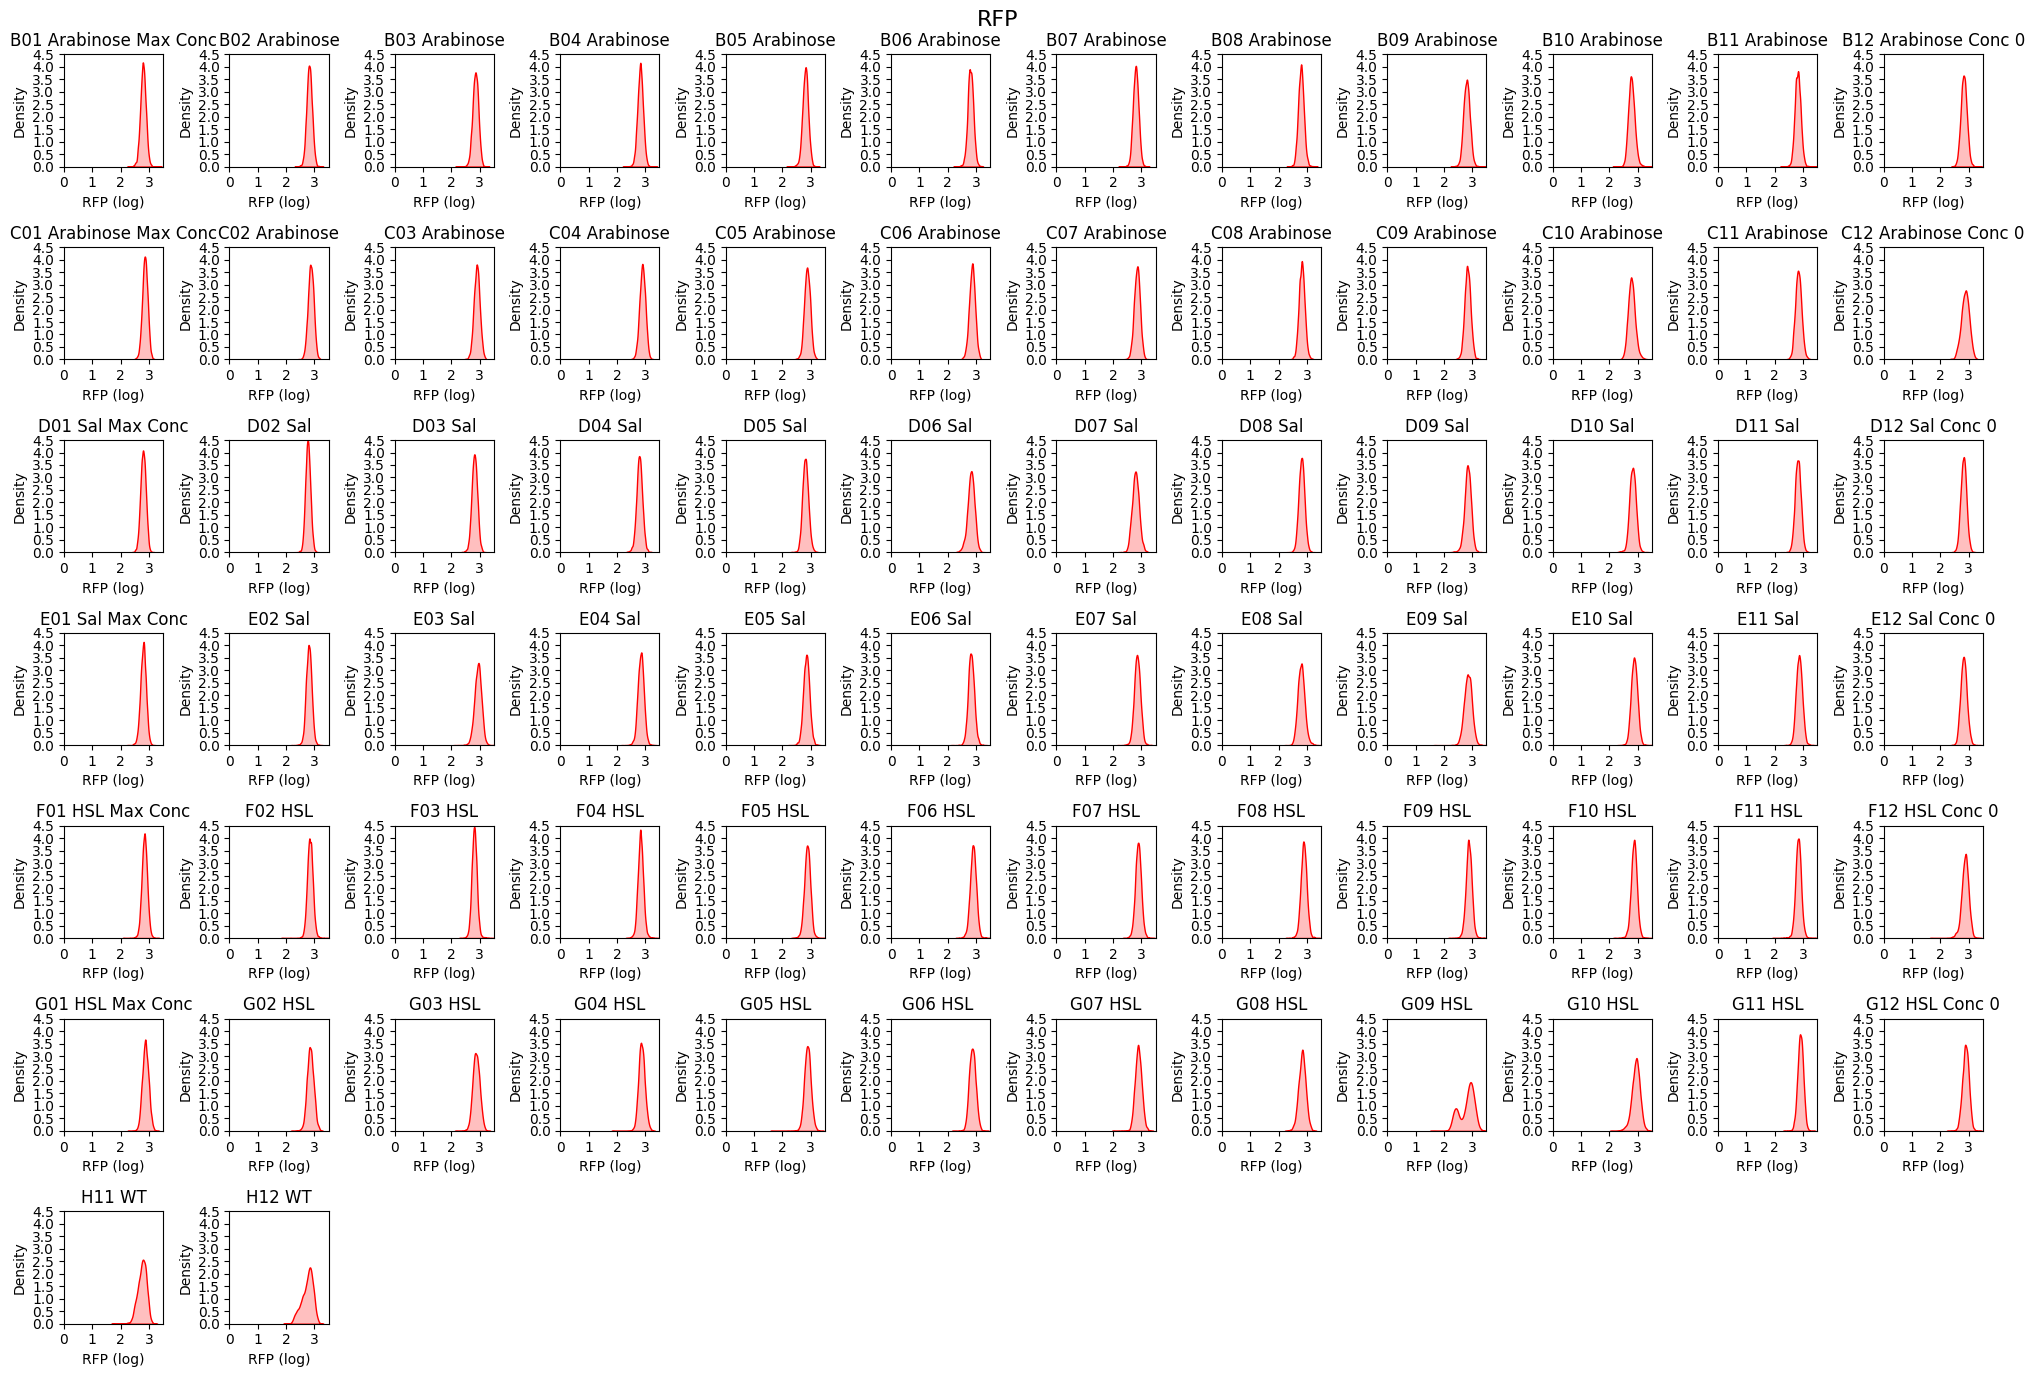

In [111]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from FlowCytometryTools import FCMeasurement

Channel1 = '405 - Height';
Channel2 = 'GFP - Height';
Channel3 = 'RFP-561 - Height';
WellIDtoSampleName = {
    'B01': 'Arabinose Max Conc', 'B02': 'Arabinose', 'B03': 'Arabinose', 'B04': 'Arabinose', 'B05': 'Arabinose',
    'B06': 'Arabinose', 'B07': 'Arabinose', 'B08': 'Arabinose', 'B09': 'Arabinose', 'B10': 'Arabinose', 
    'B11': 'Arabinose', 'B12': 'Arabinose Conc 0',
    'C01': 'Arabinose Max Conc', 'C02': 'Arabinose', 'C03': 'Arabinose', 'C04': 'Arabinose', 'C05': 'Arabinose',
    'C06': 'Arabinose', 'C07': 'Arabinose', 'C08': 'Arabinose', 'C09': 'Arabinose', 'C10': 'Arabinose',
    'C11': 'Arabinose', 'C12': 'Arabinose Conc 0',
    'D01': 'Sal Max Conc', 'D02': 'Sal', 'D03': 'Sal', 'D04': 'Sal', 'D05': 'Sal',
    'D06': 'Sal', 'D07': 'Sal', 'D08': 'Sal', 'D09': 'Sal', 'D10': 'Sal',
    'D11': 'Sal', 'D12': 'Sal Conc 0',
    'E01': 'Sal Max Conc', 'E02': 'Sal', 'E03': 'Sal', 'E04': 'Sal', 'E05': 'Sal',
    'E06': 'Sal', 'E07': 'Sal', 'E08': 'Sal', 'E09': 'Sal', 'E10': 'Sal',
    'E11': 'Sal', 'E12': 'Sal Conc 0',
    'F01': 'HSL Max Conc', 'F02': 'HSL', 'F03': 'HSL', 'F04': 'HSL', 'F05': 'HSL',
    'F06': 'HSL', 'F07': 'HSL', 'F08': 'HSL', 'F09': 'HSL', 'F10': 'HSL',
    'F11': 'HSL', 'F12': 'HSL Conc 0',
    'G01': 'HSL Max Conc', 'G02': 'HSL', 'G03': 'HSL', 'G04': 'HSL', 'G05': 'HSL',
    'G06': 'HSL ', 'G07': 'HSL', 'G08': 'HSL', 'G09': 'HSL', 'G10': 'HSL',
    'G11': 'HSL', 'G12': 'HSL Conc 0',
    'H11': 'WT', 'H12': 'WT'
};

def extract_data(fcs_file, channel_names):
    """Extracts Channel 1 data from the given FCS file."""
          
    FSCLower = 4.0 
    FSCUpper = 4.8
    SSCLower = 2.5
    SSCUpper = 4.5

    sample = FCMeasurement(ID=fcs_file, datafile=Dirpath + '/' + fcs_file)
    temp_df = pd.DataFrame(data=sample.data)
    log_channels = list(temp_df.columns)  # name of the column headers 

    # Filtering and logging
    temp_df = temp_df[log_channels]
    temp_df = temp_df[temp_df[log_channels] > -np.Inf]
    temp_df = temp_df[temp_df[log_channels] < np.Inf]
    temp_df = np.log10(temp_df)
    temp_df = temp_df.dropna(axis=0, how='any')

    size_df = temp_df[FSCUpper > temp_df['FSC - Height']]
    size_df = size_df[size_df['FSC - Height'] > FSCLower]
    size_df = size_df[SSCLower < size_df['SSC - Height']]
    size_df = size_df[size_df['SSC - Height'] < SSCUpper]


    # Assuming 'Channel1' is named appropriately in your dataset
    channel1_data = size_df[channel_names]  # Update this to match your channel name
    return channel1_data

def plot_all_channel(all_files, channel_names, x_axis, title):    

    """Plots Channel 1 data from all FCS files in subplots."""
    num_files = len(all_files)
    cols = 12  # Number of columns in the subplot
    rows = 7  # Calculate number of rows needed

    fig, axs = plt.subplots(rows, cols, figsize=(20, 14))
    fig.suptitle(title, fontsize=16)
    axs = axs.flatten()  # Flatten the 2D array of axes for easy iteration

    for idx, fcs_file in enumerate(all_files):
        if '.fcs' in fcs_file:
            channel1_data = extract_data(fcs_file, channel_names)
            
            sns.kdeplot(channel1_data, ax=axs[idx], color=x_axis[0].lower(), fill=x_axis[0].lower())  # KDE plot
            well_id, sample_name = list(WellIDtoSampleName.items())[idx]
            axs[idx].set_title(f'{well_id} {sample_name}')  # Title based on file name
            axs[idx].set_xlabel(x_axis)
            axs[idx].set_ylabel('Density')
            axs[idx].set_xlim(0, 3.5)
            axs[idx].set_ylim(0, 2.5)
            axs[idx].set_xticks(np.arange(0, 4, 1))  
            axs[idx].set_yticks(np.arange(0, 5, 0.5)) 


    # Hide empty subplots if any
    for idx in range(num_files, rows * cols):
        fig.delaxes(axs[idx])
    


    plt.tight_layout()
    plt.show()

# Example usage:
plot_all_channel(All_Files, Channel1, 'BFP (log)', title= 'BFP')
plot_all_channel(All_Files, Channel2, 'GFP (log)', title='GFP')
plot_all_channel(All_Files, Channel3, 'RFP (log)', title='RFP')



